In [1]:

import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *
from sqlalchemy import create_engine
from sqlalchemy import text
import pandas as pd
import numpy as np


In [2]:
server_sql = server_zeus
db_sql = "ODIN"
user_sql = user_zeus
pwd_sql = pwd_zeus

engine_zeus = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

config_servidores = {
    76: ["SAE","SAR","AGENDA"],
    7: ["EFECTIVA_NC"],
    64: [ "EFECTIVA_NEGOCIOS", "BCO ALFIN"],
    21: ["DINERS TC","plus","DINERS"],
    40:["IVR_TARGET","IVR_Target_Seguimiento_1","IVR_Target_Seguimiento_2"]
}
fecha_mes_base='2026-08-01'


In [3]:
def obtener_info_servidor(servidor,campanas,fecha_mes_base,engine_zeus):

    print("=" * 80)
    print(f"PROCESANDO SERVIDOR: 192.168.3.{servidor}")
    print("CAMPAÑAS:")

    for campana in campanas:
        print(f" - {campana}")

    print("=" * 80)


    # ========================================================
    # 1. FILTRO DE CAMPAÑAS
    # ========================================================

    condiciones = [
        f'e.campaign_name LIKE "%{campana}%"'
        for campana in campanas
    ]

    filtro_campanas = " OR ".join(condiciones)

    print("\nFiltro generado:")
    print(filtro_campanas)


    # ========================================================
    # 2. EXTRAER DIAL LOG
    # ========================================================

    query_dial = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '

        SELECT
            call_date,
            lead_id,
            server_ip,
            extension,
            channel,
            context,

            /* NUMERO QUE VE EL CLIENTE */
            outbound_cid,

            sip_hangup_cause,
            sip_hangup_reason,
            uniqueid,
            caller_code,

            CASE

                WHEN extension LIKE ''888%''
                  OR channel LIKE ''Local/888%''
                    THEN ''PERUCALL''

                WHEN extension LIKE ''899%''
                  OR channel LIKE ''Local/899%''
                    THEN ''INTELVOX''

                ELSE ''OTRO''

            END AS proveedor

        FROM asterisk.vicidial_dial_log

        WHERE

            call_date >= DATE_FORMAT(
                ''{fecha_mes_base}'',
                ''%Y-%m-01''
            )

        AND call_date <

            DATE_ADD(

                DATE_FORMAT(
                    ''{fecha_mes_base}'',
                    ''%Y-%m-01''
                ),

                INTERVAL 1 MONTH
            )

    ')
    """

    df_dial = pd.read_sql(
        query_dial,
        engine_zeus
    )

    print("\nDial Log:", len(df_dial))


    # ========================================================
    # 3. EXTRAER VICIDIAL LOG
    # ========================================================

    query_vic = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '

        SELECT

            a.lead_id,

            a.uniqueid,

            RTRIM(
                LTRIM(
                    d.vendor_lead_code
                )
            ) AS vendor_lead_code,


            /* ===============================================
               CONFIGURACION ACTUAL

               SOLO SE USA COMO REFERENCIA.
               NO usar para análisis histórico.
               =============================================== */

            e.dial_method
                AS dial_method_actual,

            e.auto_dial_level
                AS auto_dial_level_actual,

            e.hopper_level
                AS hopper_level_actual,


            /* =============================================== */

            a.campaign_id
                AS numero_campana,

            a.user
                AS dni_ejecutivo,

            c.full_name
                AS ejecutivo,

            e.campaign_name
                AS nombre_campana,

            a.call_date
                AS fecha_hora_llamada,

            a.length_in_sec
                AS duracion,

            b.status_name
                AS call_result,

            f.list_description,

            f.list_name,

            a.phone_number
                AS phone_number,

            d.alt_phone
                AS fecha_agenda,

            d.comments
                AS comentarios,

            a.status
                AS codigo


        FROM asterisk.vicidial_log a


        LEFT JOIN asterisk.vicidial_list d
            ON a.lead_id = d.lead_id


        LEFT JOIN asterisk.vicidial_campaigns e
            ON a.campaign_id = e.campaign_id


        LEFT JOIN asterisk.vicidial_lists f
            ON a.list_id = f.list_id


        LEFT JOIN asterisk.vicidial_statuses b
            ON a.status = b.status


        LEFT JOIN asterisk.vicidial_users c
            ON a.user = c.user


        WHERE
            (
                {filtro_campanas}
            )


        AND a.call_date >= DATE_FORMAT(
            ''{fecha_mes_base}'',
            ''%Y-%m-01''
        )


        AND a.call_date <

            DATE_ADD(

                DATE_FORMAT(
                    ''{fecha_mes_base}'',
                    ''%Y-%m-01''
                ),

                INTERVAL 1 MONTH
            )

    ')
    """

    df_vic = pd.read_sql(
        query_vic,
        engine_zeus
    )

    print(
        "Vicidial Log:",
        len(df_vic)
    )


    # ========================================================
    # 4. EXTRAER AGENT LOG
    # ========================================================

    query_agent = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '

        SELECT

            agent_log_id,

            user,

            server_ip,

            event_time,

            lead_id,

            campaign_id,

            pause_sec,

            wait_sec,

            talk_sec,

            dispo_sec,

            dead_sec,

            status,

            uniqueid,

            pause_type


        FROM asterisk.vicidial_agent_log


        WHERE

            event_time >= DATE_FORMAT(
                ''{fecha_mes_base}'',
                ''%Y-%m-01''
            )


        AND event_time <

            DATE_ADD(

                DATE_FORMAT(
                    ''{fecha_mes_base}'',
                    ''%Y-%m-01''
                ),

                INTERVAL 1 MONTH
            )

    ')
    """

    df_agent = pd.read_sql(
        query_agent,
        engine_zeus
    )

    print(
        "Agent Log:",
        len(df_agent)
    )


    # ========================================================
    # 5. PREPARAR VICIDIAL LOG
    # ========================================================

    df_vic["fecha_hora_llamada"] = pd.to_datetime(
        df_vic["fecha_hora_llamada"],
        errors="coerce"
    )


    df_vic["lead_id"] = pd.to_numeric(
        df_vic["lead_id"],
        errors="coerce"
    )


    df_vic["duracion"] = pd.to_numeric(
        df_vic["duracion"],
        errors="coerce"
    )


    df_vic = (

        df_vic

        .dropna(
            subset=[
                "lead_id",
                "fecha_hora_llamada",
                "numero_campana"
            ]
        )

        .copy()
    )


    df_vic["lead_id"] = (
        df_vic["lead_id"]
        .astype("int64")
    )


    # ========================================================
    # CLAVE DE CAMPAÑA
    # ========================================================

    df_vic["numero_campana"] = (

        df_vic["numero_campana"]

        .astype(str)

        .str.strip()
    )


    # ========================================================
    # 6. OBTENER CAMPAÑAS
    # ========================================================

    campanas_ids = (

        df_vic["numero_campana"]

        .dropna()

        .unique()

        .tolist()
    )


    print("\nIDs campañas encontrados:")
    print(campanas_ids)


    # ========================================================
    # 7. EXTRAER ADMIN LOG
    # ========================================================

    if len(campanas_ids) > 0:

        ids_sql = ",".join(

            [
                f"''{x}''"
                for x in campanas_ids
            ]

        )


        query_admin = f"""
        SELECT *
        FROM OPENQUERY([192.168.3.{servidor}], '

            SELECT

                admin_log_id,

                event_date,

                user,

                event_section,

                event_type,

                record_id,

                event_code,

                event_sql,

                event_notes


            FROM asterisk.vicidial_admin_log


            WHERE

                event_section = ''CAMPAIGNS''


            AND record_id IN (
                {ids_sql}
            )


            AND
            (

                   event_sql LIKE ''%dial_method=%''

                OR event_sql LIKE ''%auto_dial_level=%''

                OR event_sql LIKE ''%hopper_level=%''

            )


            /* =================================================
               Necesitamos todo cambio anterior al fin del mes.

               Esto permite conocer el estado que estaba vigente
               incluso si fue configurado antes del día 1.
               ================================================= */

            AND event_date <

                DATE_ADD(

                    DATE_FORMAT(
                        ''{fecha_mes_base}'',
                        ''%Y-%m-01''
                    ),

                    INTERVAL 1 MONTH
                )


            ORDER BY

                event_date,

                admin_log_id

        ')
        """


        df_admin = pd.read_sql(
            query_admin,
            engine_zeus
        )


    else:

        df_admin = pd.DataFrame()


    print(
        "Admin Log configuraciones:",
        len(df_admin)
    )


    # ========================================================
    # 8. PREPARAR ADMIN LOG
    # ========================================================

    if not df_admin.empty:


        # ----------------------------------------------------
        # FECHA
        # ----------------------------------------------------

        df_admin["event_date"] = pd.to_datetime(
            df_admin["event_date"],
            errors="coerce"
        )


        # ----------------------------------------------------
        # record_id = campaign_id
        # ----------------------------------------------------

        df_admin["numero_campana"] = (

            df_admin["record_id"]

            .astype(str)

            .str.strip()
        )


        # ====================================================
        # DIAL METHOD HISTORICO
        # ====================================================

        df_admin["dial_method_historico"] = (

            df_admin["event_sql"]

            .astype(str)

            .str.extract(
                r"dial_method='([^']+)'",
                expand=False
            )
        )


        # ====================================================
        # AUTO DIAL LEVEL HISTORICO
        # ====================================================

        df_admin["auto_dial_level_historico"] = (

            df_admin["event_sql"]

            .astype(str)

            .str.extract(
                r"auto_dial_level='([^']+)'",
                expand=False
            )
        )


        # ====================================================
        # HOPPER LEVEL HISTORICO
        # ====================================================

        df_admin["hopper_level_historico"] = (

            df_admin["event_sql"]

            .astype(str)

            .str.extract(
                r"hopper_level='([^']+)'",
                expand=False
            )
        )


        # ====================================================
        # NORMALIZAR
        # ====================================================

        df_admin["dial_method_historico"] = (

            df_admin["dial_method_historico"]

            .str.strip()

            .str.upper()
        )


        df_admin["auto_dial_level_historico"] = pd.to_numeric(

            df_admin["auto_dial_level_historico"],

            errors="coerce"
        )


        df_admin["hopper_level_historico"] = pd.to_numeric(

            df_admin["hopper_level_historico"],

            errors="coerce"
        )


        # ====================================================
        # ORDEN CRONOLOGICO
        # ====================================================

        df_admin = (

            df_admin

            .dropna(
                subset=[
                    "event_date",
                    "numero_campana"
                ]
            )

            .sort_values(
                [
                    "numero_campana",
                    "event_date",
                    "admin_log_id"
                ]
            )

            .reset_index(
                drop=True
            )
        )


        # ====================================================
        # COMPLETAR CONFIGURACION HISTORICA
        #
        # Si una modificación cambia hopper pero no cambia
        # dial_method, conservamos el último dial_method.
        # ====================================================

        columnas_estado = [

            "dial_method_historico",

            "auto_dial_level_historico",

            "hopper_level_historico"
        ]


        df_admin[columnas_estado] = (

            df_admin

            .groupby(
                "numero_campana"
            )[columnas_estado]

            .ffill()
        )


        # ====================================================
        # UN CAMBIO POR SEGUNDO
        # ====================================================

        df_admin = (

            df_admin

            .sort_values(
                [
                    "numero_campana",
                    "event_date",
                    "admin_log_id"
                ]
            )

            .drop_duplicates(
                subset=[
                    "numero_campana",
                    "event_date"
                ],
                keep="last"
            )

            .copy()
        )


        print("\nConfiguración histórica:")


        print(

            df_admin[
                [
                    "event_date",
                    "numero_campana",
                    "dial_method_historico",
                    "auto_dial_level_historico",
                    "hopper_level_historico"
                ]
            ]

            .tail(30)
        )


    # ========================================================
    # 9. ASIGNAR CONFIGURACION HISTORICA A CADA LLAMADA
    # ========================================================

    if not df_admin.empty:


        izquierda = (

            df_vic

            .sort_values(
                [
                    "fecha_hora_llamada",
                    "numero_campana"
                ]
            )

            .reset_index(drop=True)
        )


        derecha = (

            df_admin[
                [
                    "numero_campana",
                    "event_date",
                    "admin_log_id",
                    "dial_method_historico",
                    "auto_dial_level_historico",
                    "hopper_level_historico"
                ]
            ]

            .sort_values(
                [
                    "event_date",
                    "numero_campana"
                ]
            )

            .reset_index(drop=True)
        )


        df_vic = pd.merge_asof(

            izquierda,

            derecha,

            left_on="fecha_hora_llamada",

            right_on="event_date",

            by="numero_campana",

            direction="backward",

            allow_exact_matches=True
        )


    else:


        df_vic["event_date"] = pd.NaT

        df_vic["admin_log_id"] = pd.NA

        df_vic["dial_method_historico"] = pd.NA

        df_vic["auto_dial_level_historico"] = pd.NA

        df_vic["hopper_level_historico"] = pd.NA


    # ========================================================
    # 10. RENOMBRAR CONFIGURACION
    # ========================================================

    df_vic = df_vic.rename(

        columns={

            "event_date":
                "fecha_configuracion_historica",

            "admin_log_id":
                "admin_log_id_configuracion"
        }
    )


    # ========================================================
    # 11. VALIDAR HISTORICO
    # ========================================================

    print("\n" + "=" * 80)
    print("CONFIGURACIÓN HISTÓRICA")
    print("=" * 80)


    print("\nDIAL METHOD:")

    print(

        df_vic["dial_method_historico"]

        .value_counts(
            dropna=False
        )
    )


    print("\nAUTO DIAL LEVEL:")

    print(

        df_vic["auto_dial_level_historico"]

        .value_counts(
            dropna=False
        )

        .sort_index()
    )


    print("\nHOPPER LEVEL:")

    print(

        df_vic["hopper_level_historico"]

        .value_counts(
            dropna=False
        )

        .sort_index()
    )


    # ========================================================
    # 12. PREPARAR DIAL LOG
    # ========================================================

    df_dial["call_date"] = pd.to_datetime(

        df_dial["call_date"],

        errors="coerce"
    )


    df_dial["lead_id"] = pd.to_numeric(

        df_dial["lead_id"],

        errors="coerce"
    )


    df_dial = (

        df_dial

        .dropna(
            subset=[
                "lead_id",
                "call_date"
            ]
        )

        .copy()
    )


    df_dial["lead_id"] = (

        df_dial["lead_id"]

        .astype("int64")
    )


    # ========================================================
    # NORMALIZAR OUTBOUND CID
    # ========================================================

    df_dial["outbound_cid"] = (

        df_dial["outbound_cid"]

        .astype("string")

        .str.strip()
    )


    # Crear otra columna sin caracteres especiales
    # para posteriores análisis por número.

    df_dial["outbound_cid_limpio"] = (

        df_dial["outbound_cid"]

        .str.replace(
            r"\D",
            "",
            regex=True
        )
    )


    df_dial = (

        df_dial

        .sort_values(
            [
                "call_date",
                "lead_id"
            ]
        )

        .reset_index(drop=True)
    )


    # ========================================================
    # 13. PREPARAR AGENT LOG
    # ========================================================

    df_agent["event_time"] = pd.to_datetime(

        df_agent["event_time"],

        errors="coerce"
    )


    df_agent["lead_id"] = pd.to_numeric(

        df_agent["lead_id"],

        errors="coerce"
    )


    df_agent = (

        df_agent

        .dropna(
            subset=[
                "lead_id",
                "event_time"
            ]
        )

        .copy()
    )


    df_agent["lead_id"] = (

        df_agent["lead_id"]

        .astype("int64")
    )


    columnas_duracion_agent = [

        "pause_sec",

        "wait_sec",

        "talk_sec",

        "dispo_sec",

        "dead_sec"
    ]


    for columna in columnas_duracion_agent:

        df_agent[columna] = pd.to_numeric(

            df_agent[columna],

            errors="coerce"
        )


    # ========================================================
    # 14. NORMALIZAR UNIQUEID
    # ========================================================

    df_vic["uniqueid_match"] = (

        df_vic["uniqueid"]

        .astype(str)

        .str.strip()

        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


    df_agent["uniqueid_match"] = (

        df_agent["uniqueid"]

        .astype(str)

        .str.strip()

        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


    # ========================================================
    # 15. DUPLICADOS AGENT LOG
    # ========================================================

    duplicados_agent = (

        df_agent

        .duplicated(

            subset=[
                "lead_id",
                "uniqueid_match"
            ],

            keep=False
        )

        .sum()
    )


    print(
        "\nDuplicados Agent Log:",
        duplicados_agent
    )


    # ========================================================
    # 16. UN AGENT LOG POR LLAMADA
    # ========================================================

    df_agent_match = (

        df_agent

        .sort_values(
            "event_time"
        )

        .drop_duplicates(

            subset=[
                "lead_id",
                "uniqueid_match"
            ],

            keep="last"
        )

        .copy()
    )


    # ========================================================
    # 17. PREPARAR VICIDIAL
    # ========================================================

    df_vic = (

        df_vic

        .sort_values(
            [
                "fecha_hora_llamada",
                "lead_id"
            ]
        )

        .reset_index(
            drop=True
        )
    )


    # ========================================================
    # 18. VICIDIAL LOG VS DIAL LOG
    #
    # AQUÍ SE AGREGA OUTBOUND_CID
    # ========================================================

    df_final = pd.merge_asof(

        df_vic,

        df_dial[
            [
                "lead_id",

                "call_date",

                "proveedor",

                # =============================================
                # CALLER ID / NUMERO SALIENTE
                # =============================================
                "outbound_cid",

                "outbound_cid_limpio",

                # =============================================

                "sip_hangup_cause",

                "sip_hangup_reason",

                "extension",

                "channel",

                "context",

                "server_ip",

                "caller_code"
            ]
        ],

        left_on=
            "fecha_hora_llamada",

        right_on=
            "call_date",

        by=
            "lead_id",

        direction=
            "backward",

        tolerance=pd.Timedelta(
            seconds=90
        )
    )


    # ========================================================
    # 19. DIFERENCIA DIAL LOG
    # ========================================================

    df_final["diferencia_segundos"] = (

        df_final["fecha_hora_llamada"]

        - df_final["call_date"]

    ).dt.total_seconds()


    # ========================================================
    # 20. CRUZAR CON AGENT LOG
    # ========================================================

    df_final = df_final.merge(

        df_agent_match[
            [
                "lead_id",

                "uniqueid_match",

                "event_time",

                "wait_sec",

                "talk_sec",

                "dispo_sec",

                "dead_sec",

                "pause_sec",

                "status",

                "campaign_id",

                "pause_type"
            ]
        ],

        on=[
            "lead_id",
            "uniqueid_match"
        ],

        how=
            "left",

        suffixes=(
            "",
            "_agent"
        )
    )


    # ========================================================
    # 21. RENOMBRAR AGENT
    # ========================================================

    df_final = df_final.rename(

        columns={

            "event_time":
                "event_time_agent",

            "status":
                "status_agent",

            "campaign_id":
                "campaign_id_agent"
        }
    )


    # ========================================================
    # 22. DIFERENCIA AGENT
    # ========================================================

    df_final["diferencia_seg_agent"] = (

        df_final["event_time_agent"]

        - df_final["fecha_hora_llamada"]

    ).dt.total_seconds()


    # ========================================================
    # 23. SERVIDOR
    # ========================================================

    df_final["servidor"] = (
        f"192.168.3.{servidor}"
    )


    # ========================================================
    # 24. VALIDACIONES
    # ========================================================

    total = len(df_final)


    print("\n" + "-" * 80)

    print(
        f"TOTAL SERVIDOR {servidor}:",
        total
    )


    # ========================================================
    # PROVEEDOR
    # ========================================================

    con_proveedor = (

        df_final["proveedor"]

        .notna()

        .sum()
    )


    print(
        "\nCon proveedor:",
        con_proveedor
    )


    print(
        "% Match proveedor:",

        round(
            con_proveedor / total * 100,
            2
        )

        if total > 0

        else 0
    )


    # ========================================================
    # OUTBOUND CID
    # ========================================================

    con_outbound_cid = (

        df_final["outbound_cid_limpio"]

        .notna()

        .sum()
    )


    print(
        "\nCon Outbound CID:",
        con_outbound_cid
    )


    print(
        "% con Outbound CID:",

        round(
            con_outbound_cid / total * 100,
            2
        )

        if total > 0

        else 0
    )


    print(
        "\nCantidad de Caller ID distintos:"
    )


    print(

        df_final

        .groupby(
            "proveedor",
            dropna=False
        )["outbound_cid_limpio"]

        .nunique()
    )


    # ========================================================
    # AGENT LOG
    # ========================================================

    con_agent = (

        df_final["event_time_agent"]

        .notna()

        .sum()
    )


    print(
        "\nCon Agent Log:",
        con_agent
    )


    print(
        "% Match Agent:",

        round(
            con_agent / total * 100,
            2
        )

        if total > 0

        else 0
    )


    # ========================================================
    # DIAL METHOD HISTORICO
    # ========================================================

    con_historico = (

        df_final["dial_method_historico"]

        .notna()

        .sum()
    )


    print(
        "\nCon Dial Method histórico:",
        con_historico
    )


    print(
        "% identificado:",

        round(
            con_historico / total * 100,
            2
        )

        if total > 0

        else 0
    )


    print(
        "\nDistribución Dial Method:"
    )


    print(

        df_final["dial_method_historico"]

        .value_counts(
            dropna=False
        )
    )


    print("-" * 80)


    # ========================================================
    # 25. RETORNAR
    # ========================================================

    return df_final

In [4]:
lista_servidores = []

for servidor, campanas in config_servidores.items():

    try:

        df_temp = obtener_info_servidor(
            servidor=servidor,
            campanas=campanas,
            fecha_mes_base=fecha_mes_base,
            engine_zeus=engine_zeus
        )

        lista_servidores.append(df_temp)

    except Exception as e:

        print("\n" + "!" * 80)
        print(f"ERROR EN SERVIDOR {servidor}")
        print(e)
        print("!" * 80)

PROCESANDO SERVIDOR: 192.168.3.76
CAMPAÑAS:
 - SAE
 - SAR
 - AGENDA

Filtro generado:
e.campaign_name LIKE "%SAE%" OR e.campaign_name LIKE "%SAR%" OR e.campaign_name LIKE "%AGENDA%"

Dial Log: 397752
Vicidial Log: 396692
Agent Log: 63276

IDs campañas encontrados:
['16', '55', '56']
Admin Log configuraciones: 142

Configuración histórica:
             event_date numero_campana dial_method_historico  \
112 2026-08-18 09:18:44             55                 RATIO   
113 2026-08-18 09:19:12             55                 RATIO   
114 2026-08-18 11:47:59             55                 RATIO   
115 2026-08-18 12:01:48             55                 RATIO   
116 2026-08-18 12:12:03             55         ADAPT_TAPERED   
117 2026-08-18 12:12:15             55                 RATIO   
118 2026-08-18 12:12:22             55                 RATIO   
119 2026-08-18 12:14:00             55                 RATIO   
120 2026-08-18 13:03:50             55         ADAPT_TAPERED   
121 2026-08-18 13:0

In [5]:
df_total_mes = pd.concat(
    lista_servidores,
    ignore_index=True
)
print( "TOTAL GENERAL:", len(df_total_mes))
print()
print( df_total_mes["servidor"].value_counts())
print()
print(df_total_mes["proveedor"].value_counts(dropna=False))

TOTAL GENERAL: 1377949

servidor
192.168.3.64    604126
192.168.3.76    396692
192.168.3.21    336972
192.168.3.40     23337
192.168.3.7      16822
Name: count, dtype: int64

proveedor
INTELVOX    1084520
PERUCALL     292505
OTRO            696
NaN             228
Name: count, dtype: int64


In [6]:
df_total_mes["codigo"] = (
    df_total_mes["codigo"]
    .astype(str)
    .str.strip()
)

mask = df_total_mes["codigo"].str.fullmatch(r"\d+")

df_total_mes.loc[mask, "codigo"] = (
    "AL" + df_total_mes.loc[mask, "codigo"]
)
# 1. CHS005 → CHS002
df_total_mes["codigo"] = (
    df_total_mes["codigo"]
    .replace("CHS005", "CHS002")
)

# 2. Reemplazar CHS00 por AL
df_total_mes["codigo"] = (
    df_total_mes["codigo"]
    .str.replace(
        r"^CHS00",
        "AL",
        regex=True
    )
)
df_total_mes["codigo"] = (
    df_total_mes["codigo"]
    .str.replace(
        r"^CHS0",
        "AL",
        regex=True
    )
)
df_total_mes["proveedor"] = (
    df_total_mes["proveedor"]
    .fillna("PROVEEDOR NO IDENTIFICADO")
)


In [ ]:
# ============================================================
# COLUMNAS CATEGÓRICAS
# ============================================================

columnas_limpiar = [
    "dial_method_historico",
    "proveedor",
    "codigo"
]

for col in columnas_limpiar:
    df_total_mes[col] = (
        df_total_mes[col]
        .astype("string")
        .str.strip()
        .str.upper()
    )


# ============================================================
# NOMBRE CAMPAÑA
# ============================================================

df_total_mes["nombre_campana"] = (
    df_total_mes["nombre_campana"]
    .astype("string")
    .str.strip()
)

query_vic = f"""
    SELECT DISTINCT estado,descripcion,codigo
    FROM (
        select [NIVEL 2] as estado,[NIVEL 4] as descripcion,cod as codigo 
        from ODIN.dbo.tTipologia_Diners_TC
        where cod like 'E0%'

        UNION

        select [NIVEL 2] as estado,[NIVEL 4] as descripcion,cod as codigo  
        from ODIN.dbo.tTipologia_Diners_PPD
        where cod like 'C0%'
            UNION

        select tipo as estado,descripcion,codigo  
        from ODIN.dbo.tTipologia_Efectiva
        where codigo like 'B0%'

        UNION

        select tipo as estado,descripcion,codigo  
        from ODIN.dbo.tTipologia_Cencosud_PPFF
        where codigo like 'R0%'

        UNION

        select distinct case 
        when estado='CONTACTO EFECTIVO CON TITULAR' then 'CONTACTO EFECTIVO'
        when estado='CONTACTO CON TERCERO NO RELACIONADO' then 'CONTACTO NO EFECTIVO'
        when estado='CONTACTO CON TERCERO' then 'CONTACTO NO EFECTIVO'
        when estado='DISCADOR' then 'MAQUINA'
        when estado='DISCADOR (AUTO)' then 'MAQUINA'
        when estado='NO CONTACTO' then 'NO CONTACTO'
        end as estado,descripcion,codigo
        from [192.168.2.50].[ODIN].[dbo].[tTipologia_Alfin]
        where estado is not null
    ) t
    """
df_tipi = pd.read_sql(query_vic,engine_zeus)
df_tipi=df_tipi.drop_duplicates('codigo')

columnas_limpiar = ["estado","codigo",]

for col in columnas_limpiar:
    df_tipi[col] = (
        df_tipi[col]
        .astype(str)
        .str.strip()
    )

df_total_mes_01=df_total_mes.merge(df_tipi,on='codigo',how='left')

df_total_mes_01["estado"] = (
    df_total_mes_01["estado"]
    .replace("CONTACTO TERCERO", "CONTACTO NO EFECTIVO")
)

columnas_limpiar = [
    "dial_method_historico",
    "proveedor",
    "estado",
    "codigo",
    "nombre_campana"
]

for col in columnas_limpiar:
    df_total_mes_01[col] = (
        df_total_mes_01[col]
        .astype(str)
        .str.strip()
    )

import numpy as np

contestadora = ["AA","AL","AM",'PM']
no_contesta_red = ["AB","NA","ADC"]
sistema_operacion = ["DROP","PDROP","DCMX"]
contato_1=['CALLBK','XFER','CBHOLD','PU']
sin_cierre=['INCALL']

df_total_mes_01["estado"] = np.select(
    [
        df_total_mes_01["codigo"].isin(contestadora),
        df_total_mes_01["codigo"].isin(no_contesta_red),
        df_total_mes_01["codigo"].isin(sistema_operacion),
        df_total_mes_01["codigo"].isin(contato_1),
        df_total_mes_01["codigo"].isin(sin_cierre)
    ],
    [
        "BUZON DE VOZ",
        "NO CONTESTA / RED",
        "SISTEMA / OPERACION",
        "CONTACTO / TRANSFERENCIA",
        "SIN CIERRE / INCALL"
    ],
    default=df_total_mes_01["estado"]
)


contacto = [
    "CONTACTO EFECTIVO",
    "CONTACTO NO EFECTIVO",
    "CONTACTO / TRANSFERENCIA"
]

no_contacto = [
    "NO CONTACTO",
    "NO CONTESTA / RED",
    "BUZON DE VOZ",
    "MAQUINA",
    "SISTEMA / OPERACION",
]
sin_cierre = [
    "SIN CIERRE / INCALL"
]

df_total_mes_01["tipo_contacto"] = np.select(
    [
        df_total_mes_01["estado"].isin(contacto),
        df_total_mes_01["estado"].isin(no_contacto),
        df_total_mes_01["estado"].isin(sin_cierre)
    ],
    [
        "CONTACTO",
        "NO CONTACTO",
        "NO CONTACTO",
    ],
    default="REVISAR"
)
df_codigos = (
    df_total_mes_01.loc[
        df_total_mes_01["server_ip"] == "192.168.3.40",
        ["codigo"]
    ]
    .drop_duplicates()
)

# print(df_codigos["codigo"].unique().tolist())


proveedores = ["PERUCALL","INTELVOX"]

campanas = [
        "AGENDA",
        "2026-08 SAE",
        "2026-08 SAR",
        "BOT_EFECTIVA_NC",
        "2026-08 BCO ALFIN",
        "2026-08 EFECTIVA_NEGOCIOS",
        "2026-08 EFECTIVA_NEGOCIOS SEG",
        "2026-08 DINERS TC",
        "IVR_TARGET",
        "IVR_Target_Seguimiento_1",
        "IVR_Target_Seguimiento_2",
        "2026-08 DINERS",
        "2026-08 DINERS PLUS"
    ]

df_total_mes_02 = df_total_mes_01[
    df_total_mes_01["proveedor"].isin(proveedores)&
    df_total_mes_01["nombre_campana"].isin(campanas)
].copy()
df_total_mes_02["sip_hangup_cause"] = pd.to_numeric(
    df_total_mes_02["sip_hangup_cause"],
    errors="coerce"
)


In [ ]:
df_total_mes_02["duracion"] = pd.to_numeric(
    df_total_mes_02["duracion"],
    errors="coerce"
)

condiciones = [

    (
        (df_total_mes_02["tipo_contacto"] == "CONTACTO")
        &
        (df_total_mes_02["duracion"] >= 15)
    ),

    (
        (df_total_mes_02["tipo_contacto"] == "CONTACTO")
        &
        (df_total_mes_02["duracion"] < 15)
    ),

    (
        df_total_mes_02["tipo_contacto"] == "CONTACTO"
    ),

    (
        df_total_mes_02["tipo_contacto"] == "NO CONTACTO"
    )
]


valores = [
    "CONTACTO_15S",
    "CONTACTO_MENOR_15S",
    "NO CONTACTO"
]


df_total_mes_02["tipo_contacto_15s"] = np.select(
    condiciones,
    valores,
    default=df_total_mes_02["tipo_contacto"]
)

In [22]:
df_total_mes_02.loc[
    df_total_mes_02["tipo_contacto_15s"] == "CONTACTO",
    "codigo"
].unique()

array(['INCALL'], dtype=object)

In [23]:
df_total_mes_02[df_total_mes_02["tipo_contacto_15s"]=='CONTACTO'].head(3)

,lead_id,uniqueid,vendor_lead_code,dial_method_actual,auto_dial_level_actual,hopper_level_actual,numero_campana,dni_ejecutivo,ejecutivo,nombre_campana,fecha_hora_llamada,duracion,call_result,list_description,list_name,phone_number,fecha_agenda,comentarios,codigo,fecha_configuracion_historica,admin_log_id_configuracion,dial_method_historico,auto_dial_level_historico,hopper_level_historico,uniqueid_match,call_date,proveedor,outbound_cid,outbound_cid_limpio,sip_hangup_cause,sip_hangup_reason,extension,channel,context,server_ip,caller_code,diferencia_segundos,event_time_agent,wait_sec,talk_sec,dispo_sec,dead_sec,pause_sec,status_agent,campaign_id_agent,pause_type,diferencia_seg_agent,servidor,estado,descripcion,tipo_contacto,tipo_contacto_15s
39608,6965579,1785794573.1491688,41615462,RATIO,7,1000.0,55,PFC112,KEVIN ALEXANDER NAVARRO CASTILLO,2026-08 SAE,2026-08-03 17:03:27,NaN,Lead Being Called,MONTOSCHICOS,MONTOSCHICOS,978401390,None,CONSENTIMIENTO: Y FLG_PAGO_DIFERIDO:Sin Pago Diferido ELECCION AE: LINEA DISP AE: 0PCT_ant: 0 TEA_ant: 0.0,INCALL,2026-08-03 14:51:34,21771.0,RATIO,7.0,1000,1785794573.1491688,2026-08-03 17:02:53,INTELVOX,"""M8031702530006965579"" <0000000000>",80317025300069655790000000000,200.0,OK),899978401390,Local/8600058@default,default,192.168.3.76,M8031702530006965579,34.0,2026-08-03 17:02:34,34.0,0.0,5.0,0.0,19.0,R018,55,AGENT,-53.0,192.168.3.76,CONTACTO / TRANSFERENCIA,REGISTRO NO GESTIONADO AL CORTE,CONTACTO,CONTACTO
40015,6959209,1785795022.1493033,08829141,RATIO,7,1000.0,55,PFC112,KEVIN ALEXANDER NAVARRO CASTILLO,2026-08 SAE,2026-08-03 17:11:07,NaN,Lead Being Called,altomedionce5a15k,altomedionce5a15k,956020857,None,CONSENTIMIENTO: N FLG_PAGO_DIFERIDO: ELECCION AE: LINEA DISP AE: 0PCT_ant: 0 TEA_ant: 0.0,INCALL,2026-08-03 17:10:44,21780.0,RATIO,7.0,1000,1785795022.1493033,2026-08-03 17:10:31,INTELVOX,"""V8031710310006959209"" <0000000000>",80317103100069592090000000000,200.0,OK),138369,Local/899956020857@default,default,192.168.3.76,V8031710310006959209,36.0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,192.168.3.76,CONTACTO / TRANSFERENCIA,REGISTRO NO GESTIONADO AL CORTE,CONTACTO,CONTACTO
44001,6969090,1785853896.1506653,05402089,RATIO,7,1000.0,55,PFC120,GIOVANNA CORTEZ MARAVI,2026-08 SAE,2026-08-04 09:32:16,NaN,Lead Being Called,ALTOMEDIOMAYORA15K,ALTOMEDIOMAYORA15K,997958749,None,CONSENTIMIENTO: N FLG_PAGO_DIFERIDO:Sin Pago Diferido ELECCION AE: LINEA DISP AE: 0PCT_ant: 0 TEA_ant: 0.0,INCALL,2026-08-04 09:18:51,21789.0,RATIO,7.0,1000,1785853896.1506653,2026-08-04 09:31:36,INTELVOX,"""M8040931360006969090"" <0000000000>",80409313600069690900000000000,200.0,OK),899997958749,Local/8600062@default,default,192.168.3.76,M8040931360006969090,40.0,2026-08-04 09:31:35,40.0,0.0,4.0,0.0,1.0,R018,55,AGENT,-41.0,192.168.3.76,CONTACTO / TRANSFERENCIA,REGISTRO NO GESTIONADO AL CORTE,CONTACTO,CONTACTO


In [ ]:
array(['NO CONTACTO', 'CONTACTO_15S', 'CONTACTO_MENOR_15S', 'CONTACTO'],


In [ ]:
df_total_mes_02=df_total_mes_02[df_total_mes_02["fecha_hora_llamada"]<'2026-08-18'] 

In [9]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Llamadas

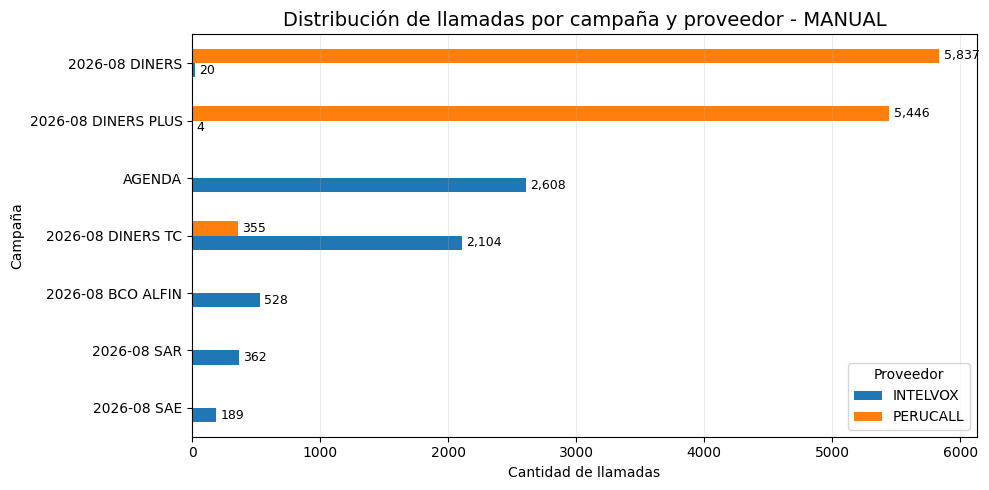

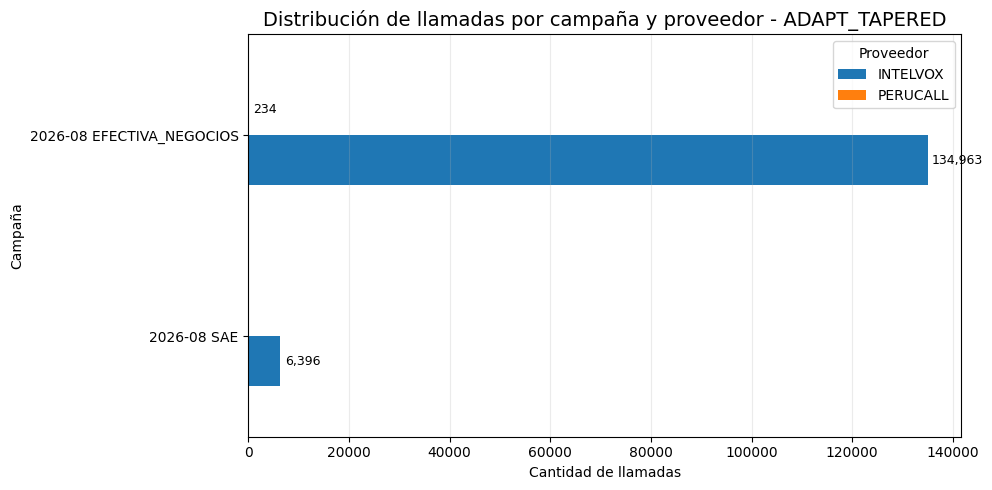

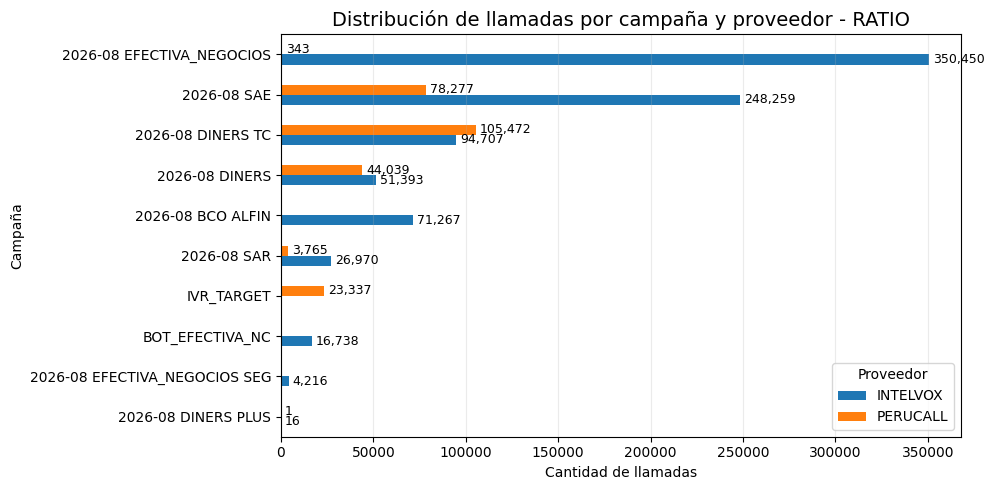

In [10]:
import matplotlib.pyplot as plt

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]

for metodo in orden_dial:

    df_metodo = df_total_mes_02[
        df_total_mes_02["dial_method_historico"] == metodo
    ].copy()

    if df_metodo.empty:
        continue

    # --------------------------------------------------------
    # VOLUMEN POR CAMPAÑA Y PROVEEDOR
    # --------------------------------------------------------

    df_grafico_campana = (
        df_metodo
        .groupby(
            [
                "nombre_campana",
                "proveedor"
            ]
        )
        .size()
        .unstack(
            fill_value=0
        )
    )

    # --------------------------------------------------------
    # ORDENAR POR VOLUMEN TOTAL
    # --------------------------------------------------------

    df_grafico_campana["TOTAL"] = (
        df_grafico_campana.sum(axis=1)
    )

    df_grafico_campana = (
        df_grafico_campana
        .sort_values(
            "TOTAL",
            ascending=True
        )
        .drop(
            columns="TOTAL"
        )
    )

    # --------------------------------------------------------
    # GRÁFICO
    # --------------------------------------------------------

    ax = df_grafico_campana.plot(
        kind="barh",
        figsize=(10, 5)
    )

    # --------------------------------------------------------
    # CANTIDADES EN LAS BARRAS
    # --------------------------------------------------------

    for container in ax.containers:

        labels = [
            f"{int(v):,}" if v > 0 else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    # --------------------------------------------------------
    # FORMATO
    # --------------------------------------------------------

    ax.set_title(
        f"Distribución de llamadas por campaña y proveedor - {metodo}",
        fontsize=14
    )

    ax.set_xlabel(
        "Cantidad de llamadas"
    )

    ax.set_ylabel(
        "Campaña"
    )

    ax.legend(
        title="Proveedor"
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

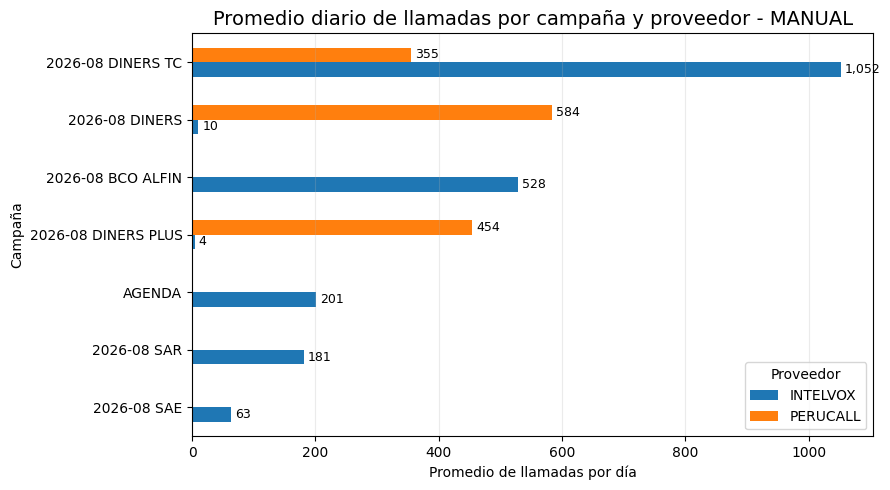

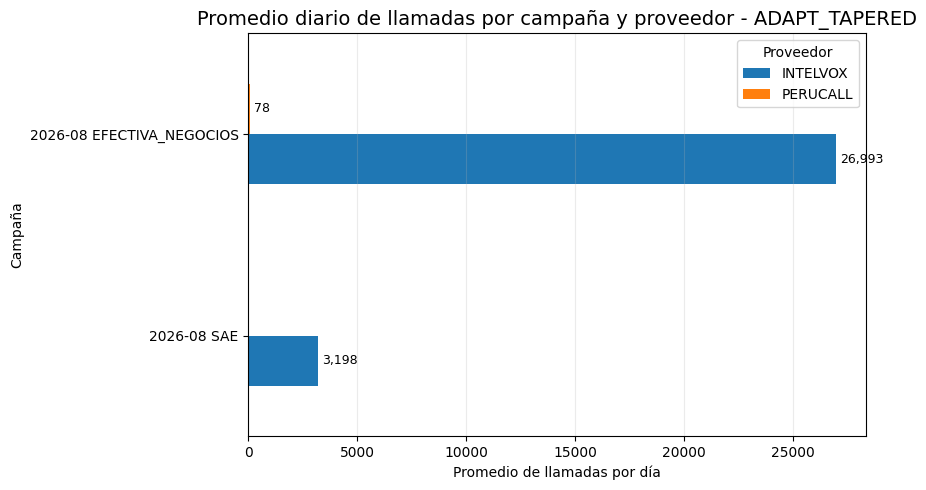

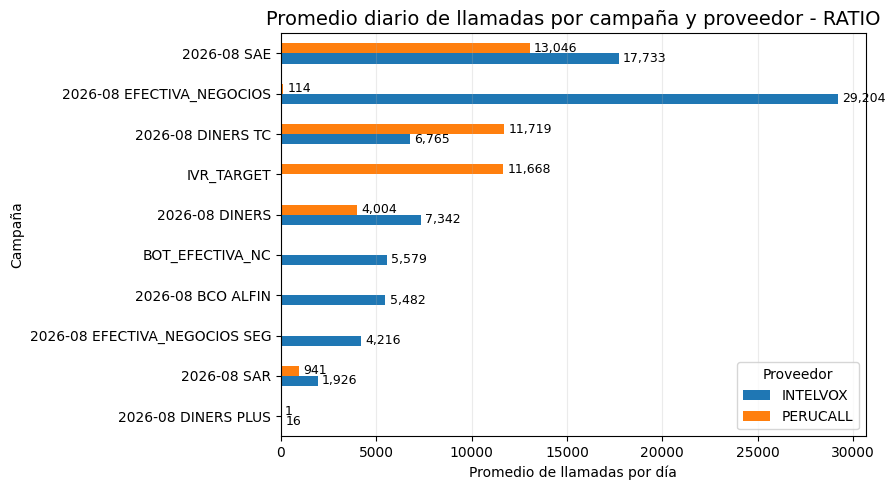

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PREPARAR FECHA
# ============================================================

df_promedio = df_total_mes_02.copy()

df_promedio["fecha"] = pd.to_datetime(
    df_promedio["fecha_hora_llamada"]
).dt.date


# ============================================================
# ORDEN DIAL
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]


# ============================================================
# GRÁFICO POR DIAL METHOD
# ============================================================

for metodo in orden_dial:

    df_metodo = df_promedio[
        df_promedio["dial_method_historico"] == metodo
    ].copy()

    if df_metodo.empty:
        continue


    # --------------------------------------------------------
    # 1. LLAMADAS POR DÍA
    # campaña + proveedor + fecha
    # --------------------------------------------------------

    llamadas_dia = (
        df_metodo
        .groupby(
            [
                "fecha",
                "nombre_campana",
                "proveedor"
            ]
        )
        .size()
        .reset_index(name="cantidad_llamadas")
    )


    # --------------------------------------------------------
    # 2. PROMEDIO DIARIO
    # --------------------------------------------------------

    promedio_diario = (
        llamadas_dia
        .groupby(
            [
                "nombre_campana",
                "proveedor"
            ]
        )["cantidad_llamadas"]
        .mean()
        .reset_index(name="promedio_llamadas_dia")
    )


    # --------------------------------------------------------
    # 3. PIVOT PARA GRÁFICO
    # --------------------------------------------------------

    df_grafico = (
        promedio_diario
        .pivot(
            index="nombre_campana",
            columns="proveedor",
            values="promedio_llamadas_dia"
        )
        .fillna(0)
    )


    # --------------------------------------------------------
    # 4. ORDENAR POR PROMEDIO TOTAL
    # --------------------------------------------------------

    df_grafico["TOTAL"] = df_grafico.sum(axis=1)

    df_grafico = (
        df_grafico
        .sort_values(
            "TOTAL",
            ascending=True
        )
        .drop(columns="TOTAL")
    )


    # --------------------------------------------------------
    # 5. GRÁFICO
    # --------------------------------------------------------

    ax = df_grafico.plot(
        kind="barh",
        figsize=(9, 5)
    )


    # --------------------------------------------------------
    # 6. ETIQUETAS
    # --------------------------------------------------------

    for container in ax.containers:

        labels = [
            f"{v:,.0f}" if v > 0 else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )


    # --------------------------------------------------------
    # 7. FORMATO
    # --------------------------------------------------------

    ax.set_title(
        f"Promedio diario de llamadas por campaña y proveedor - {metodo}",
        fontsize=14
    )

    ax.set_xlabel(
        "Promedio de llamadas por día"
    )

    ax.set_ylabel(
        "Campaña"
    )

    ax.legend(
        title="Proveedor"
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

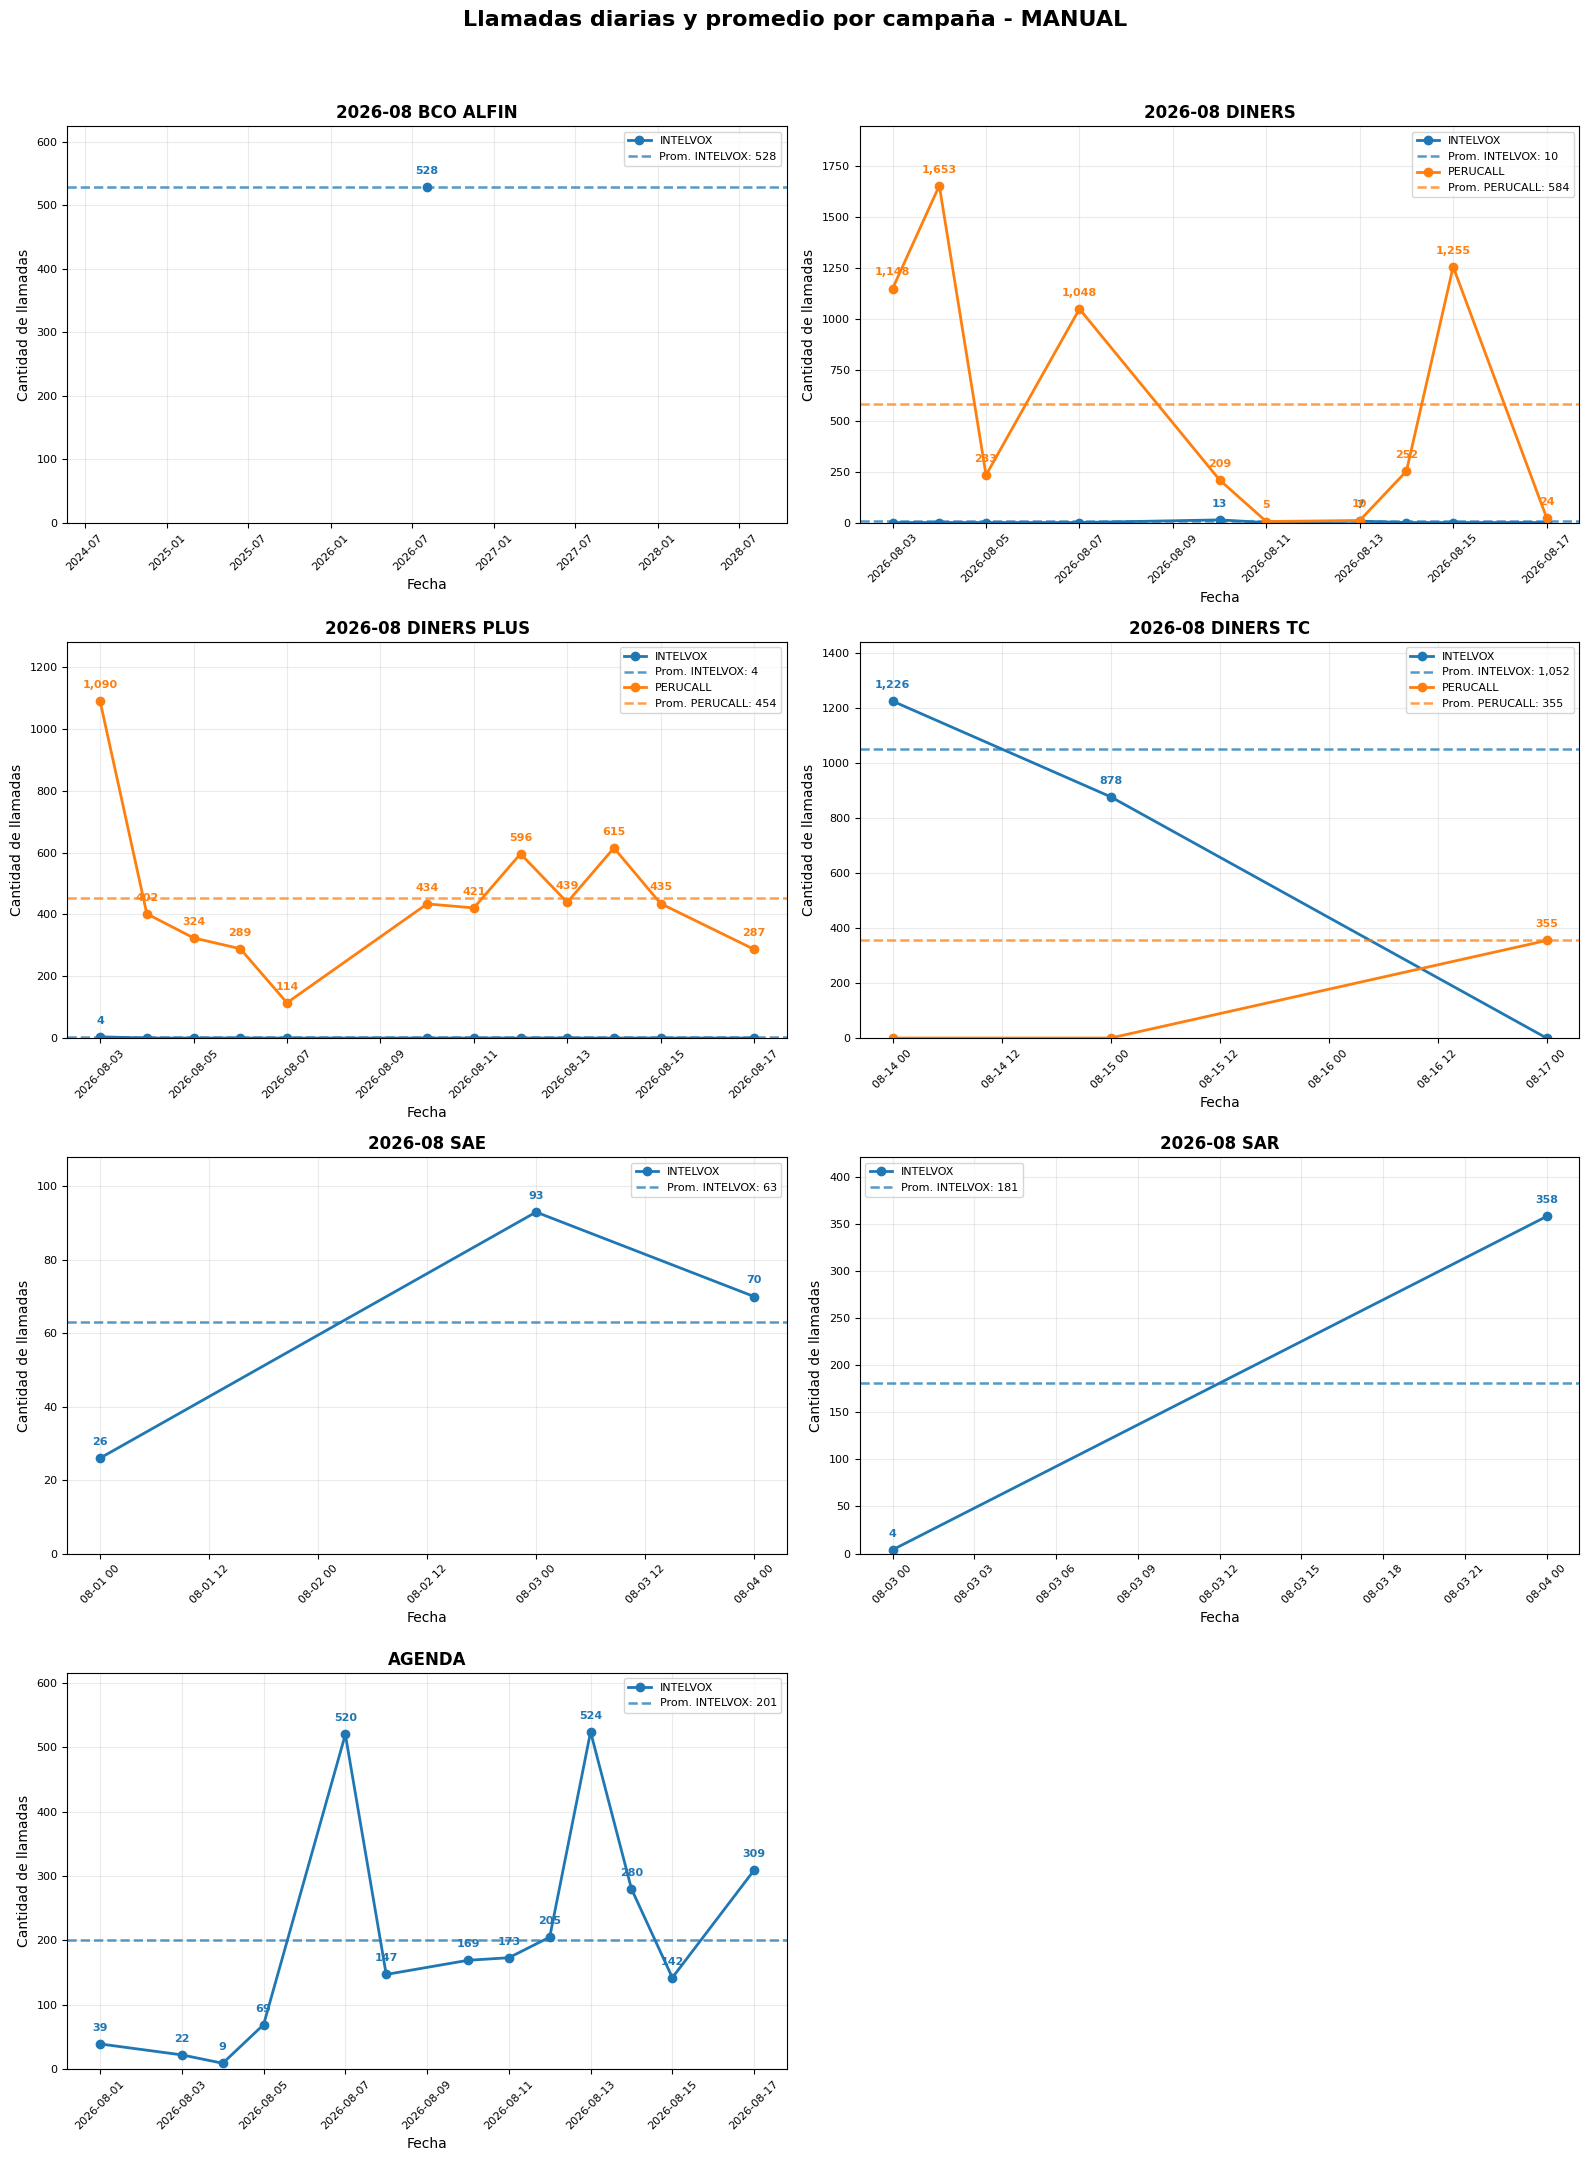

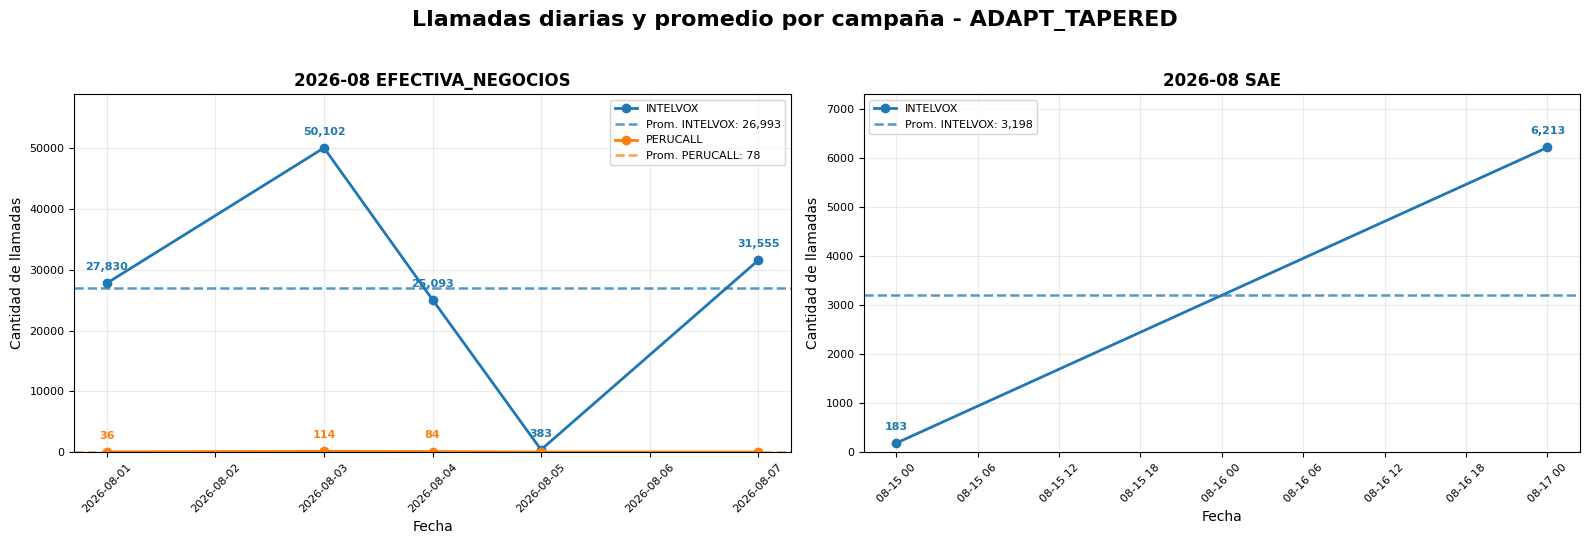

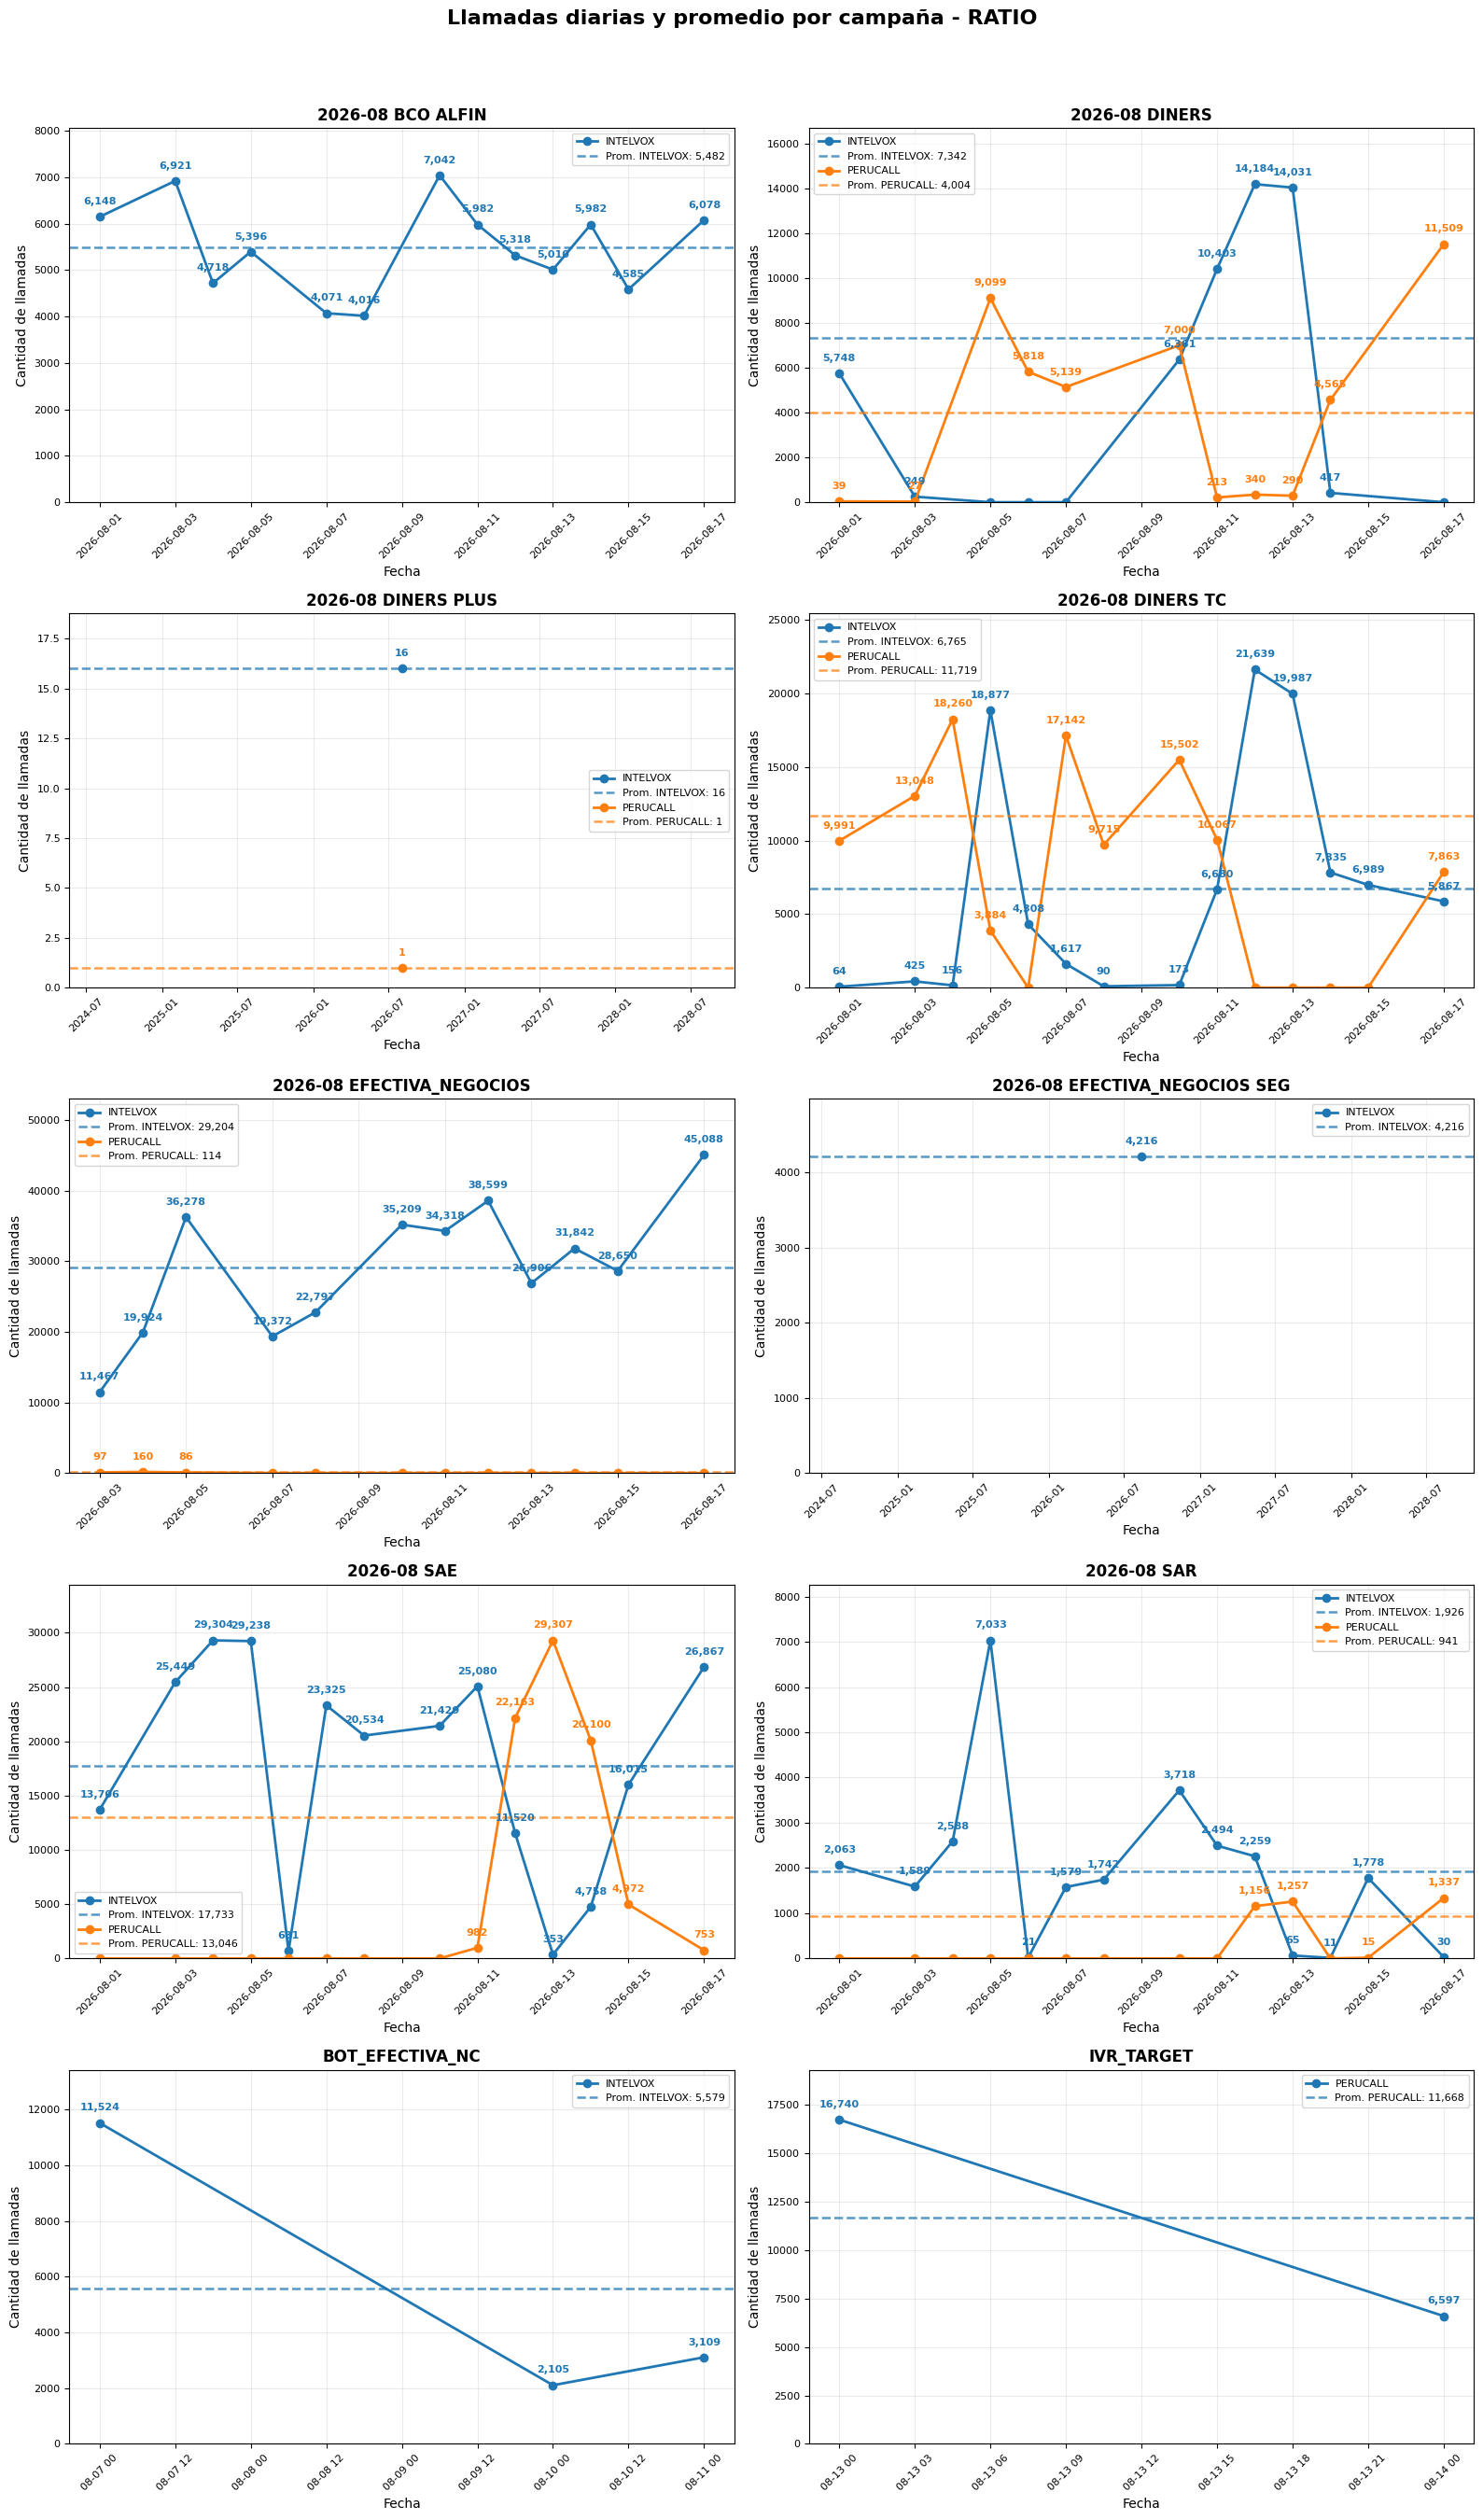

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# ============================================================
# PREPARAR FECHA
# ============================================================

df_diario = df_total_mes_02.copy()

df_diario["fecha"] = pd.to_datetime(
    df_diario["fecha_hora_llamada"]
).dt.date


# ============================================================
# ORDEN DIAL
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]


# ============================================================
# GRÁFICOS POR DIAL METHOD
# ============================================================

for metodo in orden_dial:

    # --------------------------------------------------------
    # FILTRAR MÉTODO
    # --------------------------------------------------------

    df_metodo = df_diario[
        df_diario["dial_method_historico"] == metodo
    ].copy()

    if df_metodo.empty:
        continue


    # ========================================================
    # CAMPAÑAS DEL MÉTODO
    # ========================================================

    campanas = sorted(
        df_metodo["nombre_campana"]
        .dropna()
        .unique()
    )

    n_campanas = len(campanas)


    # ========================================================
    # DISTRIBUCIÓN DE CUADROS
    # 2 gráficos por fila
    # ========================================================

    ncols = 2

    nrows = math.ceil(
        n_campanas / ncols
    )


    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 5.5 * nrows)
    )


    # --------------------------------------------------------
    # CONVERTIR AXES EN LISTA
    # --------------------------------------------------------

    if hasattr(axes, "flatten"):

        axes = axes.flatten()

    else:

        axes = [axes]


    # ========================================================
    # RECORRER CAMPAÑAS
    # ========================================================

    for i, campana in enumerate(campanas):

        ax = axes[i]


        # ====================================================
        # FILTRAR CAMPAÑA
        # ====================================================

        df_campana = df_metodo[
            df_metodo["nombre_campana"] == campana
        ].copy()


        # ====================================================
        # LLAMADAS POR DÍA Y PROVEEDOR
        # ====================================================

        llamadas_dia = (
            df_campana
            .groupby(
                [
                    "fecha",
                    "proveedor"
                ]
            )
            .size()
            .reset_index(
                name="cantidad"
            )
        )


        # ====================================================
        # PIVOT
        # ====================================================

        pivot = (
            llamadas_dia
            .pivot(
                index="fecha",
                columns="proveedor",
                values="cantidad"
            )
            .fillna(0)
            .sort_index()
        )


        # ====================================================
        # RECORRER PROVEEDORES
        # ====================================================

        for proveedor in pivot.columns:


            # ------------------------------------------------
            # LÍNEA DE LLAMADAS DIARIAS
            # ------------------------------------------------

            linea, = ax.plot(
                pivot.index,
                pivot[proveedor],
                marker="o",
                linewidth=2,
                markersize=6,
                label=proveedor
            )


            # ------------------------------------------------
            # CAPTURAR COLOR DEL PROVEEDOR
            # ------------------------------------------------

            color_proveedor = linea.get_color()


            # =================================================
            # ETIQUETAS DE CANTIDAD
            # =================================================

            for fecha, valor in zip(
                pivot.index,
                pivot[proveedor]
            ):

                if valor > 0:

                    ax.annotate(

                        f"{int(valor):,}",

                        xy=(
                            fecha,
                            valor
                        ),

                        xytext=(
                            0,
                            8
                        ),

                        textcoords="offset points",

                        ha="center",

                        va="bottom",

                        fontsize=8,

                        color=color_proveedor,

                        fontweight="bold"
                    )


            # =================================================
            # PROMEDIO DEL PROVEEDOR
            # Solo días donde tuvo llamadas
            # =================================================

            valores_activos = pivot.loc[
                pivot[proveedor] > 0,
                proveedor
            ]


            if len(valores_activos) > 0:

                promedio = (
                    valores_activos.mean()
                )


                # ------------------------------------------------
                # LÍNEA DEL PROMEDIO
                # MISMO COLOR QUE EL PROVEEDOR
                # ------------------------------------------------

                ax.axhline(

                    y=promedio,

                    color=color_proveedor,

                    linestyle="--",

                    alpha=0.75,

                    linewidth=1.8,

                    label=(
                        f"Prom. {proveedor}: "
                        f"{promedio:,.0f}"
                    )
                )


        # ====================================================
        # FORMATO INDIVIDUAL
        # ====================================================

        ax.set_title(
            campana,
            fontsize=12,
            fontweight="bold"
        )


        ax.set_xlabel(
            "Fecha",
            fontsize=10
        )


        ax.set_ylabel(
            "Cantidad de llamadas",
            fontsize=10
        )


        # ----------------------------------------------------
        # GRID
        # ----------------------------------------------------

        ax.grid(
            axis="both",
            alpha=0.25
        )


        # ----------------------------------------------------
        # FORMATO EJE X
        # ----------------------------------------------------

        ax.tick_params(
            axis="x",
            rotation=45,
            labelsize=8
        )


        ax.tick_params(
            axis="y",
            labelsize=8
        )


        # ----------------------------------------------------
        # LEYENDA
        # ----------------------------------------------------

        ax.legend(
            fontsize=8,
            loc="best",
            frameon=True
        )


        # ----------------------------------------------------
        # ESPACIO SUPERIOR PARA ETIQUETAS
        # ----------------------------------------------------

        ymax = ax.get_ylim()[1]

        ax.set_ylim(
            0,
            ymax * 1.12
        )


    # ========================================================
    # ELIMINAR CUADROS VACÍOS
    # ========================================================

    for j in range(
        n_campanas,
        len(axes)
    ):

        fig.delaxes(
            axes[j]
        )


    # ========================================================
    # TÍTULO GENERAL
    # ========================================================

    fig.suptitle(
        f"Llamadas diarias y promedio por campaña - {metodo}",
        fontsize=16,
        fontweight="bold"
    )


    # ========================================================
    # AJUSTAR ESPACIOS
    # ========================================================

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )


    # ========================================================
    # MOSTRAR
    # ========================================================

    plt.show()

## Respuestas SIP

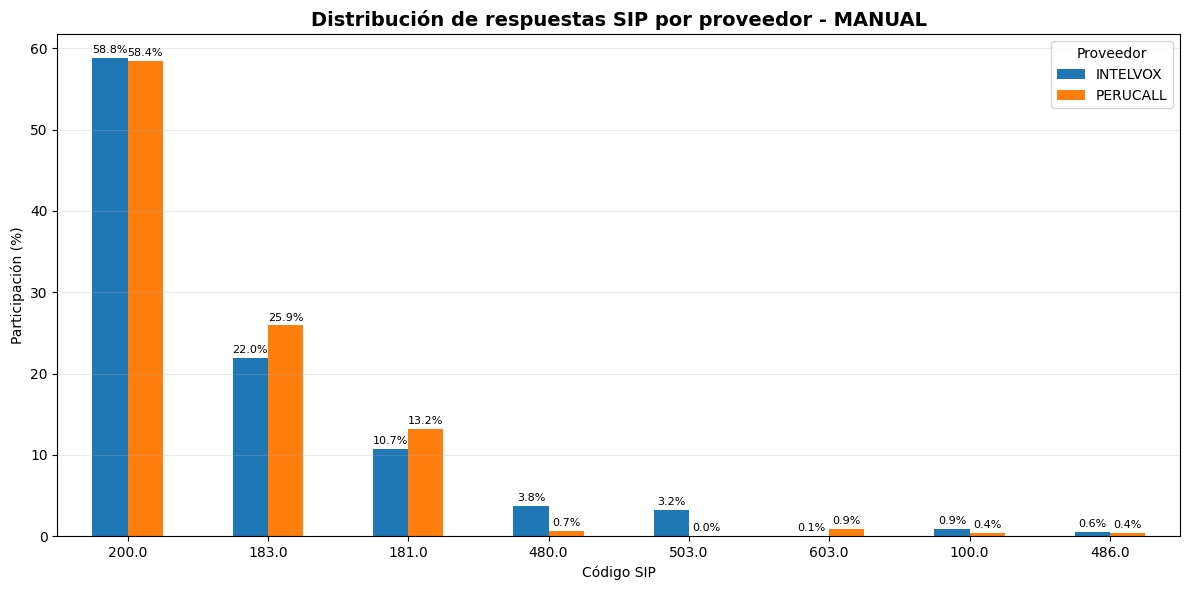

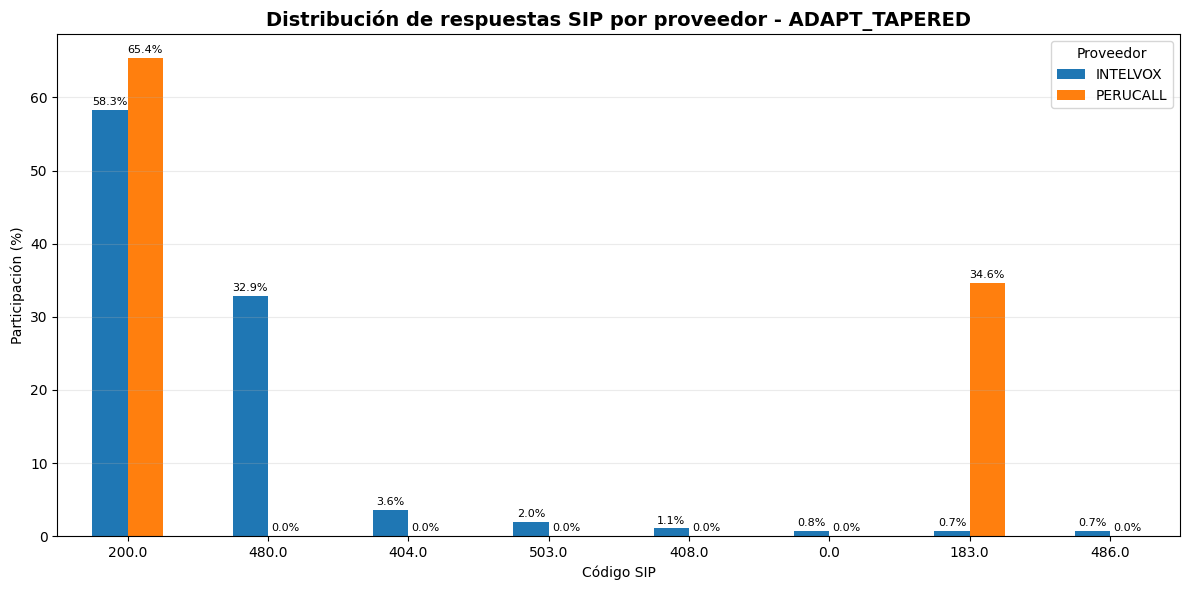

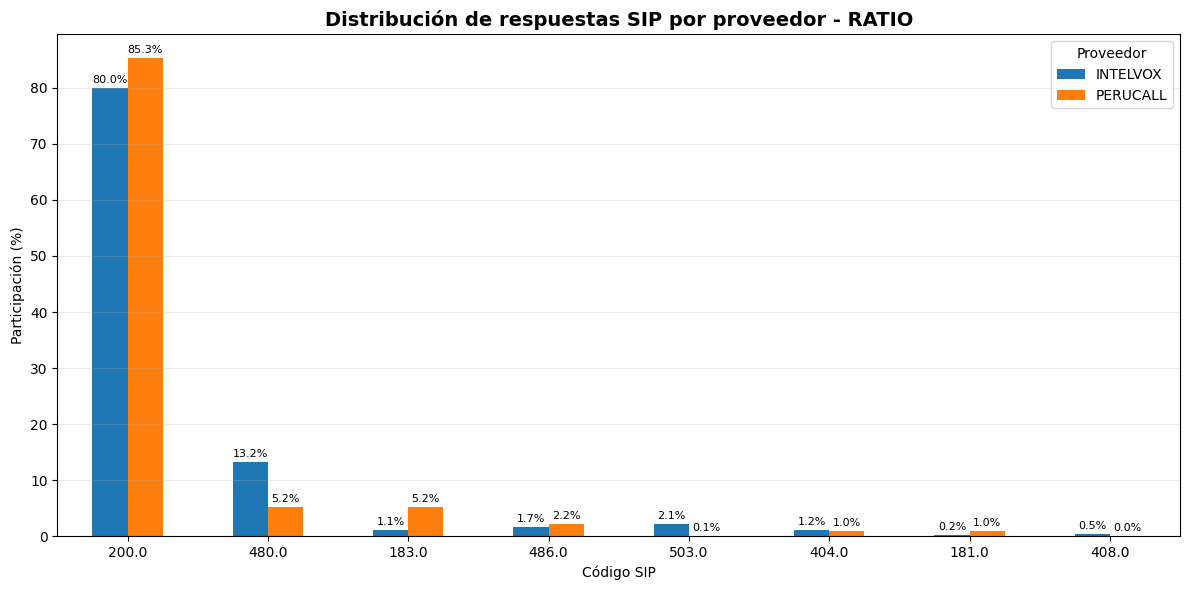

In [13]:
# ============================================================
# ORDEN DE dial_method_historico
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]
# ============================================================
# GRÁFICO SIP POR dial_method_historico
# ============================================================

for metodo in orden_dial:

    # --------------------------------------------------------
    # FILTRAR MÉTODO
    # --------------------------------------------------------

    df_sip = df_total_mes_02[
        df_total_mes_02["dial_method_historico"] == metodo
    ].copy()

    if df_sip.empty:
        continue

    # --------------------------------------------------------
    # PRINCIPALES SIP DEL MÉTODO
    # --------------------------------------------------------

    top_sip = (
        df_sip["sip_hangup_cause"]
        .value_counts()
        .head(8)
        .index
    )

    # --------------------------------------------------------
    # RESUMEN POR PROVEEDOR + SIP
    # --------------------------------------------------------

    df_sip_grafico = (
        df_sip[
            df_sip["sip_hangup_cause"].isin(top_sip)
        ]
        .groupby(
            [
                "proveedor",
                "sip_hangup_cause"
            ],
            dropna=False
        )
        .size()
        .reset_index(name="cantidad")
    )

    # --------------------------------------------------------
    # PORCENTAJE DENTRO DE CADA PROVEEDOR
    # --------------------------------------------------------

    df_sip_grafico["porcentaje"] = (
        df_sip_grafico["cantidad"]
        /
        df_sip_grafico
        .groupby("proveedor")["cantidad"]
        .transform("sum")
        * 100
    )

    # --------------------------------------------------------
    # PIVOT
    # --------------------------------------------------------

    tabla_sip_grafico = (
        df_sip_grafico
        .pivot(
            index="sip_hangup_cause",
            columns="proveedor",
            values="porcentaje"
        )
        .fillna(0)
    )

    # Mantener orden del TOP SIP
    tabla_sip_grafico = (
        tabla_sip_grafico
        .reindex(top_sip)
        .fillna(0)
    )

    # --------------------------------------------------------
    # GRÁFICO
    # --------------------------------------------------------

    ax = tabla_sip_grafico.plot(
        kind="bar",
        figsize=(12, 6)
    )

    ax.set_title(
        f"Distribución de respuestas SIP por proveedor - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Código SIP")
    ax.set_ylabel("Participación (%)")

    ax.legend(
        title="Proveedor"
    )

    plt.xticks(
        rotation=0
    )

    # --------------------------------------------------------
    # ETIQUETAS %
    # --------------------------------------------------------

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=2,
            fontsize=8
        )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

### Contactabilidad

In [14]:
df_total_mes_02.columns

Index(['lead_id', 'uniqueid', 'vendor_lead_code', 'dial_method_actual',
       'auto_dial_level_actual', 'hopper_level_actual', 'numero_campana',
       'dni_ejecutivo', 'ejecutivo', 'nombre_campana', 'fecha_hora_llamada',
       'duracion', 'call_result', 'list_description', 'list_name',
       'phone_number', 'fecha_agenda', 'comentarios', 'codigo',
       'fecha_configuracion_historica', 'admin_log_id_configuracion',
       'dial_method_historico', 'auto_dial_level_historico',
       'hopper_level_historico', 'uniqueid_match', 'call_date', 'proveedor',
       'outbound_cid', 'outbound_cid_limpio', 'sip_hangup_cause',
       'sip_hangup_reason', 'extension', 'channel', 'context', 'server_ip',
       'caller_code', 'diferencia_segundos', 'event_time_agent', 'wait_sec',
       'talk_sec', 'dispo_sec', 'dead_sec', 'pause_sec', 'status_agent',
       'campaign_id_agent', 'pause_type', 'diferencia_seg_agent', 'servidor',
       'estado', 'descripcion', 'tipo_contacto'],
      dtype='objec

In [19]:
df_total_mes_02["tipo_contacto_15s"].unique()

array(['NO CONTACTO', 'CONTACTO_15S', 'CONTACTO_MENOR_15S', 'CONTACTO'],
      dtype=object)

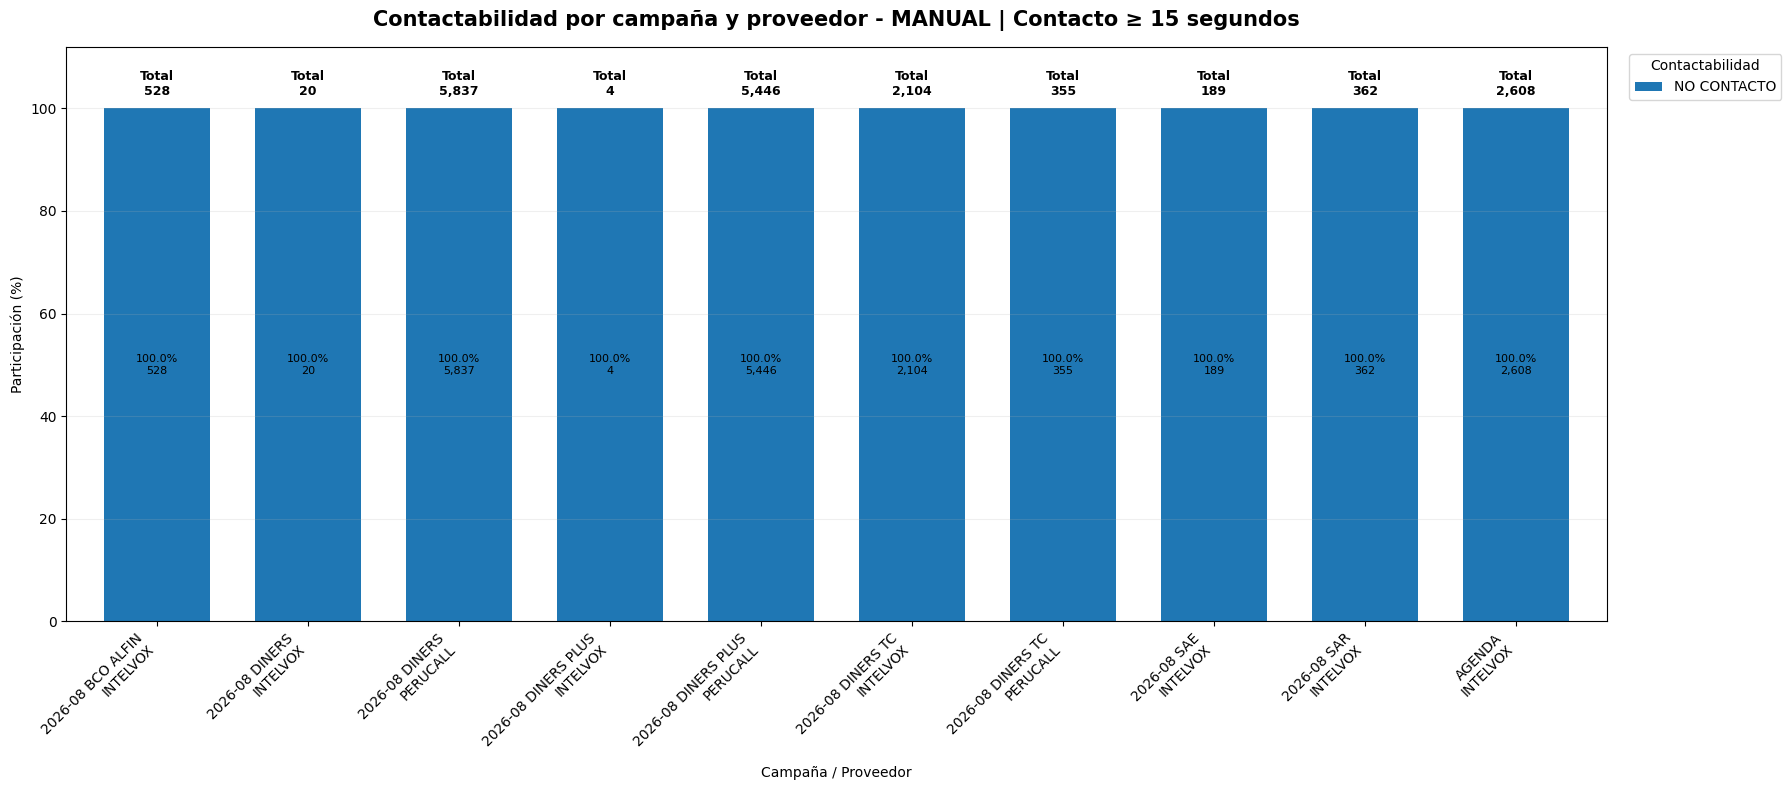

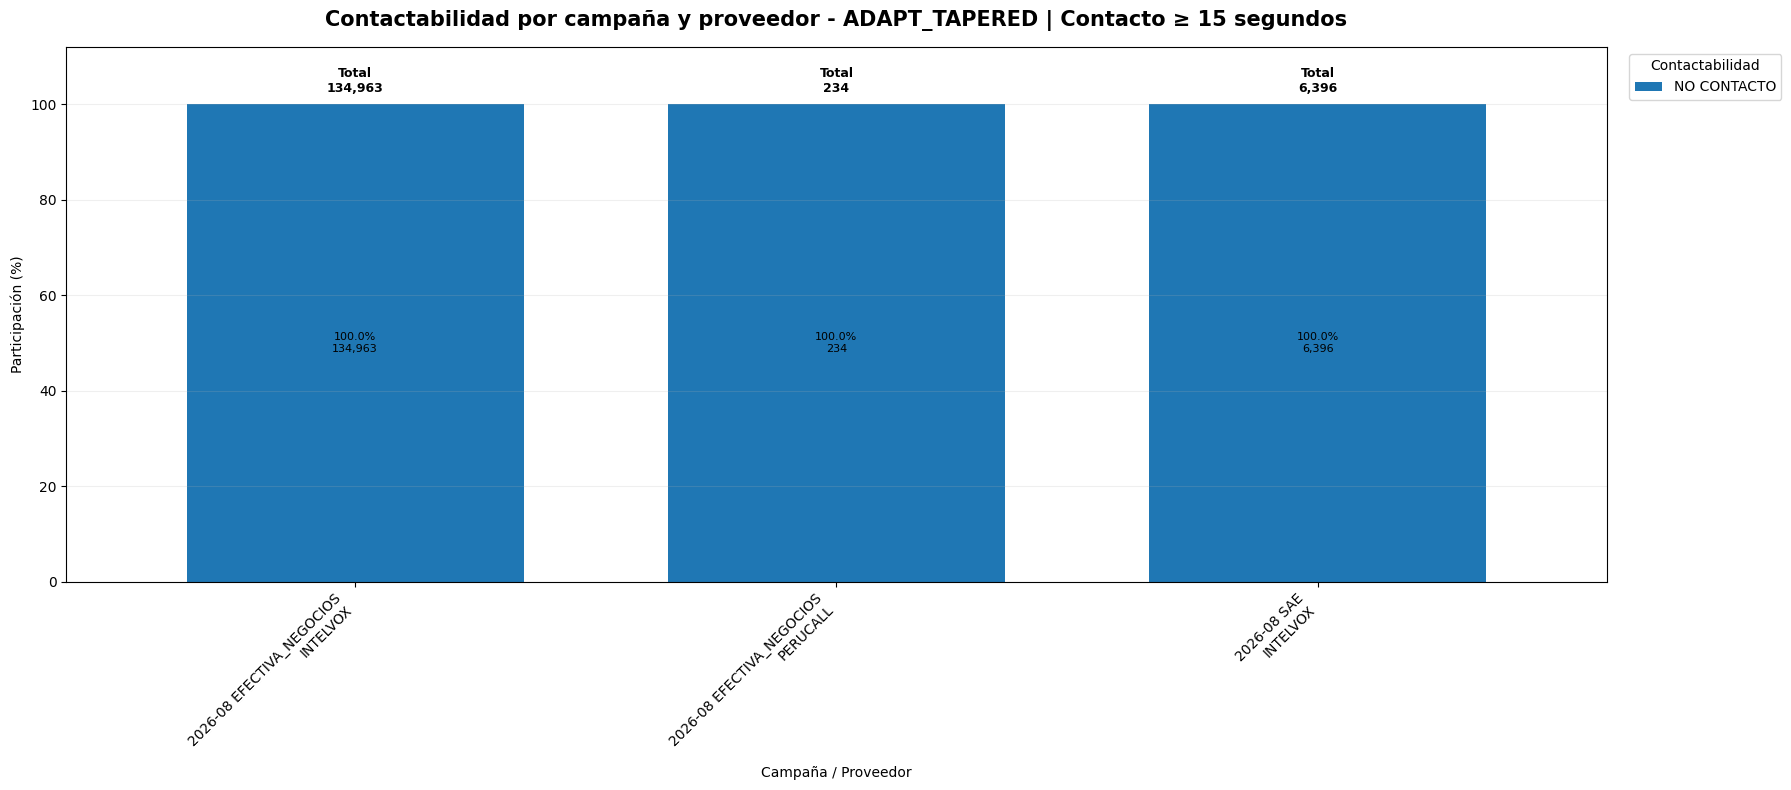

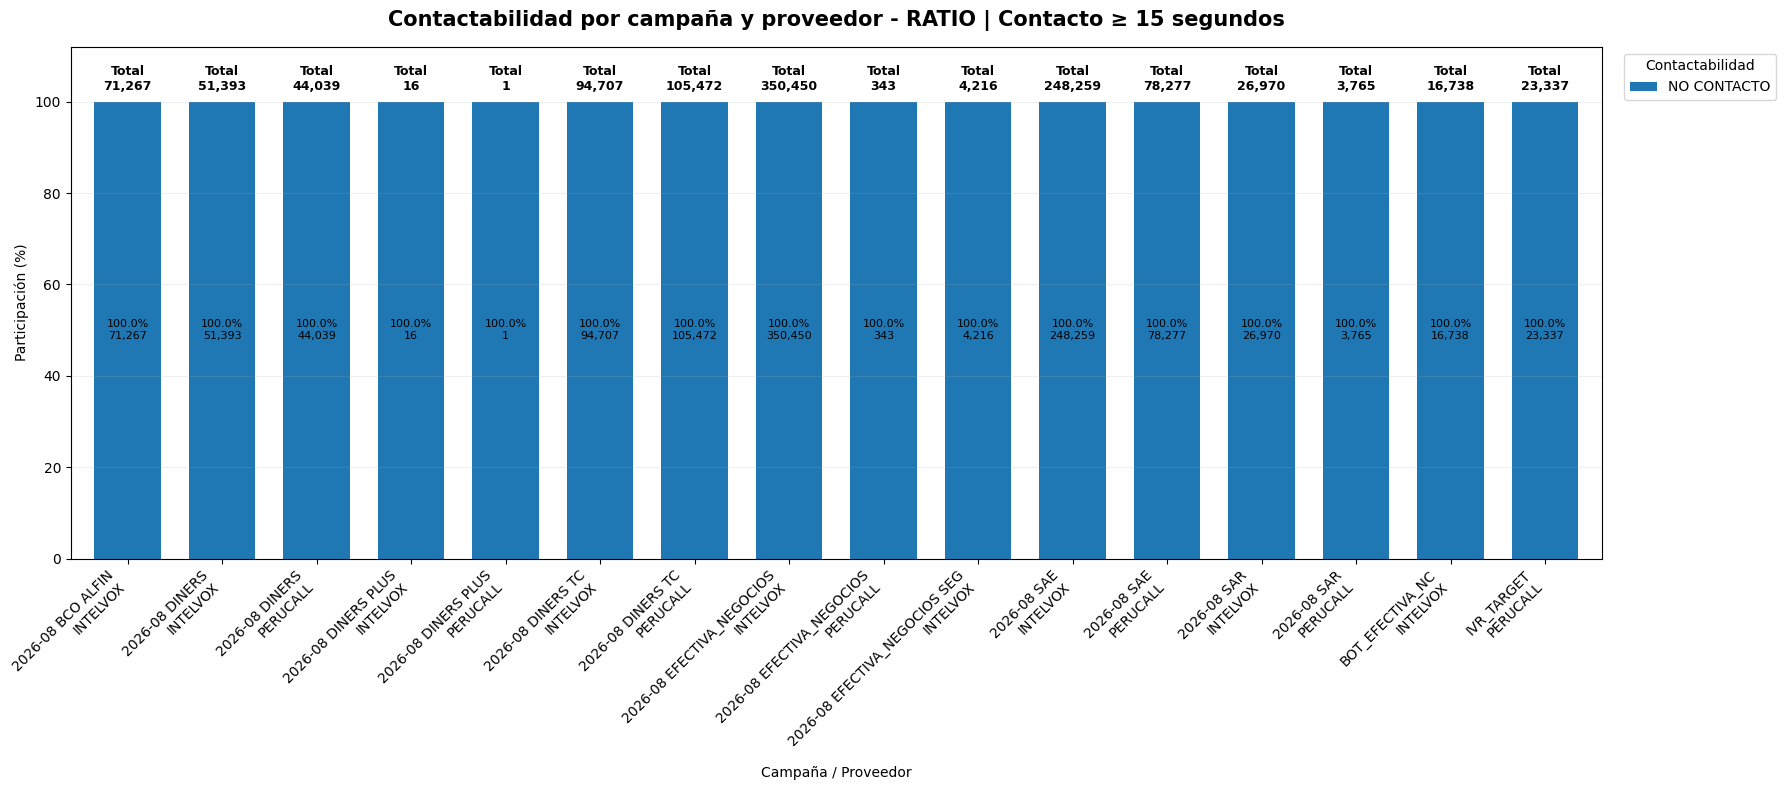

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# COPIA
# ============================================================

df_contactabilidad = df_total_mes_02.copy()


# ============================================================
# NORMALIZAR CAMPOS
# ============================================================

df_contactabilidad["tipo_contacto_15s"] = (
    df_contactabilidad["tipo_contacto_15s"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_contactabilidad["dial_method_historico"] = (
    df_contactabilidad["dial_method_historico"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_contactabilidad["proveedor"] = (
    df_contactabilidad["proveedor"]
    .astype("string")
    .str.strip()
    .str.upper()
)


# ============================================================
# DURACIÓN NUMÉRICA
# ============================================================

df_contactabilidad["duracion"] = pd.to_numeric(
    df_contactabilidad["duracion"],
    errors="coerce"
)


# ============================================================
# NUEVA CLASIFICACIÓN DE CONTACTABILIDAD
#
# CONTACTO:
#   tipo_contacto_15s = CONTACTO
#   Y duración >= 15 segundos
#
# TODO LO DEMÁS = NO CONTACTO
# ============================================================

df_contactabilidad["contactabilidad_15s"] = np.where(

    (
        (df_contactabilidad["tipo_contacto_15s"] == "CONTACTO")
        &
        (df_contactabilidad["duracion"] >= 15)
    ),

    "CONTACTO",

    "NO CONTACTO"
)


# ============================================================
# ORDEN DE dial_method_historico
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]


# ============================================================
# GRÁFICO POR dial_method_historico
# ============================================================

for metodo in orden_dial:

    # ========================================================
    # 1. FILTRAR dial_method_historico
    # ========================================================

    df_metodo = df_contactabilidad[
        df_contactabilidad["dial_method_historico"] == metodo
    ].copy()

    if df_metodo.empty:
        continue


    # ========================================================
    # 2. RESUMEN
    # ========================================================

    resumen_campana = (
        df_metodo
        .groupby(
            [
                "nombre_campana",
                "proveedor",
                "contactabilidad_15s"
            ],
            dropna=False
        )
        .size()
        .reset_index(name="cantidad")
    )


    # ========================================================
    # 3. TOTAL CAMPAÑA + PROVEEDOR
    # ========================================================

    resumen_campana["total"] = (
        resumen_campana
        .groupby(
            [
                "nombre_campana",
                "proveedor"
            ]
        )["cantidad"]
        .transform("sum")
    )


    # ========================================================
    # 4. PORCENTAJE
    # ========================================================

    resumen_campana["porcentaje"] = (
        resumen_campana["cantidad"]
        /
        resumen_campana["total"]
        * 100
    )


    # ========================================================
    # 5. ETIQUETA EJE X
    # ========================================================

    resumen_campana["grupo"] = (
        resumen_campana["nombre_campana"].astype(str)
        + "\n"
        + resumen_campana["proveedor"].astype(str)
    )


    # ========================================================
    # 6. PIVOT PORCENTAJES
    # ========================================================

    pivot_pct = resumen_campana.pivot_table(
        index="grupo",
        columns="contactabilidad_15s",
        values="porcentaje",
        aggfunc="sum",
        fill_value=0
    )


    # ========================================================
    # 7. PIVOT CANTIDADES
    # ========================================================

    pivot_cantidad = resumen_campana.pivot_table(
        index="grupo",
        columns="contactabilidad_15s",
        values="cantidad",
        aggfunc="sum",
        fill_value=0
    )


    # ========================================================
    # 8. ORDEN DE COLUMNAS
    # ========================================================

    columnas = [
        x
        for x in [
            "CONTACTO_15S",
            "CONTACTO_MENOR_15S",
            "NO CONTACTO"
        ]
        if x in pivot_pct.columns
    ]

    pivot_pct = pivot_pct[columnas]

    pivot_cantidad = (
        pivot_cantidad
        .reindex(
            index=pivot_pct.index,
            columns=columnas,
            fill_value=0
        )
    )


    # ========================================================
    # 9. TOTAL POR BARRA
    # ========================================================

    total_por_barra = (
        pivot_cantidad
        .sum(axis=1)
    )


    # ========================================================
    # 10. GRÁFICO
    # ========================================================

    ax = pivot_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(18, 8),
        width=0.70
    )


    ax.set_title(
        f"Contactabilidad por campaña y proveedor - "
        f"{metodo} | Contacto ≥ 15 segundos",
        fontsize=15,
        fontweight="bold",
        pad=15
    )


    ax.set_xlabel(
        "Campaña / Proveedor"
    )

    ax.set_ylabel(
        "Participación (%)"
    )


    # Espacio arriba para total
    ax.set_ylim(
        0,
        112
    )


    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )


    # ========================================================
    # 11. ETIQUETAS INTERNAS
    # % + CANTIDAD
    # ========================================================

    for container, tipo in zip(
        ax.containers,
        pivot_pct.columns
    ):

        etiquetas = []

        for grupo in pivot_pct.index:

            porcentaje = pivot_pct.loc[
                grupo,
                tipo
            ]

            cantidad = pivot_cantidad.loc[
                grupo,
                tipo
            ]


            if porcentaje >= 3:

                etiquetas.append(
                    f"{porcentaje:.1f}%\n"
                    f"{cantidad:,.0f}"
                )

            else:

                etiquetas.append("")


        ax.bar_label(
            container,
            labels=etiquetas,
            label_type="center",
            fontsize=8
        )


    # ========================================================
    # 12. TOTAL ARRIBA
    # ========================================================

    for i, total in enumerate(total_por_barra):

        ax.text(
            i,
            102,
            f"Total\n{total:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )


    # ========================================================
    # 13. LEYENDA
    # ========================================================

    ax.legend(
        title="Contactabilidad",
        bbox_to_anchor=(1.01, 1),
        loc="upper left"
    )


    ax.grid(
        axis="y",
        alpha=0.20
    )

    plt.tight_layout()

    plt.show()

In [16]:
import pandas as pd
import numpy as np

# ============================================================
# 1. COPIA
# ============================================================

df_intentos = df_total_mes_02.copy()

df_intentos["fecha_hora_llamada"] = pd.to_datetime(
    df_intentos["fecha_hora_llamada"]
)

# ============================================================
# 2. ORDENAR CRONOLÓGICAMENTE
# campaña + método + proveedor + cliente
# ============================================================

df_intentos = df_intentos.sort_values(
    [
        "nombre_campana",
        "dial_method_historico",
        "proveedor",
        "vendor_lead_code",
        "fecha_hora_llamada"
    ]
)

# ============================================================
# 3. NUMERAR INTENTOS
#
# Se reinicia para cada:
# campaña + método + proveedor + cliente
# ============================================================

df_intentos["nro_intento"] = (
    df_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code"
        ]
    )
    .cumcount()
    + 1
)

# ============================================================
# 4. RANGO DE INTENTOS
# ============================================================

df_intentos["rango_intento"] = np.select(
    [
        df_intentos["nro_intento"] == 1,
        df_intentos["nro_intento"] == 2,
        df_intentos["nro_intento"] == 3,
        df_intentos["nro_intento"] == 4,
        df_intentos["nro_intento"] >= 5
    ],
    [
        "1 intento",
        "2 intentos",
        "3 intentos",
        "4 intentos",
        "5+ intentos"
    ],
    default="SIN CLASIFICAR"
)

# ============================================================
# 5. SOLO CONTACTOS
# ============================================================

df_contactos = df_intentos[
    df_intentos["tipo_contacto"] == "CONTACTO"
].copy()

# ============================================================
# 6. PRIMER CONTACTO
#
# Primer contacto por:
# campaña + método + proveedor + cliente
# ============================================================

primer_contacto = (
    df_contactos
    .sort_values(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code",
            "nro_intento"
        ]
    )
    .drop_duplicates(
        subset=[
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code"
        ],
        keep="first"
    )
)

# ============================================================
# 7. RESUMEN
# ============================================================

resumen_intentos = (
    primer_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ]
    )
    .agg(
        clientes_contactados=(
            "vendor_lead_code",
            "nunique"
        ),
        promedio_intentos=(
            "nro_intento",
            "mean"
        ),
        mediana_intentos=(
            "nro_intento",
            "median"
        ),
        max_intentos=(
            "nro_intento",
            "max"
        )
    )
    .reset_index()
)

distribucion_intentos = (
    df_intentos
    .groupby(
        [
            "nombre_campana",
            "proveedor",
            "dial_method_historico",
            "rango_intento"
        ],
        dropna=False,
        observed=False
    )
    .size()
    .reset_index(name="cantidad")
)


# ============================================================
# 3. TOTAL POR CAMPAÑA + PROVEEDOR + MÉTODO
# ============================================================

distribucion_intentos["total"] = (
    distribucion_intentos
    .groupby(
        [
            "nombre_campana",
            "proveedor",
            "dial_method_historico"
        ]
    )["cantidad"]
    .transform("sum")
)

distribucion_intentos["porcentaje"] = (
    distribucion_intentos["cantidad"]
    / distribucion_intentos["total"]
    * 100
)

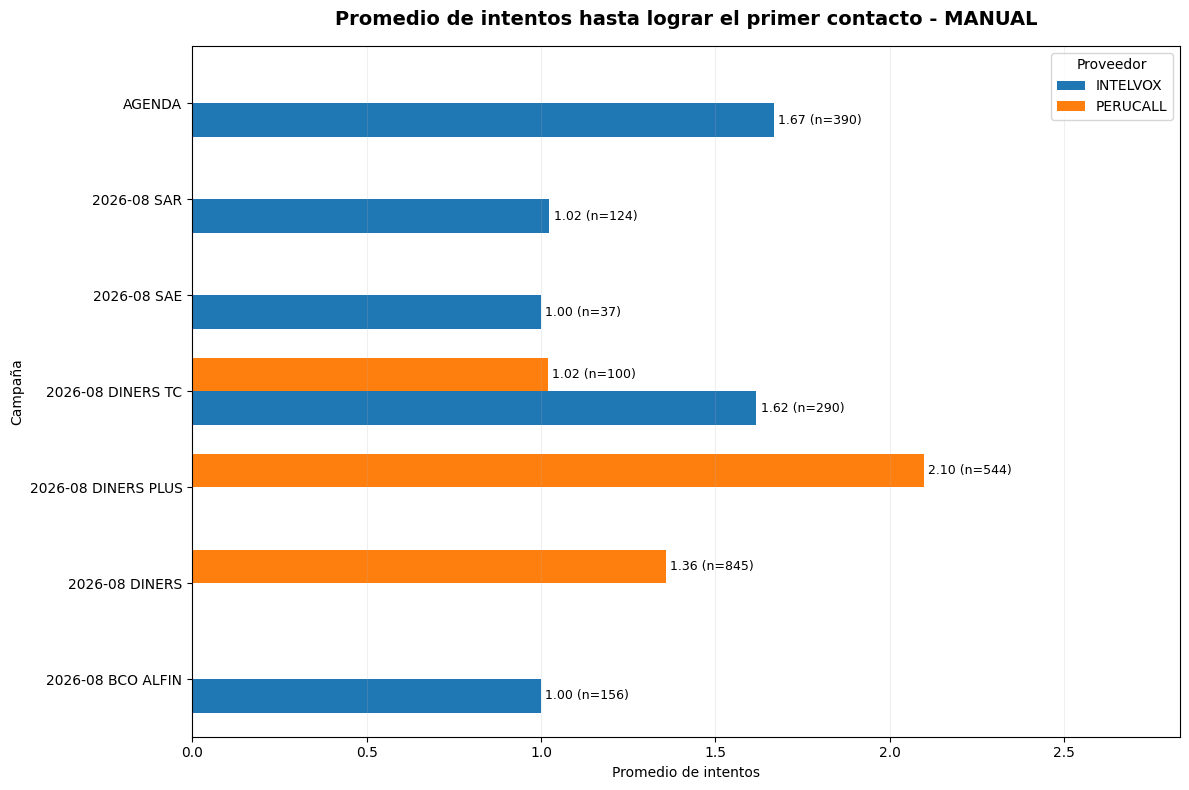

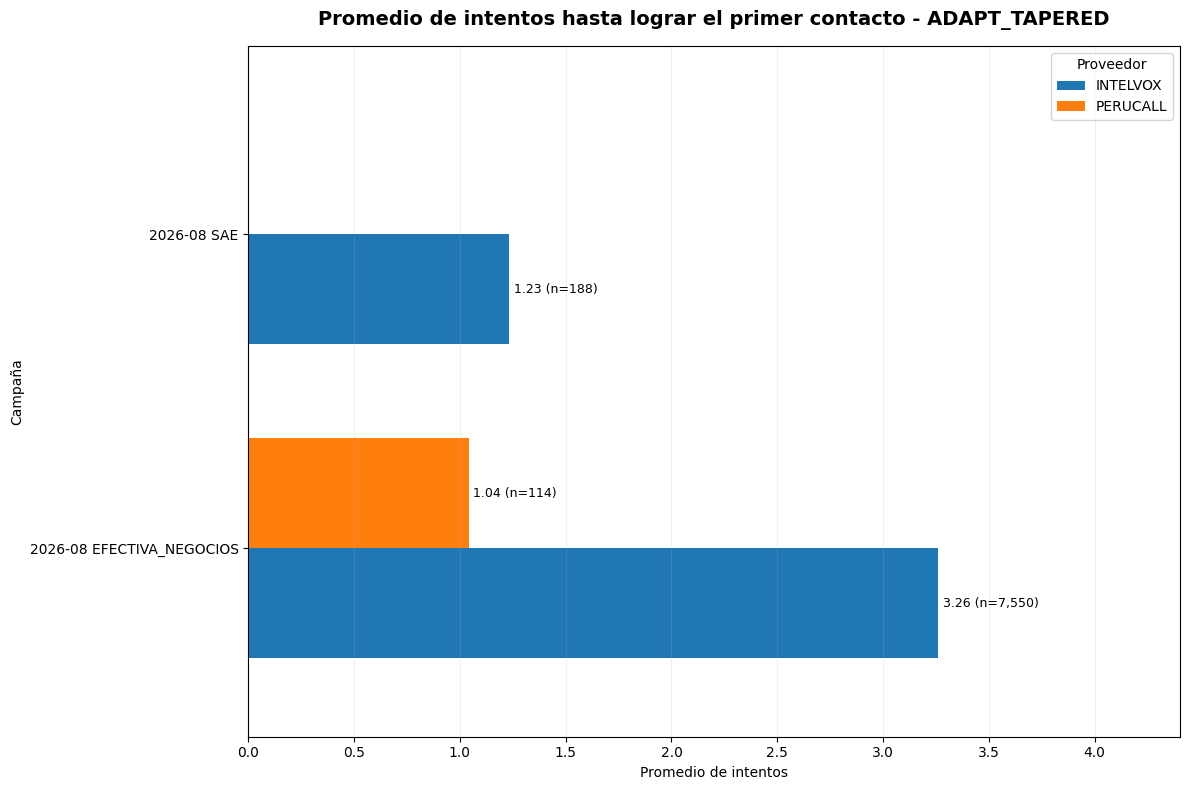

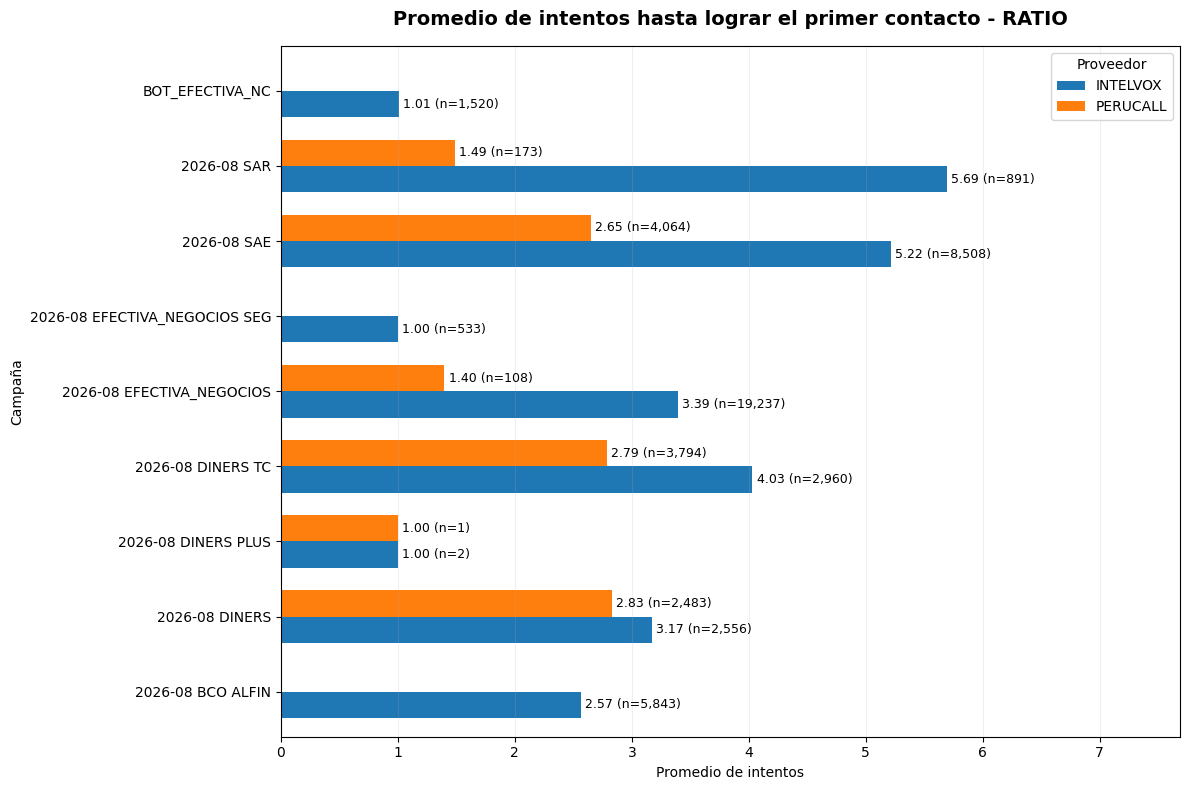

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ORDEN DE dial_method_historico
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]


# ============================================================
# GRÁFICO POR dial_method_historico
# ============================================================

for metodo in orden_dial:

    # ========================================================
    # 1. FILTRAR dial_method_historico
    # ========================================================

    df_plot = resumen_intentos[
        resumen_intentos["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    # ========================================================
    # 2. ORDENAR
    # ========================================================

    df_plot = df_plot.sort_values(
        [
            "nombre_campana",
            "proveedor"
        ]
    )

    # ========================================================
    # 3. PIVOT PROMEDIO DE INTENTOS
    # ========================================================

    pivot_promedio = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="promedio_intentos",
        aggfunc="mean"
    )

    # ========================================================
    # 4. PIVOT CANTIDAD DE CLIENTES
    # ========================================================

    pivot_clientes = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="clientes_contactados",
        aggfunc="sum"
    )

    # ========================================================
    # 5. ORDENAR PROVEEDORES
    # ========================================================

    proveedores = [
        x
        for x in [
            "INTELVOX",
            "PERUCALL"
        ]
        if x in pivot_promedio.columns
    ]

    pivot_promedio = pivot_promedio[
        proveedores
    ]

    pivot_clientes = (
        pivot_clientes
        .reindex(
            index=pivot_promedio.index,
            columns=proveedores
        )
    )

    # ========================================================
    # 6. GRÁFICO
    # ========================================================

    ax = pivot_promedio.plot(
        kind="barh",
        figsize=(12, 8),
        width=0.70
    )

    ax.set_title(
        f"Promedio de intentos hasta lograr el primer contacto - {metodo}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Promedio de intentos"
    )

    ax.set_ylabel(
        "Campaña"
    )

    # ========================================================
    # 7. ETIQUETAS
    # Promedio + número de clientes
    # ========================================================

    for container, proveedor in zip(
        ax.containers,
        pivot_promedio.columns
    ):

        etiquetas = []

        for campana in pivot_promedio.index:

            promedio = pivot_promedio.loc[
                campana,
                proveedor
            ]

            clientes = pivot_clientes.loc[
                campana,
                proveedor
            ]

            if (
                not np.isnan(promedio)
                and not np.isnan(clientes)
            ):

                etiquetas.append(
                    f"{promedio:.2f} "
                    f"(n={clientes:,.0f})"
                )

            else:

                etiquetas.append("")

        ax.bar_label(
            container,
            labels=etiquetas,
            padding=3,
            fontsize=9
        )

    # ========================================================
    # 8. LEYENDA
    # ========================================================

    ax.legend(
        title="Proveedor"
    )

    ax.grid(
        axis="x",
        alpha=0.20
    )

    # ========================================================
    # 9. ESPACIO PARA ETIQUETAS
    # ========================================================

    maximo = pivot_promedio.max().max()

    if pd.notna(maximo):

        ax.set_xlim(
            0,
            maximo * 1.35
        )

    plt.tight_layout()
    plt.show()

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. COPIA DE LA TABLA ORIGEN
# ============================================================

df_intentos = df_total_mes_02.copy()


# ============================================================
# 2. NORMALIZAR CAMPOS
# ============================================================

df_intentos["fecha_hora_llamada"] = pd.to_datetime(
    df_intentos["fecha_hora_llamada"],
    errors="coerce"
)

columnas_texto = [
    "nombre_campana",
    "dial_method_historico",
    "proveedor",
    "vendor_lead_code",
    "tipo_contacto"
]

for col in columnas_texto:

    df_intentos[col] = (
        df_intentos[col]
        .astype("string")
        .str.strip()
    )


df_intentos["dial_method_historico"] = (
    df_intentos["dial_method_historico"]
    .str.upper()
)

df_intentos["proveedor"] = (
    df_intentos["proveedor"]
    .str.upper()
)

df_intentos["tipo_contacto"] = (
    df_intentos["tipo_contacto"]
    .str.upper()
)


# ============================================================
# 3. ELIMINAR REGISTROS SIN INFORMACIÓN CLAVE
# ============================================================

df_intentos = df_intentos.dropna(
    subset=[
        "nombre_campana",
        "dial_method_historico",
        "proveedor",
        "vendor_lead_code",
        "fecha_hora_llamada"
    ]
).copy()


# ============================================================
# 4. ORDENAR CRONOLÓGICAMENTE
#
# El intento se calcula dentro de:
# campaña + método + proveedor + cliente
# ============================================================

df_intentos = (
    df_intentos
    .sort_values(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code",
            "fecha_hora_llamada"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. NUMERAR LOS INTENTOS
# ============================================================

df_intentos["nro_intento"] = (
    df_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code"
        ],
        dropna=False
    )
    .cumcount()
    + 1
)


# ============================================================
# 6. FILTRAR SOLO CONTACTOS
# ============================================================

df_contactos = df_intentos[
    df_intentos["tipo_contacto"] == "CONTACTO"
].copy()


# ============================================================
# 7. OBTENER EL PRIMER CONTACTO DEL CLIENTE
#
# Si un cliente tuvo:
#
# intento 1 -> NO CONTACTO
# intento 2 -> NO CONTACTO
# intento 3 -> CONTACTO
# intento 4 -> CONTACTO
#
# Nos quedamos solamente con intento 3.
# ============================================================

primer_contacto = (
    df_contactos
    .sort_values(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code",
            "nro_intento"
        ]
    )
    .drop_duplicates(
        subset=[
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "vendor_lead_code"
        ],
        keep="first"
    )
    .copy()
)


# ============================================================
# 8. CLASIFICAR EN RANGO DE INTENTO
# ============================================================

primer_contacto["rango_intento"] = np.select(
    [
        primer_contacto["nro_intento"] == 1,
        primer_contacto["nro_intento"] == 2,
        primer_contacto["nro_intento"] == 3,
        primer_contacto["nro_intento"] == 4,
        primer_contacto["nro_intento"] >= 5
    ],
    [
        "1 intento",
        "2 intentos",
        "3 intentos",
        "4 intentos",
        "5+ intentos"
    ],
    default="SIN CLASIFICAR"
)


# ============================================================
# 9. RESUMEN DE PROMEDIO DE INTENTOS
# ============================================================

resumen_intentos = (
    primer_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )
    .agg(
        clientes_contactados=(
            "vendor_lead_code",
            "nunique"
        ),

        promedio_intentos=(
            "nro_intento",
            "mean"
        ),

        mediana_intentos=(
            "nro_intento",
            "median"
        ),

        max_intentos=(
            "nro_intento",
            "max"
        )
    )
    .reset_index()
)


# ============================================================
# 10. DISTRIBUCIÓN DEL PRIMER CONTACTO
#
# IMPORTANTE:
# Sale de primer_contacto, NO de df_intentos.
# ============================================================

distribucion_intentos = (
    primer_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "rango_intento"
        ],
        dropna=False,
        observed=False
    )
    .agg(
        clientes=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)


# ============================================================
# 11. TOTAL DE CLIENTES CONTACTADOS
# POR CAMPAÑA + MÉTODO + PROVEEDOR
# ============================================================

distribucion_intentos["total_clientes"] = (
    distribucion_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )["clientes"]
    .transform("sum")
)


# ============================================================
# 12. PORCENTAJE
# ============================================================

distribucion_intentos["porcentaje"] = np.where(
    distribucion_intentos["total_clientes"] > 0,

    (
        distribucion_intentos["clientes"]
        / distribucion_intentos["total_clientes"]
        * 100
    ),

    0
)


# ============================================================
# 13. VALIDACIÓN
#
# Cada campaña/proveedor/método debe sumar aproximadamente 100%
# ============================================================

validacion_porcentaje = (
    distribucion_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )["porcentaje"]
    .sum()
    .reset_index(name="total_porcentaje")
)

print("\nVALIDACIÓN PORCENTAJES:")
print(validacion_porcentaje)


# ============================================================
# 14. VER DISTRIBUCIÓN
# ============================================================

print("\nDISTRIBUCIÓN:")
print(
    distribucion_intentos
    .sort_values(
        [
            "dial_method_historico",
            "nombre_campana",
            "proveedor",
            "rango_intento"
        ]
    )
)


VALIDACIÓN PORCENTAJES:
                   nombre_campana dial_method_historico proveedor  \
0               2026-08 BCO ALFIN                MANUAL  INTELVOX   
1               2026-08 BCO ALFIN                 RATIO  INTELVOX   
2                  2026-08 DINERS                MANUAL  PERUCALL   
3                  2026-08 DINERS                 RATIO  INTELVOX   
4                  2026-08 DINERS                 RATIO  PERUCALL   
5             2026-08 DINERS PLUS                MANUAL  PERUCALL   
6             2026-08 DINERS PLUS                 RATIO  INTELVOX   
7             2026-08 DINERS PLUS                 RATIO  PERUCALL   
8               2026-08 DINERS TC                MANUAL  INTELVOX   
9               2026-08 DINERS TC                MANUAL  PERUCALL   
10              2026-08 DINERS TC                 RATIO  INTELVOX   
11              2026-08 DINERS TC                 RATIO  PERUCALL   
12      2026-08 EFECTIVA_NEGOCIOS         ADAPT_TAPERED  INTELVOX   
13      2

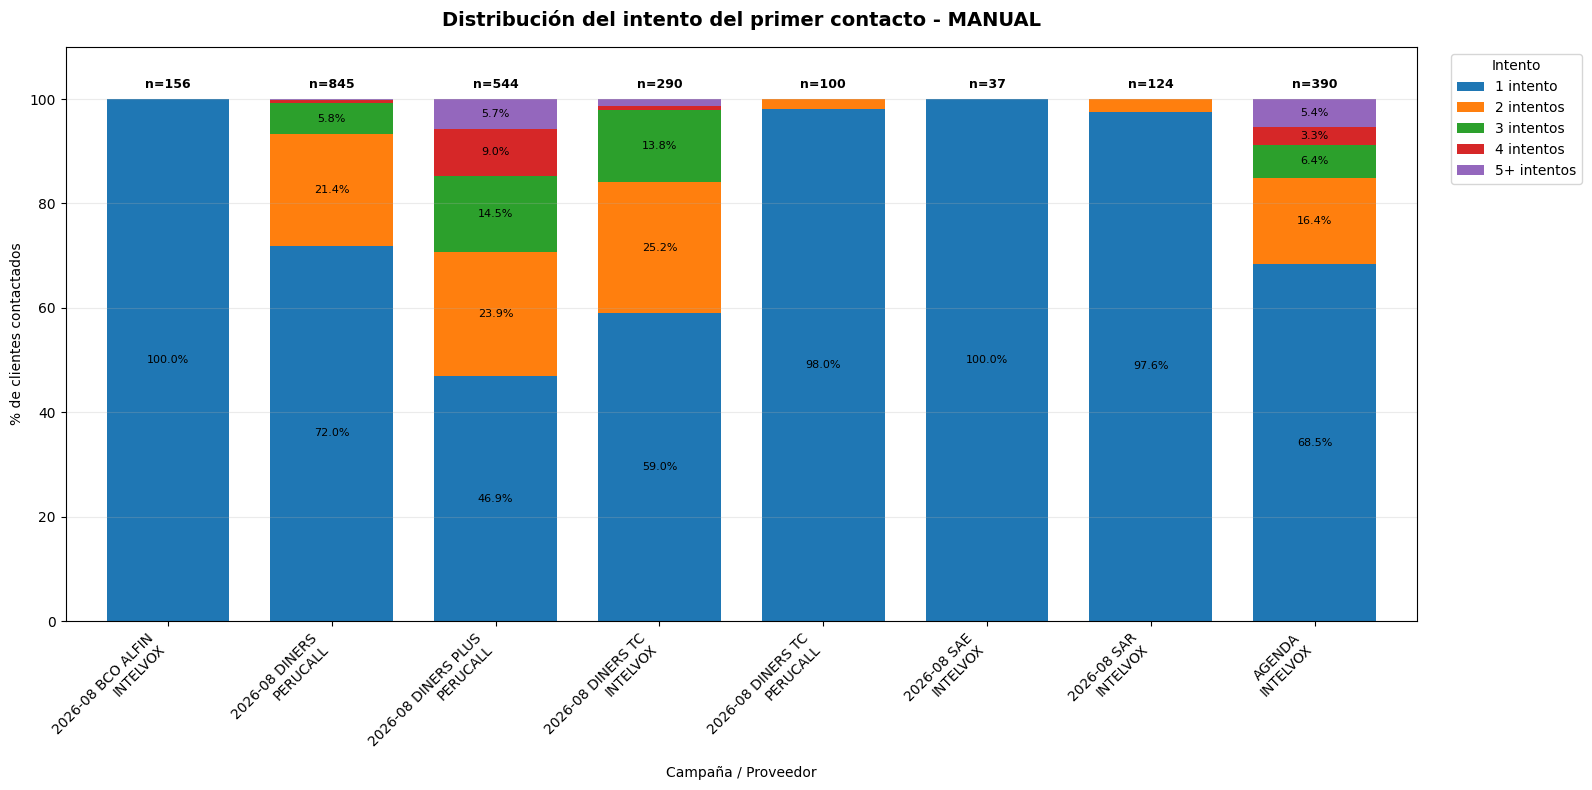

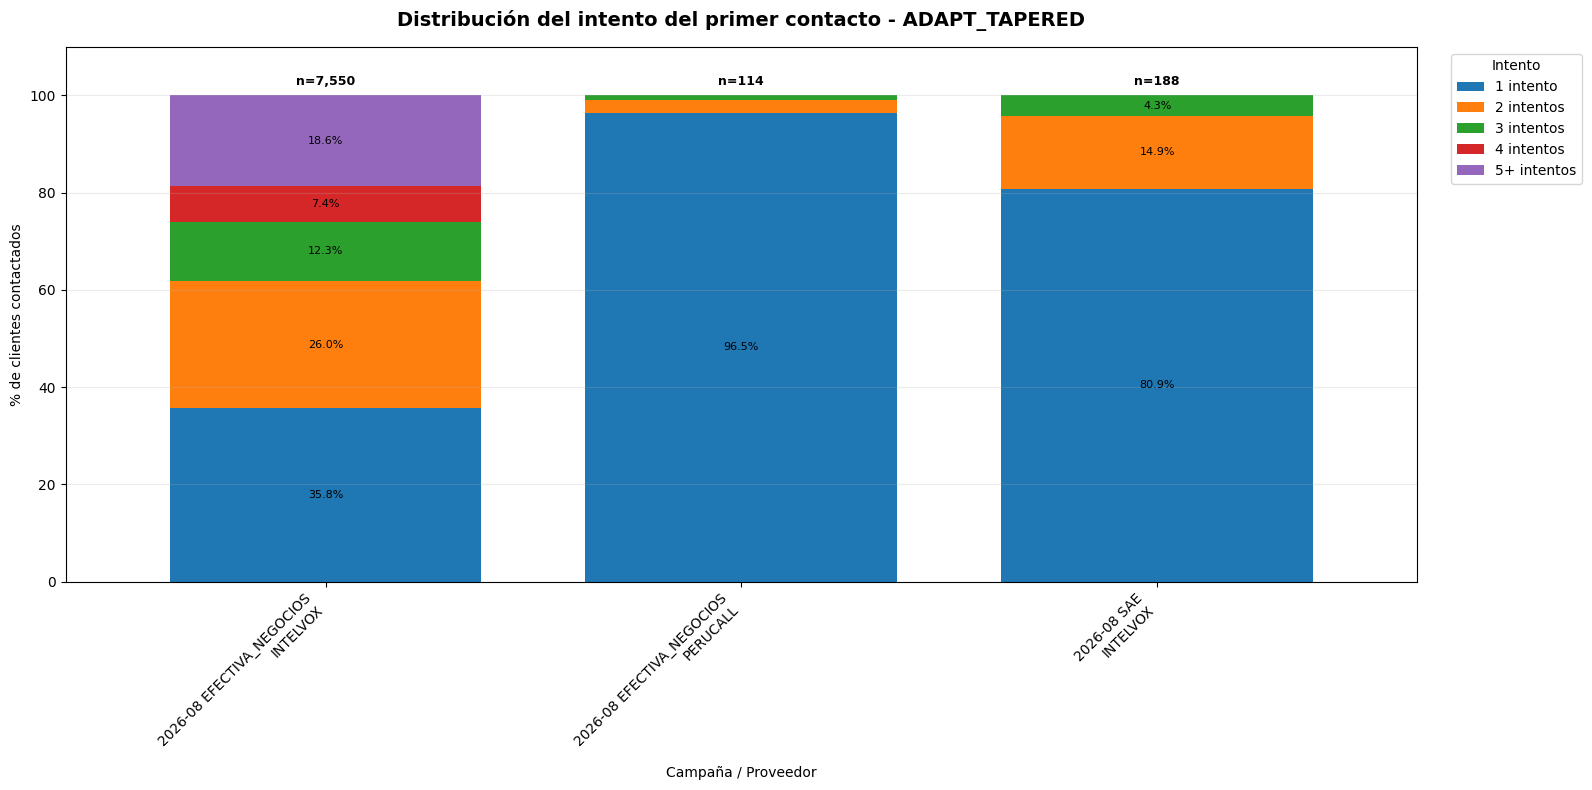

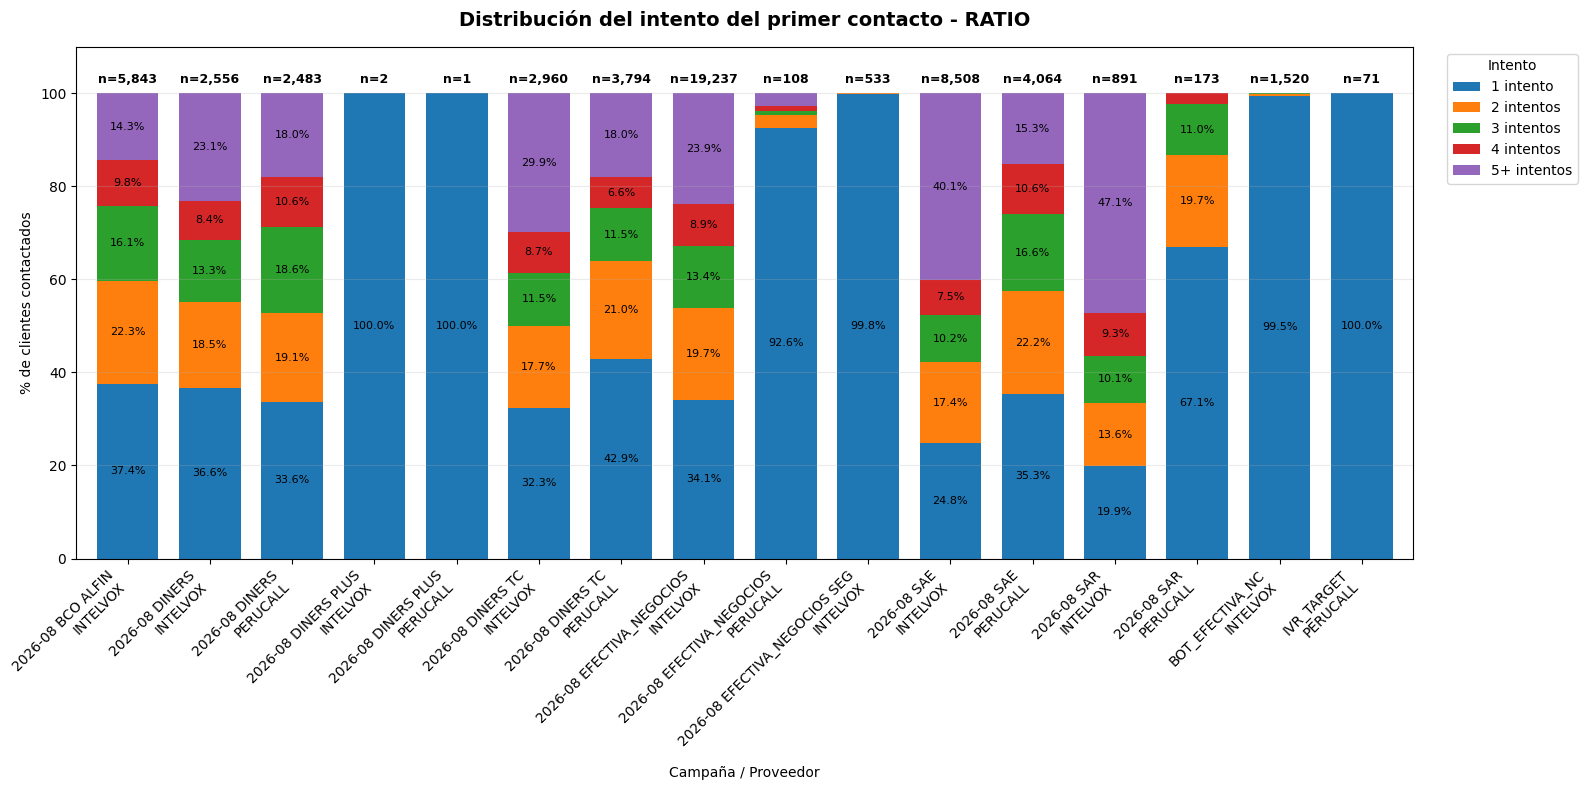

In [40]:
# ============================================================
# 15. ORDEN DE LOS INTENTOS
# ============================================================

orden_intentos = [
    "1 intento",
    "2 intentos",
    "3 intentos",
    "4 intentos",
    "5+ intentos"
]


# ============================================================
# 16. ORDEN DE DIAL METHOD
# ============================================================

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]


# ============================================================
# 17. GRÁFICO POR DIAL METHOD HISTÓRICO
# ============================================================

for metodo in orden_dial:

    # ========================================================
    # FILTRAR MÉTODO
    # ========================================================

    df_grafico = distribucion_intentos[
        distribucion_intentos["dial_method_historico"] == metodo
    ].copy()

    if df_grafico.empty:
        continue


    # ========================================================
    # PIVOT DE PORCENTAJES
    # ========================================================

    pivot = (
        df_grafico
        .pivot_table(
            index=[
                "nombre_campana",
                "proveedor"
            ],
            columns="rango_intento",
            values="porcentaje",
            aggfunc="sum",
            fill_value=0
        )
    )


    # ========================================================
    # ORDENAR COLUMNAS
    # ========================================================

    pivot = pivot.reindex(
        columns=orden_intentos,
        fill_value=0
    )


    # ========================================================
    # TOTAL DE CLIENTES CONTACTADOS POR BARRA
    #
    # No sumamos total_clientes porque está repetido
    # por cada rango.
    #
    # Usamos max() porque el total es el mismo en cada rango.
    # ========================================================

    total_clientes = (
        df_grafico
        .groupby(
            [
                "nombre_campana",
                "proveedor"
            ]
        )["total_clientes"]
        .max()
        .reindex(pivot.index)
    )


    # ========================================================
    # GRÁFICO
    # ========================================================

    ax = pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(16, 8),
        width=0.75
    )


    # ========================================================
    # PORCENTAJES DENTRO DE LAS BARRAS
    # ========================================================

    for container in ax.containers:

        labels = [

            f"{v:.1f}%"

            if v >= 3

            else ""

            for v in container.datavalues
        ]


        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=8
        )


    # ========================================================
    # TOTAL DE CLIENTES ARRIBA
    # ========================================================

    for i, total in enumerate(total_clientes):

        if pd.notna(total):

            ax.text(
                i,
                101.5,
                f"n={int(total):,}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )


    # ========================================================
    # ETIQUETAS
    # ========================================================

    etiquetas = [

        f"{campana}\n{proveedor}"

        for campana, proveedor in pivot.index
    ]


    ax.set_xticklabels(
        etiquetas,
        rotation=45,
        ha="right"
    )


    # ========================================================
    # TÍTULO
    # ========================================================

    ax.set_title(
        f"Distribución del intento del primer contacto - {metodo}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )


    ax.set_xlabel(
        "Campaña / Proveedor"
    )


    ax.set_ylabel(
        "% de clientes contactados"
    )


    # ========================================================
    # EJE
    # ========================================================

    ax.set_ylim(
        0,
        110
    )


    # ========================================================
    # LEYENDA
    # ========================================================

    ax.legend(
        title="Intento",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )


    # ========================================================
    # GRILLA
    # ========================================================

    ax.grid(
        axis="y",
        alpha=0.25
    )


    plt.tight_layout()

    plt.show()

### Embudo

In [41]:
import pandas as pd
import numpy as np


# ============================================================
# 1. COPIA
# ============================================================

df_embudo = df_total_mes_02.copy()


# ============================================================
# 2. NORMALIZAR CAMPOS
# ============================================================

columnas_texto = [
    "nombre_campana",
    "dial_method_historico",
    "proveedor",
    "tipo_contacto"
]

for col in columnas_texto:

    df_embudo[col] = (
        df_embudo[col]
        .astype("string")
        .str.strip()
    )


df_embudo["dial_method_historico"] = (
    df_embudo["dial_method_historico"]
    .str.upper()
)

df_embudo["proveedor"] = (
    df_embudo["proveedor"]
    .str.upper()
)

df_embudo["tipo_contacto"] = (
    df_embudo["tipo_contacto"]
    .str.upper()
)


# ============================================================
# 3. SIP NUMÉRICO
# ============================================================

df_embudo["sip_hangup_cause"] = pd.to_numeric(
    df_embudo["sip_hangup_cause"],
    errors="coerce"
)


# ============================================================
# 4. INDICADORES
# ============================================================

# SIP 200
df_embudo["es_sip_200"] = (
    df_embudo["sip_hangup_cause"] == 200
).astype(int)


# CONTACTO
df_embudo["es_contacto"] = (
    df_embudo["tipo_contacto"] == "CONTACTO"
).astype(int)


# NO CONTACTO
df_embudo["es_no_contacto"] = (
    df_embudo["tipo_contacto"] == "NO CONTACTO"
).astype(int)


# SIP 200 PERO NO CONTACTO
df_embudo["sip200_no_contacto"] = (
    (df_embudo["sip_hangup_cause"] == 200)
    &
    (df_embudo["tipo_contacto"] == "NO CONTACTO")
).astype(int)


# ============================================================
# 5. RESUMEN
# ============================================================

embudo = (
    df_embudo
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )
    .agg(

        llamadas=(
            "lead_id",
            "size"
        ),

        clientes_unicos=(
            "vendor_lead_code",
            "nunique"
        ),

        sip_200=(
            "es_sip_200",
            "sum"
        ),

        contactos=(
            "es_contacto",
            "sum"
        ),

        no_contactos=(
            "es_no_contacto",
            "sum"
        ),

        sip200_no_contacto=(
            "sip200_no_contacto",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 6. % SIP 200
# ============================================================

embudo["pct_sip_200"] = np.where(

    embudo["llamadas"] > 0,

    embudo["sip_200"]
    / embudo["llamadas"]
    * 100,

    np.nan
)


# ============================================================
# 7. % CONTACTO SOBRE TOTAL LLAMADAS
# ============================================================

embudo["pct_contacto"] = np.where(

    embudo["llamadas"] > 0,

    embudo["contactos"]
    / embudo["llamadas"]
    * 100,

    np.nan
)


# ============================================================
# 8. % CONTACTO SOBRE LAS LLAMADAS SIP 200
# ============================================================

embudo["pct_contacto_sobre_sip200"] = np.where(

    embudo["sip_200"] > 0,

    embudo["contactos"]
    / embudo["sip_200"]
    * 100,

    np.nan
)


# ============================================================
# 9. % SIP 200 QUE TERMINÓ EN NO CONTACTO
# ============================================================

embudo["pct_sip200_no_contacto"] = np.where(

    embudo["sip_200"] > 0,

    embudo["sip200_no_contacto"]
    / embudo["sip_200"]
    * 100,

    np.nan
)


# ============================================================
# 10. CRUZAR CON RESUMEN DE INTENTOS
# ============================================================

embudo_final = embudo.merge(

    resumen_intentos[
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",

            "clientes_contactados",
            "promedio_intentos",
            "mediana_intentos"
        ]
    ],

    on=[
        "nombre_campana",
        "dial_method_historico",
        "proveedor"
    ],

    how="left"
)


# ============================================================
# 11. % DE CLIENTES QUE LOGRARON SER CONTACTADOS
# ============================================================

embudo_final["pct_clientes_contactados"] = np.where(

    embudo_final["clientes_unicos"] > 0,

    embudo_final["clientes_contactados"]
    / embudo_final["clientes_unicos"]
    * 100,

    np.nan
)


# ============================================================
# 12. RESULTADO FINAL
# ============================================================

resultado_final = embudo_final[
    [
        "nombre_campana",
        "dial_method_historico",
        "proveedor",

        "llamadas",
        "clientes_unicos",

        "sip_200",
        "pct_sip_200",

        "contactos",
        "pct_contacto",

        "pct_contacto_sobre_sip200",

        "sip200_no_contacto",
        "pct_sip200_no_contacto",

        "clientes_contactados",
        "pct_clientes_contactados",

        "promedio_intentos",
        "mediana_intentos"
    ]
].copy()


# ============================================================
# 13. ORDENAR
# ============================================================

resultado_final = (
    resultado_final
    .sort_values(
        [
            "dial_method_historico",
            "nombre_campana",
            "proveedor"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 14. MOSTRAR
# ============================================================

resultado_final.round(2)

,nombre_campana,dial_method_historico,proveedor,llamadas,clientes_unicos,sip_200,pct_sip_200,contactos,pct_contacto,pct_contacto_sobre_sip200,sip200_no_contacto,pct_sip200_no_contacto,clientes_contactados,pct_clientes_contactados,promedio_intentos,mediana_intentos
0,2026-08 EFECTIVA_NEGOCIOS,ADAPT_TAPERED,INTELVOX,134963,30796,76567,56.73,8467,6.27,11.06,68158,89.02,7550.0,24.52,3.26,2.0
1,2026-08 EFECTIVA_NEGOCIOS,ADAPT_TAPERED,PERUCALL,234,159,134,57.26,162,69.23,120.90,28,20.90,114.0,71.70,1.04,1.0
2,2026-08 SAE,ADAPT_TAPERED,INTELVOX,6396,4817,5684,88.87,191,2.99,3.36,5499,96.75,188.0,3.90,1.23,1.0
3,2026-08 BCO ALFIN,MANUAL,INTELVOX,528,525,221,41.86,158,29.92,71.49,113,51.13,156.0,29.71,1.00,1.0
4,2026-08 DINERS,MANUAL,INTELVOX,20,20,19,95.00,0,0.00,0.00,19,100.00,NaN,NaN,NaN,NaN
5,2026-08 DINERS,MANUAL,PERUCALL,5837,3180,3337,57.17,1150,19.70,34.46,2288,68.56,845.0,26.57,1.36,1.0
6,2026-08 DINERS PLUS,MANUAL,INTELVOX,4,4,4,100.00,0,0.00,0.00,4,100.00,NaN,NaN,NaN,NaN
7,2026-08 DINERS PLUS,MANUAL,PERUCALL,5446,1260,3181,58.41,1493,27.41,46.93,1915,60.20,544.0,43.17,2.10,2.0
8,2026-08 DINERS TC,MANUAL,INTELVOX,2104,921,1310,62.26,435,20.67,33.21,920,70.23,290.0,31.49,1.62,1.0
9,2026-08 DINERS TC,MANUAL,PERUCALL,355,341,269,75.77,109,30.70,40.52,174,64.68,100.0,29.33,1.02,1.0


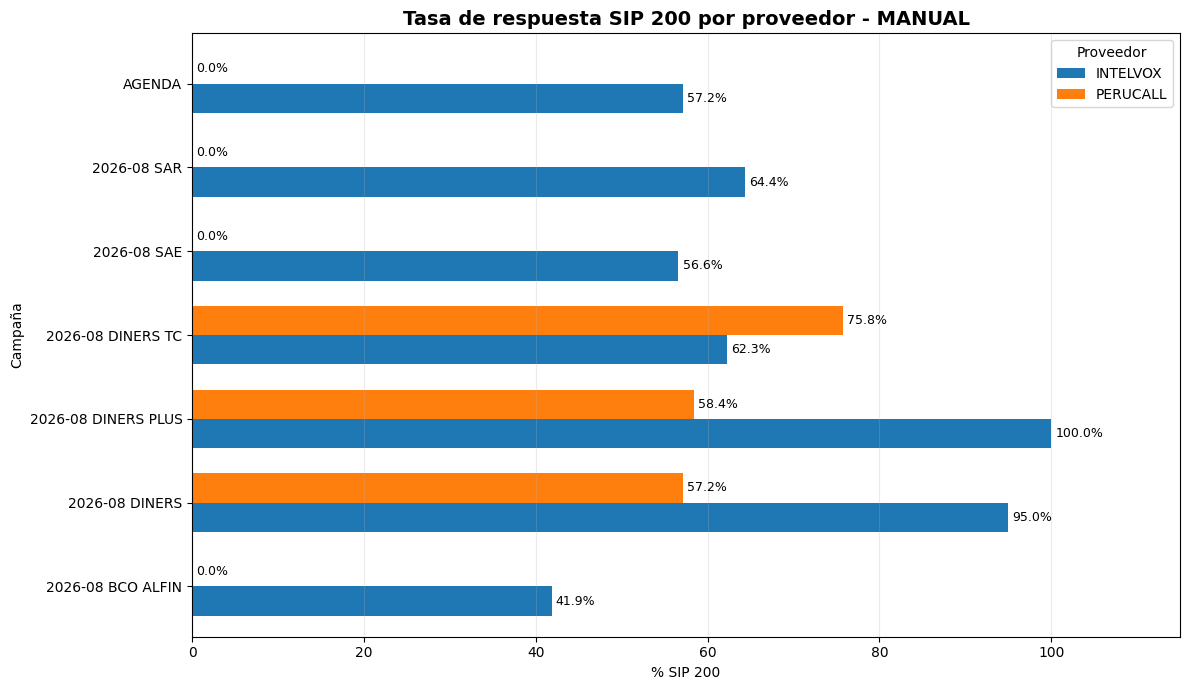

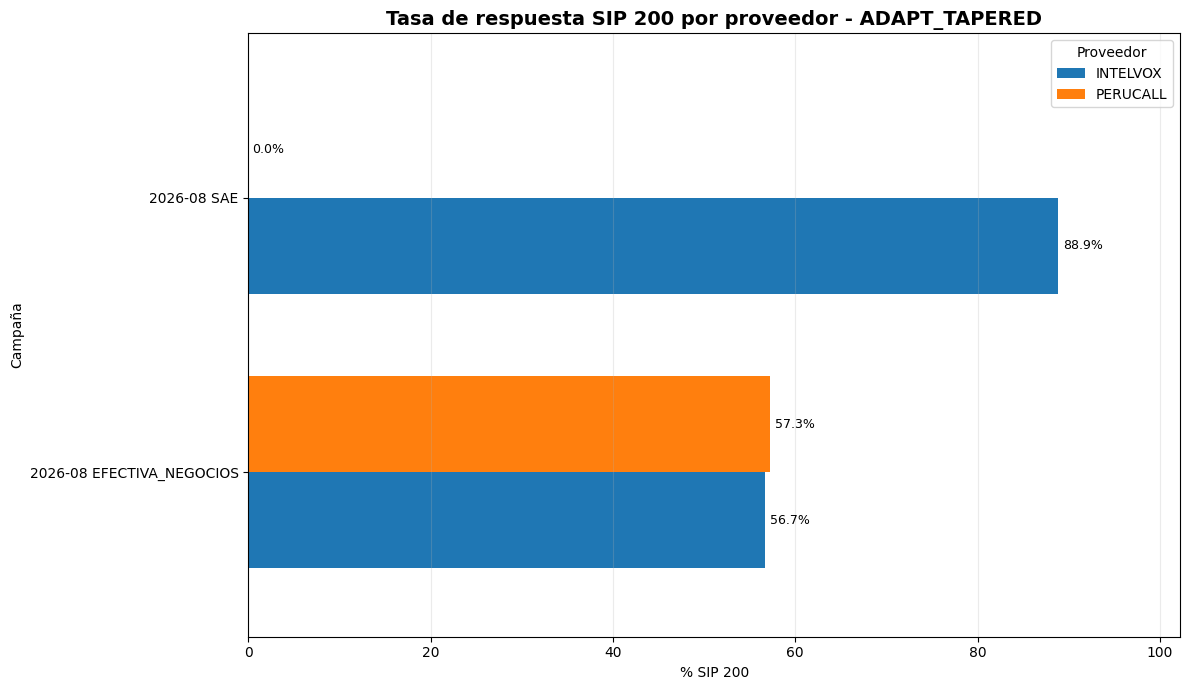

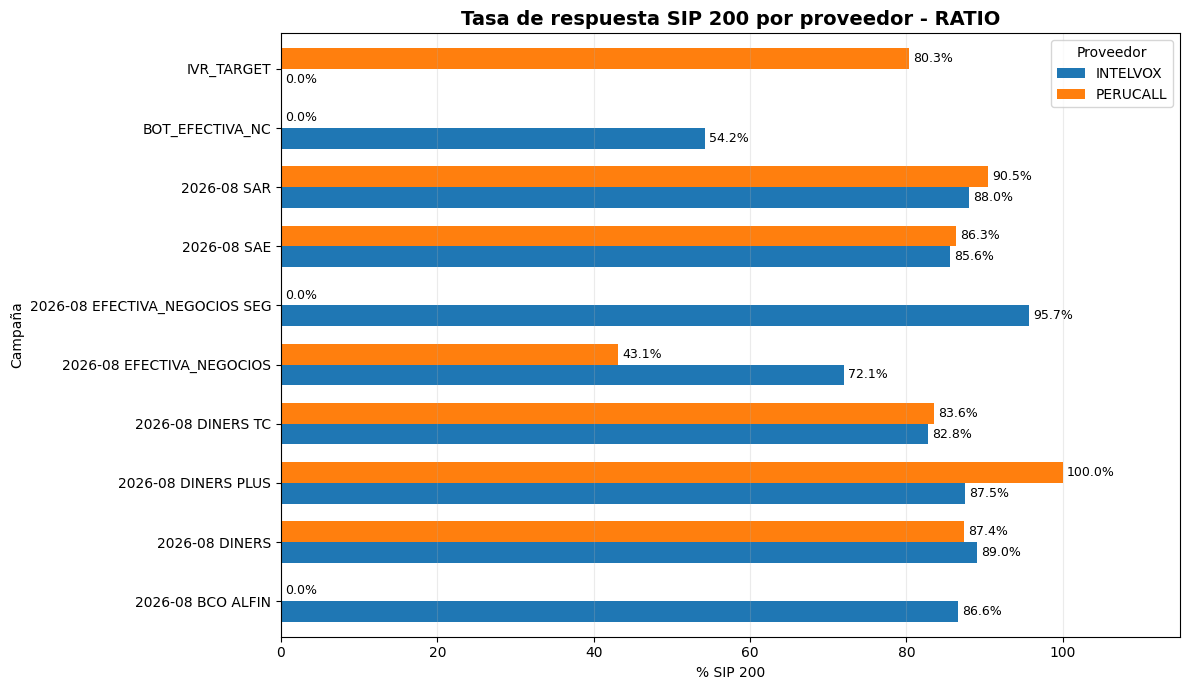

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

orden_dial = [
    "MANUAL",
    "ADAPT_TAPERED",
    "RATIO"
]

for metodo in orden_dial:

    df_plot = resultado_final[
        resultado_final["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    pivot = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="pct_sip_200",
        aggfunc="mean"
    )

    proveedores = [
        p for p in ["INTELVOX", "PERUCALL"]
        if p in pivot.columns
    ]

    pivot = pivot[proveedores]

    ax = pivot.plot(
        kind="barh",
        figsize=(12, 7),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%" if pd.notna(v) else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"Tasa de respuesta SIP 200 por proveedor - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("% SIP 200")
    ax.set_ylabel("Campaña")

    ax.set_xlim(
        0,
        max(100, pivot.max().max() * 1.15)
    )

    ax.legend(title="Proveedor")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

In [43]:
validacion_sip = resultado_final[
    [
        "nombre_campana",
        "dial_method_historico",
        "proveedor",
        "llamadas",
        "sip_200",
        "pct_sip_200"
    ]
].copy()

validacion_sip["pct_sip_200_recalculado"] = (
    validacion_sip["sip_200"]
    / validacion_sip["llamadas"]
    * 100
)

validacion_sip["diferencia"] = (
    validacion_sip["pct_sip_200"]
    - validacion_sip["pct_sip_200_recalculado"]
)

validacion_sip.round(2)

,nombre_campana,dial_method_historico,proveedor,llamadas,sip_200,pct_sip_200,pct_sip_200_recalculado,diferencia
0,2026-08 EFECTIVA_NEGOCIOS,ADAPT_TAPERED,INTELVOX,134963,76567,56.73,56.73,0.0
1,2026-08 EFECTIVA_NEGOCIOS,ADAPT_TAPERED,PERUCALL,234,134,57.26,57.26,0.0
2,2026-08 SAE,ADAPT_TAPERED,INTELVOX,6396,5684,88.87,88.87,0.0
3,2026-08 BCO ALFIN,MANUAL,INTELVOX,528,221,41.86,41.86,0.0
4,2026-08 DINERS,MANUAL,INTELVOX,20,19,95.00,95.00,0.0
5,2026-08 DINERS,MANUAL,PERUCALL,5837,3337,57.17,57.17,0.0
6,2026-08 DINERS PLUS,MANUAL,INTELVOX,4,4,100.00,100.00,0.0
7,2026-08 DINERS PLUS,MANUAL,PERUCALL,5446,3181,58.41,58.41,0.0
8,2026-08 DINERS TC,MANUAL,INTELVOX,2104,1310,62.26,62.26,0.0
9,2026-08 DINERS TC,MANUAL,PERUCALL,355,269,75.77,75.77,0.0


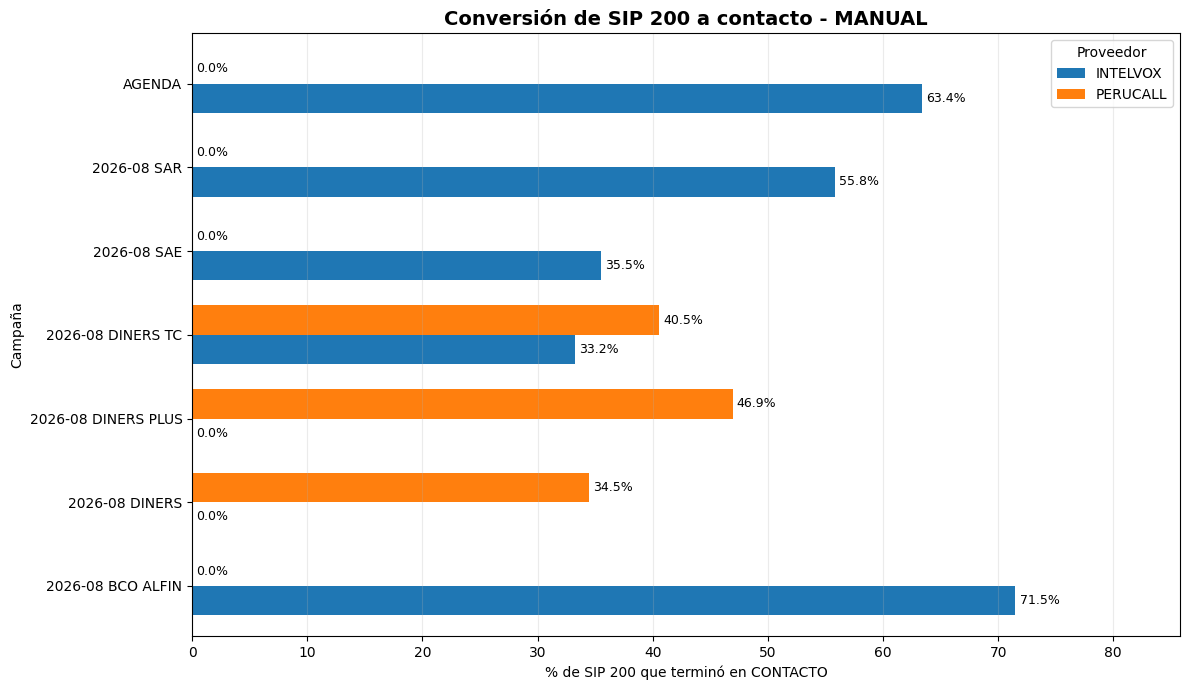

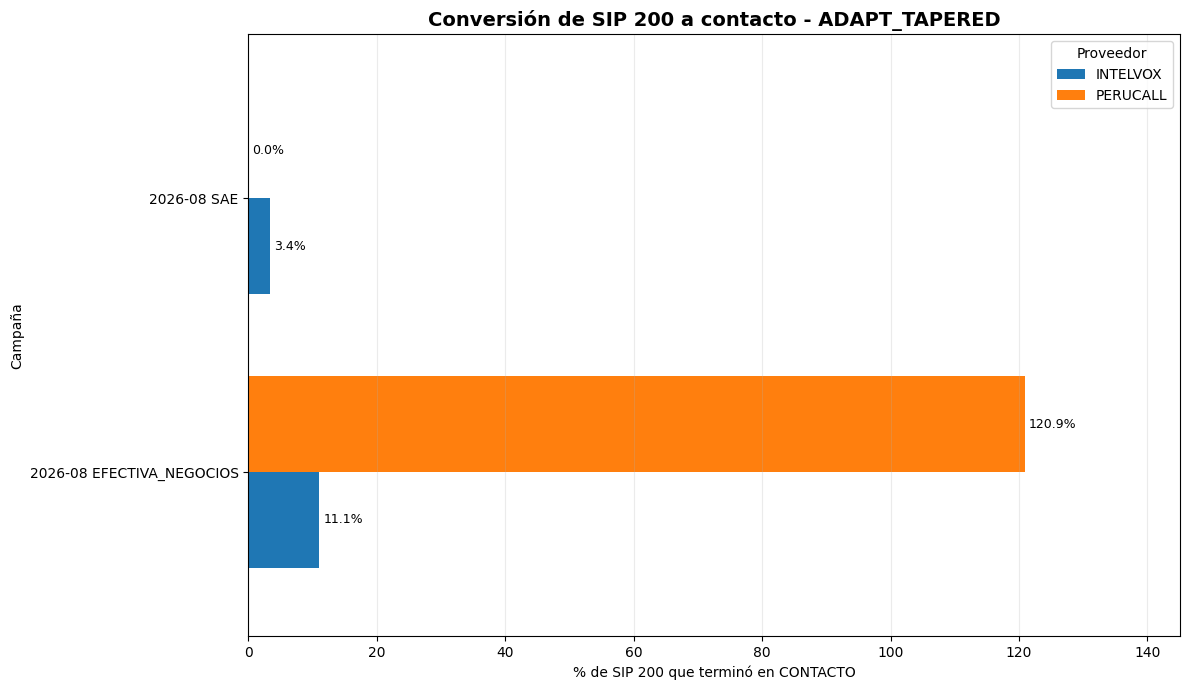

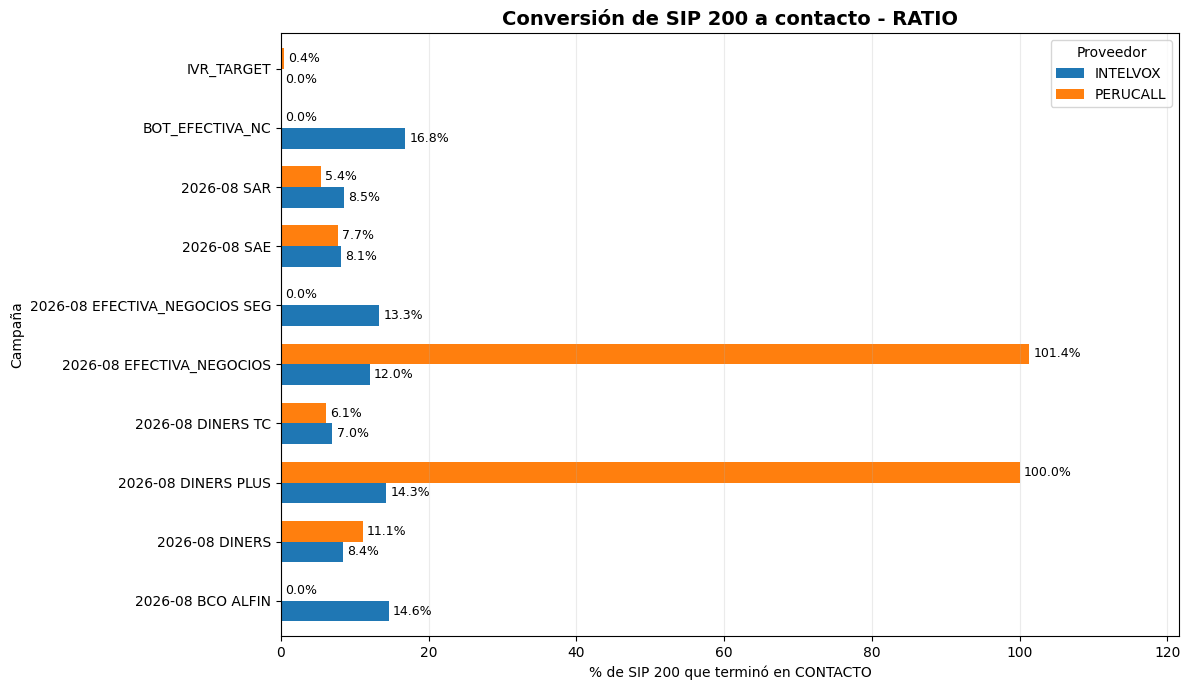

In [44]:
for metodo in orden_dial:

    df_plot = resultado_final[
        resultado_final["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    pivot = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="pct_contacto_sobre_sip200",
        aggfunc="mean"
    )

    proveedores = [
        p for p in ["INTELVOX", "PERUCALL"]
        if p in pivot.columns
    ]

    pivot = pivot[proveedores]

    ax = pivot.plot(
        kind="barh",
        figsize=(12, 7),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%" if pd.notna(v) else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"Conversión de SIP 200 a contacto - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("% de SIP 200 que terminó en CONTACTO")
    ax.set_ylabel("Campaña")

    maximo = pivot.max().max()

    if pd.notna(maximo):
        ax.set_xlim(0, maximo * 1.20)

    ax.legend(title="Proveedor")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

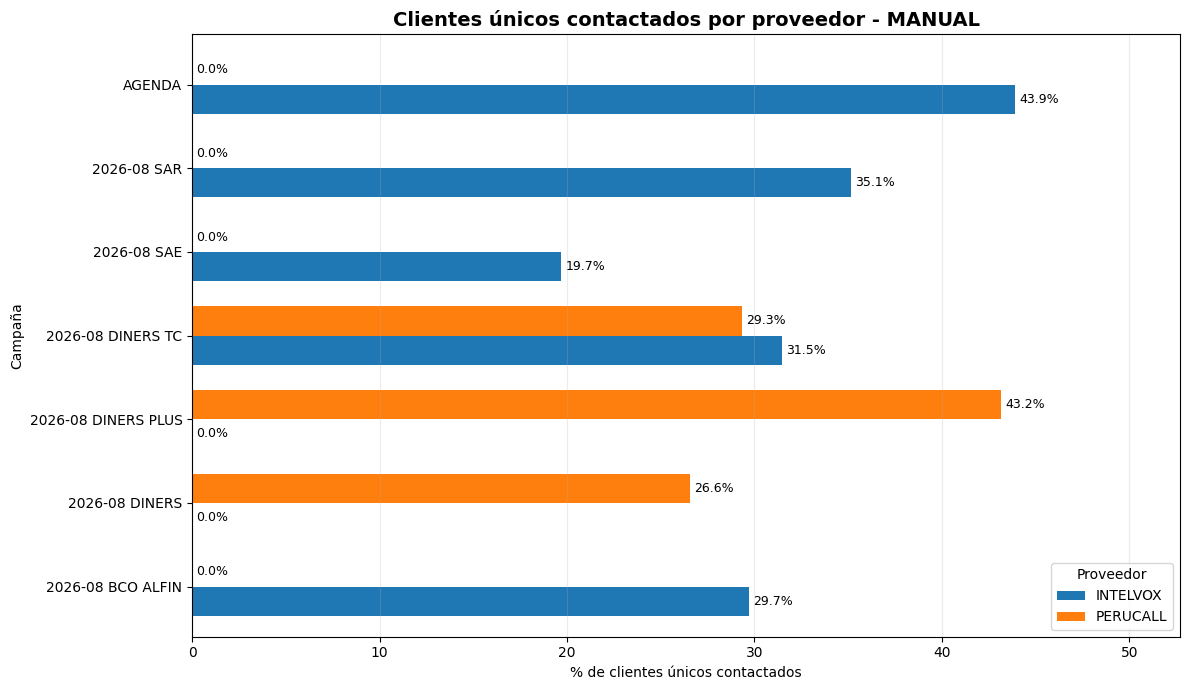

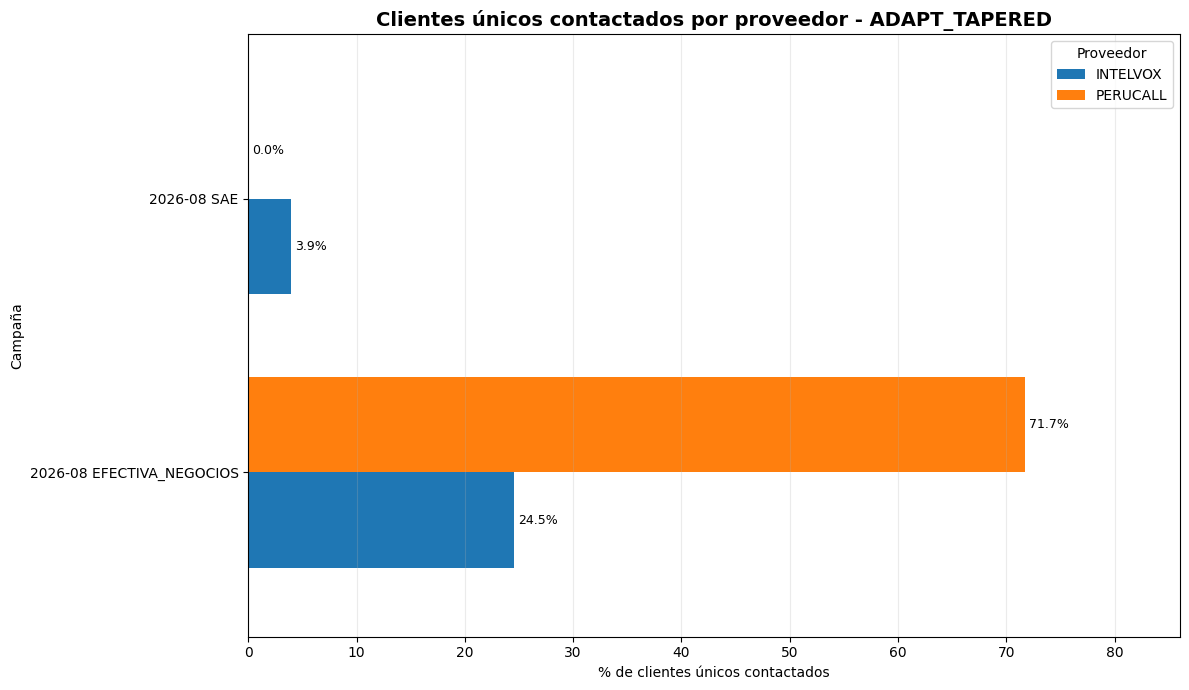

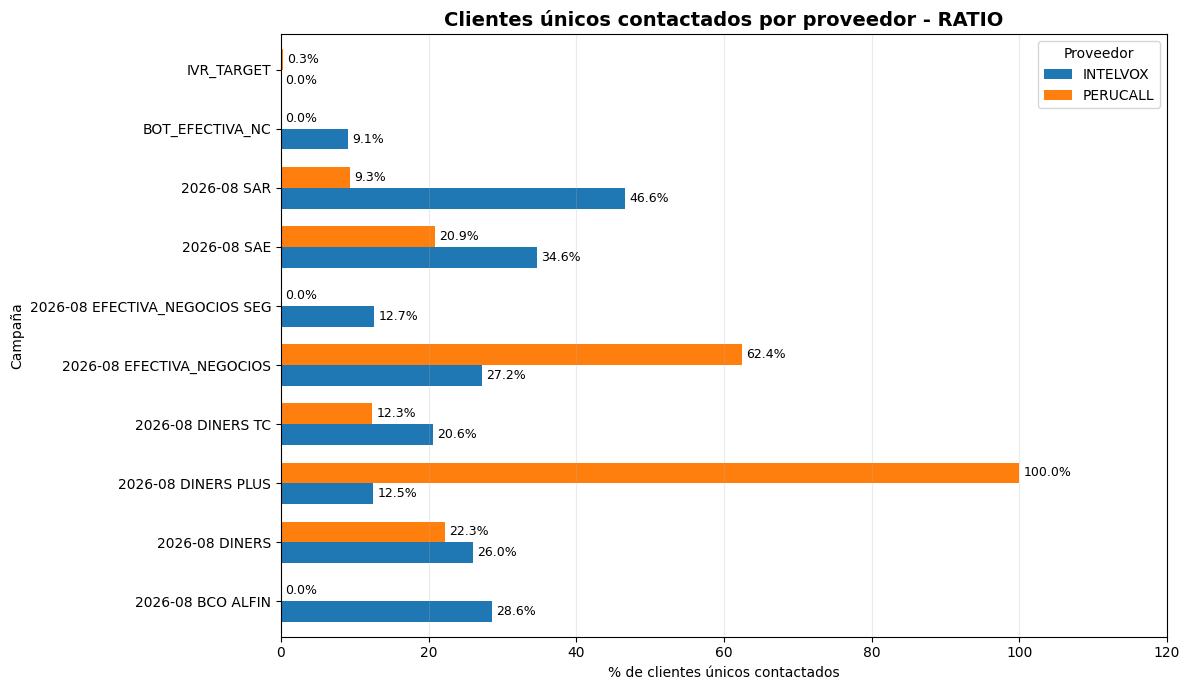

In [46]:
for metodo in orden_dial:

    df_plot = resultado_final[
        resultado_final["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    pivot = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="pct_clientes_contactados",
        aggfunc="mean"
    )

    proveedores = [
        p for p in ["INTELVOX", "PERUCALL"]
        if p in pivot.columns
    ]

    pivot = pivot[proveedores]

    ax = pivot.plot(
        kind="barh",
        figsize=(12, 7),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%" if pd.notna(v) else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"Clientes únicos contactados por proveedor - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("% de clientes únicos contactados")
    ax.set_ylabel("Campaña")

    maximo = pivot.max().max()

    if pd.notna(maximo):
        ax.set_xlim(0, maximo * 1.20)

    ax.legend(title="Proveedor")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

In [45]:
embudo["pct_contacto_sobre_sip200"] = (
    embudo["contactos"]
    / embudo["sip_200"]
    * 100
)

In [34]:
for metodo in orden_dial:

    df_plot = resultado_final[
        resultado_final["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    pivot = df_plot.pivot_table(
        index="nombre_campana",
        columns="proveedor",
        values="pct_sip200_no_contacto",
        aggfunc="mean"
    )

    proveedores = [
        p for p in ["INTELVOX", "PERUCALL"]
        if p in pivot.columns
    ]

    pivot = pivot[proveedores]

    ax = pivot.plot(
        kind="barh",
        figsize=(12, 7),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%" if pd.notna(v) else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"SIP 200 que terminó en NO CONTACTO - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("% SIP 200 sin contacto")
    ax.set_ylabel("Campaña")

    maximo = pivot.max().max()

    if pd.notna(maximo):
        ax.set_xlim(0, maximo * 1.20)

    ax.legend(title="Proveedor")
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

NameError: name 'resultado_final' is not defined

In [35]:
resumen_proveedor = (
    embudo_final
    .groupby(
        [
            "dial_method_historico",
            "proveedor"
        ],
        dropna=False
    )
    .agg(
        llamadas=("llamadas", "sum"),
        sip_200=("sip_200", "sum"),
        contactos=("contactos", "sum"),
        sip200_no_contacto=("sip200_no_contacto", "sum"),
        clientes_unicos=("clientes_unicos", "sum"),
        clientes_contactados=("clientes_contactados", "sum")
    )
    .reset_index()
)


# ============================================================
# INDICADORES
# ============================================================

resumen_proveedor["pct_sip_200"] = (
    resumen_proveedor["sip_200"]
    / resumen_proveedor["llamadas"]
    * 100
)

resumen_proveedor["pct_contacto"] = (
    resumen_proveedor["contactos"]
    / resumen_proveedor["llamadas"]
    * 100
)

resumen_proveedor["pct_contacto_sobre_sip200"] = (
    resumen_proveedor["contactos"]
    / resumen_proveedor["sip_200"]
    * 100
)

resumen_proveedor["pct_sip200_no_contacto"] = (
    resumen_proveedor["sip200_no_contacto"]
    / resumen_proveedor["sip_200"]
    * 100
)

resumen_proveedor["pct_clientes_contactados"] = (
    resumen_proveedor["clientes_contactados"]
    / resumen_proveedor["clientes_unicos"]
    * 100
)

resumen_proveedor.round(2)

NameError: name 'embudo_final' is not defined

In [36]:
for metodo in orden_dial:

    df_plot = resumen_proveedor[
        resumen_proveedor["dial_method_historico"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    grafico = (
        df_plot
        .set_index("proveedor")
        [
            [
                "pct_sip_200",
                "pct_contacto_sobre_sip200",
                "pct_clientes_contactados"
            ]
        ]
        .rename(
            columns={
                "pct_sip_200": "SIP 200",
                "pct_contacto_sobre_sip200": "SIP 200 → Contacto",
                "pct_clientes_contactados": "Clientes contactados"
            }
        )
        .T
    )

    ax = grafico.plot(
        kind="bar",
        figsize=(11, 6),
        width=0.7
    )

    for container in ax.containers:

        labels = [
            f"{v:.1f}%"
            if pd.notna(v)
            else ""
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_title(
        f"Embudo comparativo de proveedores - {metodo}",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Porcentaje (%)")

    ax.set_ylim(0, 110)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=0
    )

    ax.legend(
        title="Proveedor"
    )

    ax.grid(
        axis="y",
        alpha=0.20
    )

    plt.tight_layout()
    plt.show()

NameError: name 'resumen_proveedor' is not defined

In [98]:

ruta_archivo = os.path.join(ruta_csv, 'vicidial_.csv')
resultado_final.to_csv(ruta_archivo, sep=';')

In [58]:
df_total_mes_02["outbound_cid_original"] = (
    df_total_mes_02["outbound_cid"]
    .astype("string")
    .str.strip()
)


# ============================================================
# PARTE ENTRE COMILLAS
# Ejemplo:
# "M8010859280006884036"
# ============================================================

df_total_mes_02["caller_name"] = (
    df_total_mes_02["outbound_cid_original"]
    .str.extract(
        r'"([^"]+)"',
        expand=False
    )
)


# ============================================================
# PARTE ENTRE < >
# Ejemplo:
# <0000000000>
# ============================================================

df_total_mes_02["caller_number"] = (
    df_total_mes_02["outbound_cid_original"]
    .str.extract(
        r'<([^>]+)>',
        expand=False
    )
    .str.strip()
)

In [59]:
df_total_mes_02[
    [
        "proveedor",
        "outbound_cid_original",
        "caller_name",
        "caller_number",
        "tipo_contacto"
    ]
].head(20)

,proveedor,outbound_cid_original,caller_name,caller_number,tipo_contacto
0,INTELVOX,"""M8010859280006884036"" <0000000000>",M8010859280006884036,0000000000,NO CONTACTO
1,INTELVOX,"""M8010904400006884224"" <0000000000>",M8010904400006884224,0000000000,NO CONTACTO
2,INTELVOX,"""M8010910530006884216"" <0000000000>",M8010910530006884216,0000000000,NO CONTACTO
3,INTELVOX,"""M8010912020006884258"" <0000000000>",M8010912020006884258,0000000000,CONTACTO
4,INTELVOX,"""M8010913230006884197"" <0000000000>",M8010913230006884197,0000000000,NO CONTACTO
5,INTELVOX,"""M8010914170006884044"" <0000000000>",M8010914170006884044,0000000000,NO CONTACTO
6,INTELVOX,"""M8010914310006883996"" <0000000000>",M8010914310006883996,0000000000,CONTACTO
7,INTELVOX,"""M8010916100002199291"" <0000000000>",M8010916100002199291,0000000000,NO CONTACTO
8,INTELVOX,"""M8010915550006883980"" <0000000000>",M8010915550006883980,0000000000,CONTACTO
9,INTELVOX,"""M8010921000006884122"" <0000000000>",M8010921000006884122,0000000000,NO CONTACTO


In [60]:
# ============================================================
# VALIDAR CAMPOS RELACIONADOS CON LA SALIDA DE LA LLAMADA
# ============================================================

validar_caller = df_total_mes_02[
    [
        "fecha_hora_llamada",
        "proveedor",
        "nombre_campana",
        "extension",
        "channel",
        "context",
        "caller_code",
        "outbound_cid",
        "phone_number"
    ]
].copy()

validar_caller.head(50)

,fecha_hora_llamada,proveedor,nombre_campana,extension,channel,context,caller_code,outbound_cid,phone_number
0,2026-08-01 09:00:01,INTELVOX,AGENDA,899959194586,Local/8600056@default,default,M8010859280006884036,"""M8010859280006884036"" <0000000000>",959194586
1,2026-08-01 09:04:44,INTELVOX,AGENDA,899998494144,Local/8600056@default,default,M8010904400006884224,"""M8010904400006884224"" <0000000000>",998494144
2,2026-08-01 09:11:51,INTELVOX,AGENDA,899994829679,Local/8600056@default,default,M8010910530006884216,"""M8010910530006884216"" <0000000000>",994829679
3,2026-08-01 09:12:14,INTELVOX,AGENDA,899993647035,Local/8600056@default,default,M8010912020006884258,"""M8010912020006884258"" <0000000000>",993647035
4,2026-08-01 09:13:25,INTELVOX,AGENDA,899902544694,Local/8600056@default,default,M8010913230006884197,"""M8010913230006884197"" <0000000000>",902544694
5,2026-08-01 09:14:23,INTELVOX,AGENDA,899943553982,Local/8600056@default,default,M8010914170006884044,"""M8010914170006884044"" <0000000000>",943553982
6,2026-08-01 09:14:49,INTELVOX,AGENDA,899963075660,Local/8600056@default,default,M8010914310006883996,"""M8010914310006883996"" <0000000000>",963075660
7,2026-08-01 09:16:12,INTELVOX,AGENDA,899999369786,Local/8600053@default,default,M8010916100002199291,"""M8010916100002199291"" <0000000000>",999369786
8,2026-08-01 09:16:16,INTELVOX,AGENDA,899994614690,Local/8600056@default,default,M8010915550006883980,"""M8010915550006883980"" <0000000000>",994614690
9,2026-08-01 09:21:34,INTELVOX,AGENDA,899952264714,Local/8600056@default,default,M8010921000006884122,"""M8010921000006884122"" <0000000000>",952264714


In [64]:
query_caller = """
SELECT *
FROM OPENQUERY([192.168.3.21], '
    SELECT
        TABLE_NAME,
        COLUMN_NAME,
        DATA_TYPE

    FROM INFORMATION_SCHEMA.COLUMNS

    WHERE TABLE_SCHEMA = ''asterisk''

    AND (
           COLUMN_NAME LIKE ''%cid%''
        OR COLUMN_NAME LIKE ''%caller%''
        OR COLUMN_NAME LIKE ''%outbound%''
    )

    ORDER BY
        TABLE_NAME,
        ORDINAL_POSITION
')
"""

df_caller = pd.read_sql(
    query_caller,
    engine_zeus
)

df_caller

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,call_log,caller_code,varchar
1,call_log_archive,caller_code,varchar
2,cid_channels_recent,caller_id_name,varchar
3,cid_channels_recent_192168003021,caller_id_name,varchar
4,gateway_recording_log,caller_id_number,varchar
...,...,...,...
203,vicidial_users2,vicidial_transfers,enum
204,vicidial_users2,vicidial_recording_override,enum
205,vicidial_user_dial_log,caller_code,varchar
206,vicidial_user_dial_log_archive,caller_code,varchar


In [66]:
# ============================================================
# BUSCAR COLUMNAS REALMENTE RELACIONADAS CON CALLER ID
# ============================================================

filtro = (
    df_caller["COLUMN_NAME"]
    .str.lower()
    .str.contains(
        r"caller_id|campaign_cid|custom_cid|outbound_cid|cid_number|cid_num",
        regex=True,
        na=False
    )
)

df_cid = (
    df_caller[filtro]
    .sort_values(
        ["TABLE_NAME", "COLUMN_NAME"]
    )
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", 200)

df_cid

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,cid_channels_recent,caller_id_name,varchar
1,cid_channels_recent_192168003021,caller_id_name,varchar
2,gateway_recording_log,caller_id_name,varchar
3,gateway_recording_log,caller_id_number,varchar
4,groups_alias,caller_id_name,varchar
5,groups_alias,caller_id_number,varchar
6,live_inbound,caller_id,varchar
7,live_inbound_log,caller_id,varchar
8,phones,outbound_cid,varchar
9,phones2,outbound_cid,varchar


In [79]:
query_caller = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT
        COLUMN_NAME,
        DATA_TYPE

    FROM INFORMATION_SCHEMA.COLUMNS

    WHERE TABLE_SCHEMA = ''asterisk''
      AND TABLE_NAME = ''vicidial_dial_cid_log''

    ORDER BY ORDINAL_POSITION
')
"""

df_dial_cid_cols = pd.read_sql(
    query_caller,
    engine_zeus
)

df_dial_cid_cols

,COLUMN_NAME,DATA_TYPE
0,caller_code,varchar
1,call_date,datetime
2,call_type,enum
3,call_alt,varchar
4,outbound_cid,varchar
5,outbound_cid_type,varchar


In [80]:
query_caller = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT *

    FROM asterisk.vicidial_dial_cid_log

    ORDER BY call_date DESC

    LIMIT 100
')
"""

df_dial_cid = pd.read_sql(
    query_caller,
    engine_zeus
)

df_dial_cid

,caller_code,call_date,call_type,call_alt,outbound_cid,outbound_cid_type
0,V8171423440010913935,2026-08-17 14:23:44,OUT,NONE,0000000000,CAMPAIGN_CID
1,V8171423440010913933,2026-08-17 14:23:44,OUT,NONE,0000000000,CAMPAIGN_CID
2,V8171423440010913928,2026-08-17 14:23:44,OUT,NONE,0000000000,CAMPAIGN_CID
3,V8171423440010913926,2026-08-17 14:23:44,OUT,NONE,0000000000,CAMPAIGN_CID
4,V8171423390010913924,2026-08-17 14:23:39,OUT,NONE,0000000000,CAMPAIGN_CID
5,V8171423390010913921,2026-08-17 14:23:39,OUT,NONE,0000000000,CAMPAIGN_CID
6,V8171423340010913917,2026-08-17 14:23:34,OUT,NONE,0000000000,CAMPAIGN_CID
7,V8171423340010913915,2026-08-17 14:23:34,OUT,NONE,0000000000,CAMPAIGN_CID
8,V8171423340010913914,2026-08-17 14:23:34,OUT,NONE,0000000000,CAMPAIGN_CID
9,V8171423240010913911,2026-08-17 14:23:24,OUT,NONE,0000000000,CAMPAIGN_CID


In [86]:
query_trunk = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT
        COLUMN_NAME,
        DATA_TYPE

    FROM INFORMATION_SCHEMA.COLUMNS

    WHERE TABLE_SCHEMA = ''asterisk''
      AND TABLE_NAME = ''vicidial_server_trunks''

    ORDER BY ORDINAL_POSITION
')
"""

df_trunk_cols = pd.read_sql(
    query_trunk,
    engine_zeus
)

pd.set_option("display.max_rows", 200)

df_trunk_cols

,COLUMN_NAME,DATA_TYPE
0,server_ip,varchar
1,campaign_id,varchar
2,dedicated_trunks,smallint
3,trunk_restriction,enum


In [87]:
query_trunk = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT *
    FROM asterisk.vicidial_server_trunks

')
"""

df_trunks = pd.read_sql(
    query_trunk,
    engine_zeus
)

df_trunks

,server_ip,campaign_id,dedicated_trunks,trunk_restriction


In [88]:
query_carrier = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT
        COLUMN_NAME,
        DATA_TYPE

    FROM INFORMATION_SCHEMA.COLUMNS

    WHERE TABLE_SCHEMA = ''asterisk''
      AND TABLE_NAME = ''vicidial_server_carriers''

    ORDER BY ORDINAL_POSITION
')
"""

df_carrier_cols = pd.read_sql(
    query_carrier,
    engine_zeus
)

pd.set_option("display.max_rows", 200)

df_carrier_cols

,COLUMN_NAME,DATA_TYPE
0,carrier_id,varchar
1,carrier_name,varchar
2,registration_string,varchar
3,template_id,varchar
4,account_entry,text
5,protocol,enum
6,globals_string,varchar
7,dialplan_entry,text
8,server_ip,varchar
9,active,enum


In [89]:
query_carrier = """
SELECT *
FROM OPENQUERY([192.168.3.21], '

    SELECT *
    FROM asterisk.vicidial_server_carriers

')
"""

df_server_carriers = pd.read_sql(
    query_carrier,
    engine_zeus
)

df_server_carriers

,carrier_id,carrier_name,registration_string,template_id,account_entry,protocol,globals_string,dialplan_entry,server_ip,active,carrier_description,user_group
0,ITELVOX,ITELVOX,register => target:t4rg3TH6mYu8@45.92.18.56/target,--NONE--,[ITELVOX]\nhost=45.92.18.56\nusername=target\nsecret=t4rg3TH6mYu8\nfromuser=target\ntype=peer\ncanreinvite=no\ndisallow=all\nallow=g729\ndtmfmode=rfc2833\nqualify=yes\nnat=yes,SIP,SIPTRUNK3=SIP/ITELVOX,"exten => _559XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _559XXXXXXXX,n,Dial(${SIPTRUNK3}/2278151${EXTEN:2},,Tto)\nexten => _559XXXXXXXX,n,Hangup\n\nexten => _8990XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _8990XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:4},,Tto)\nexten => _8990XXXXXXXX,n,Hangup\n\nexten => _8999XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _8999XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:3},,Tto)\nexten => _8999XXXXXXXX,n,Hangup\n\nexten => _899XXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _899XXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:3},,Tto)\nexten => _899XXXXXXX,n,Hangup\n\nexten => _4990XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _4990XXXXXXXX,n,Set(MES=${STRFTIME(${EPOCH},,%Y%m)})\nexten => _4990XXXXXXXX,n,Set(DIA=${STRFTIME(${EPOCH},,%d)})\nexten => _4990XXXXXXXX,n,System(sh /usr/local/sbin/checkDayDir.sh ${MES} ${DIA})\nexten => _4990XXXXXXXX,n,MixMonitor(/var/spool/asterisk/monitor2/${MES}/${DIA}/${STRFTIME(${EPOCH},,%Y%m%d-%H%M%S)}_${EXTEN}_${CAMPCUST}.gsm)\nexten => _4990XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:4},,Tto)\nexten => _4990XXXXXXXX,n,Hangup\n\nexten => _4999XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _4999XXXXXXXX,n,Set(MES=${STRFTIME(${EPOCH},,%Y%m)})\nexten => _4999XXXXXXXX,n,Set(DIA=${STRFTIME(${EPOCH},,%d)})\nexten => _4999XXXXXXXX,n,System(sh /usr/local/sbin/checkDayDir.sh ${MES} ${DIA})\nexten => _4999XXXXXXXX,n,MixMonitor(/var/spool/asterisk/monitor2/${MES}/${DIA}/${STRFTIME(${EPOCH},,%Y%m%d-%H%M%S)}_${EXTEN}_${CAMPCUST}.gsm)\nexten => _4999XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:3},,Tto)\nexten => _4999XXXXXXXX,n,Hangup\n\nexten => _499XXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _499XXXXXXX,n,Set(MES=${STRFTIME(${EPOCH},,%Y%m)})\nexten => _499XXXXXXX,n,Set(DIA=${STRFTIME(${EPOCH},,%d)})\nexten => _499XXXXXXX,n,System(sh /usr/local/sbin/checkDayDir.sh ${MES} ${DIA})\nexten => _499XXXXXXX,n,MixMonitor(/var/spool/asterisk/monitor2/${MES}/${DIA}/${STRFTIME(${EPOCH},,%Y%m%d-%H%M%S)}_${EXTEN}_${CAMPCUST}.gsm)\nexten => _499XXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:3},,Tto)\nexten => _499XXXXXXX,n,Hangup\n\n\nexten => _999XXXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _999XXXXXXXX,n,Set(MES=${STRFTIME(${EPOCH},,%Y%m)})\nexten => _999XXXXXXXX,n,Set(DIA=${STRFTIME(${EPOCH},,%d)})\nexten => _999XXXXXXXX,n,System(sh /usr/local/sbin/checkDayDir.sh ${MES} ${DIA})\nexten => _999XXXXXXXX,n,MixMonitor(/var/spool/asterisk/monitor2/${MES}/${DIA}/${STRFTIME(${EPOCH},,%Y%m%d-%H%M%S)}_${EXTEN}_${CAMPCUST}.gsm)\nexten => _999XXXXXXXX,n,Dial(${SIPTRUNK3}/51${EXTEN:2},,Tto)\nexten => _999XXXXXXXX,n,Hangup",192.168.3.21,Y,,---ALL---
1,PERUCALL,PERUCALL,register =>pcalls01:p4c4llR6teMht@74.50.127.235/pcalls01,--NONE--,[PERUCALL]\nhost=74.50.127.235\nusername=pcalls01\nsecret=p4c4llR6teMht\nfromuser=pcalls01\ntype=peer\ncanreinvite=no\ndisallow=all\nallow=g729\ndtmfmode=rfc2833\nqualify=yes\n,SIP,SIPTRUNK1=SIP/PERUCALL,"exten => _8880[4-8]XXXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _8880[4-8]XXXXXXX,n,Set(CALLERID(num)=${FILE(/etc/asterisk/ruleteo.txt,${RAND(0,99)},1,l)})\nexten => _8880[4-8]XXXXXXX,n,Dial(${SIPTRUNK1}/1785351${EXTEN:3},,Tto)\nexten => _8880[4-8]XXXXXXX,n,Hangup\n\nexten => _888[2-7]XXXXXX,1,AGI(agi://127.0.0.1:4577/call_log)\nexten => _888[2-7]XXXXXX,n,Set(CALLERID(num)=${FILE(/etc/asterisk/ruleteo.txt,${RAND(0,99)},1,l)})\nexten => _888[2-7]XXXXXX,n,Dial(${SIPTRUNK1}/17853511${EXTEN:3},,Tto)\nexten => _888[2-7]XXXXXX,n,Hangup\n\nexten => _8889XXXXXXXX,1,AGI(agi://127.0.0.1:4577/ca

In [85]:
pd.crosstab(
    df_validacion_metodo["dial_method_historico"],
    df_validacion_metodo["call_type"],
    margins=True
)

call_type
dial_method_historico


In [56]:
import pandas as pd
import numpy as np

# ============================================================
# 1. COPIA
# ============================================================

df_spam = df_total_mes_02.copy()


# ============================================================
# 2. NORMALIZAR CAMPOS
# ============================================================

columnas_texto = [
    "proveedor",
    "nombre_campana",
    "dial_method_historico",
    "tipo_contacto",
    "outbound_cid_limpio"
]

for col in columnas_texto:
    df_spam[col] = (
        df_spam[col]
        .astype("string")
        .str.strip()
    )

df_spam["proveedor"] = df_spam["proveedor"].str.upper()
df_spam["dial_method_historico"] = (
    df_spam["dial_method_historico"].str.upper()
)
df_spam["tipo_contacto"] = (
    df_spam["tipo_contacto"].str.upper()
)


# ============================================================
# 3. INDICADOR DE CONTACTO
# ============================================================

df_spam["es_contacto"] = np.where(
    df_spam["tipo_contacto"] == "CONTACTO",
    1,
    0
)


# ============================================================
# 4. RESUMEN POR CALLER ID
# ============================================================

resumen_caller_id = (
    df_spam
    .dropna(
        subset=[
            "outbound_cid_limpio"
        ]
    )
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor",
            "outbound_cid_limpio"
        ],
        dropna=False
    )
    .agg(
        llamadas=(
            "lead_id",
            "count"
        ),

        clientes=(
            "vendor_lead_code",
            "nunique"
        ),

        contactos=(
            "es_contacto",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 5. % CONTACTO
# ============================================================

resumen_caller_id["pct_contacto"] = (
    resumen_caller_id["contactos"]
    / resumen_caller_id["llamadas"]
    * 100
)


# ============================================================
# 6. QUEDARNOS SOLO CON CALLER ID CON VOLUMEN SUFICIENTE
# Evitamos concluir por números con 2 o 3 llamadas.
# ============================================================

resumen_caller_id = resumen_caller_id[
    resumen_caller_id["llamadas"] >= 100
].copy()


# ============================================================
# 7. PROMEDIO DE CONTACTO DE SU MISMO GRUPO
#
# Compara el caller id contra:
# misma campaña + mismo método + mismo proveedor
# ============================================================

resumen_caller_id["pct_contacto_promedio_grupo"] = (
    resumen_caller_id
    .groupby(
        [
            "nombre_campana",
            "dial_method_historico",
            "proveedor"
        ]
    )["pct_contacto"]
    .transform("mean")
)


# ============================================================
# 8. DIFERENCIA CONTRA PROMEDIO
# ============================================================

resumen_caller_id["dif_contacto_pp"] = (
    resumen_caller_id["pct_contacto"]
    - resumen_caller_id["pct_contacto_promedio_grupo"]
)


# ============================================================
# 9. CLASIFICACIÓN OPERATIVA
#
# OJO:
# esto NO significa spam confirmado.
# Es una señal de bajo desempeño.
# ============================================================

resumen_caller_id["estado_caller_id"] = np.select(
    [
        resumen_caller_id["dif_contacto_pp"] <= -5,
        resumen_caller_id["dif_contacto_pp"].between(-5, -2),
        resumen_caller_id["dif_contacto_pp"] > -2
    ],
    [
        "ALERTA ALTA",
        "REVISAR",
        "NORMAL"
    ],
    default="SIN CLASIFICAR"
)


# ============================================================
# 10. ORDENAR LOS MÁS CRÍTICOS
# ============================================================

resumen_caller_id = resumen_caller_id.sort_values(
    [
        "estado_caller_id",
        "dif_contacto_pp"
    ],
    ascending=[
        True,
        True
    ]
)

resumen_caller_id

,nombre_campana,dial_method_historico,proveedor,outbound_cid_limpio,llamadas,clientes,contactos,pct_contacto,pct_contacto_promedio_grupo,dif_contacto_pp,estado_caller_id


In [47]:
# # ============================================================
# # TABLA DE INTENTOS PARA TODAS LAS CAMPAÑAS
# # ============================================================

# tabla_intentos = (
#     distribucion_intentos
#     .pivot_table(
#         index=[
#             "nombre_campana",
#             "dial_method",
#             "proveedor"
#         ],
#         columns="rango_intento",
#         values="porcentaje",
#         aggfunc="sum",
#         fill_value=0
#     )
# )

# # ============================================================
# # ORDEN DE LAS COLUMNAS
# # ============================================================

# orden = [
#     "1 intento",
#     "2 intentos",
#     "3 intentos",
#     "4 intentos",
#     "5+ intentos"
# ]

# tabla_intentos = tabla_intentos.reindex(
#     columns=orden,
#     fill_value=0
# )

# # ============================================================
# # TOTAL PARA VALIDAR QUE SUME 100%
# # ============================================================

# tabla_intentos["TOTAL"] = (
#     tabla_intentos.sum(axis=1)
# )

# # ============================================================
# # MOSTRAR
# # ============================================================

# display(
#     tabla_intentos.round(2)
# )

### DEAD_SEC

In [65]:
df_dead = df_total_agosto_02.copy()

df_dead["tiene_dead"] = (
    df_dead["dead_sec"]
    .fillna(0)
    .gt(0)
)

In [66]:
# ============================================================
# TABLA RESUMEN DEAD
# ============================================================

resumen_dead = (
    df_dead
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        dropna=False
    )
    .agg(
        llamadas=("lead_id", "size"),

        llamadas_con_dead=(
            "tiene_dead",
            "sum"
        ),

        dead_promedio=(
            "dead_sec",
            "mean"
        ),

        dead_mediana=(
            "dead_sec",
            "median"
        ),

        dead_maximo=(
            "dead_sec",
            "max"
        )
    )
    .reset_index()
)

# ============================================================
# PORCENTAJE DE LLAMADAS CON DEAD
# ============================================================

resumen_dead["porcentaje_con_dead"] = (
    resumen_dead["llamadas_con_dead"]
    / resumen_dead["llamadas"]
    * 100
)

columnas = [
    "dead_promedio",
    "dead_mediana",
    "dead_maximo",
    "porcentaje_con_dead"
]

resumen_dead[columnas] = (
    resumen_dead[columnas]
    .round(2)
)

display(
    resumen_dead.sort_values(
        [
            "dial_method",
            "nombre_campana",
            "proveedor"
        ]
    )
)

,nombre_campana,dial_method,proveedor,llamadas,llamadas_con_dead,dead_promedio,dead_mediana,dead_maximo,porcentaje_con_dead
1,2026-08 DINERS,MANUAL,INTELVOX,51413,3248,7.29,0.0,456.0,6.32
2,2026-08 DINERS,MANUAL,PERUCALL,38030,3275,7.97,0.0,1006.0,8.61
3,2026-08 DINERS PLUS,MANUAL,INTELVOX,20,2,1.00,1.0,1.0,10.00
4,2026-08 DINERS PLUS,MANUAL,PERUCALL,5065,638,3.70,0.0,279.0,12.60
5,2026-08 DINERS TC,MANUAL,INTELVOX,90240,6981,4.98,1.0,216.0,7.74
6,2026-08 DINERS TC,MANUAL,PERUCALL,97609,7861,5.35,1.0,164.0,8.05
14,AGENDA,MANUAL,INTELVOX,2260,282,4.59,0.0,1750.0,12.48
0,2026-08 BCO ALFIN,RATIO,INTELVOX,64684,2520,4.05,0.0,761.0,3.90
7,2026-08 EFECTIVA_NEGOCIOS,RATIO,INTELVOX,428448,21831,3.08,0.0,364.0,5.10
8,2026-08 EFECTIVA_NEGOCIOS,RATIO,PERUCALL,577,52,1.55,0.0,86.0,9.01


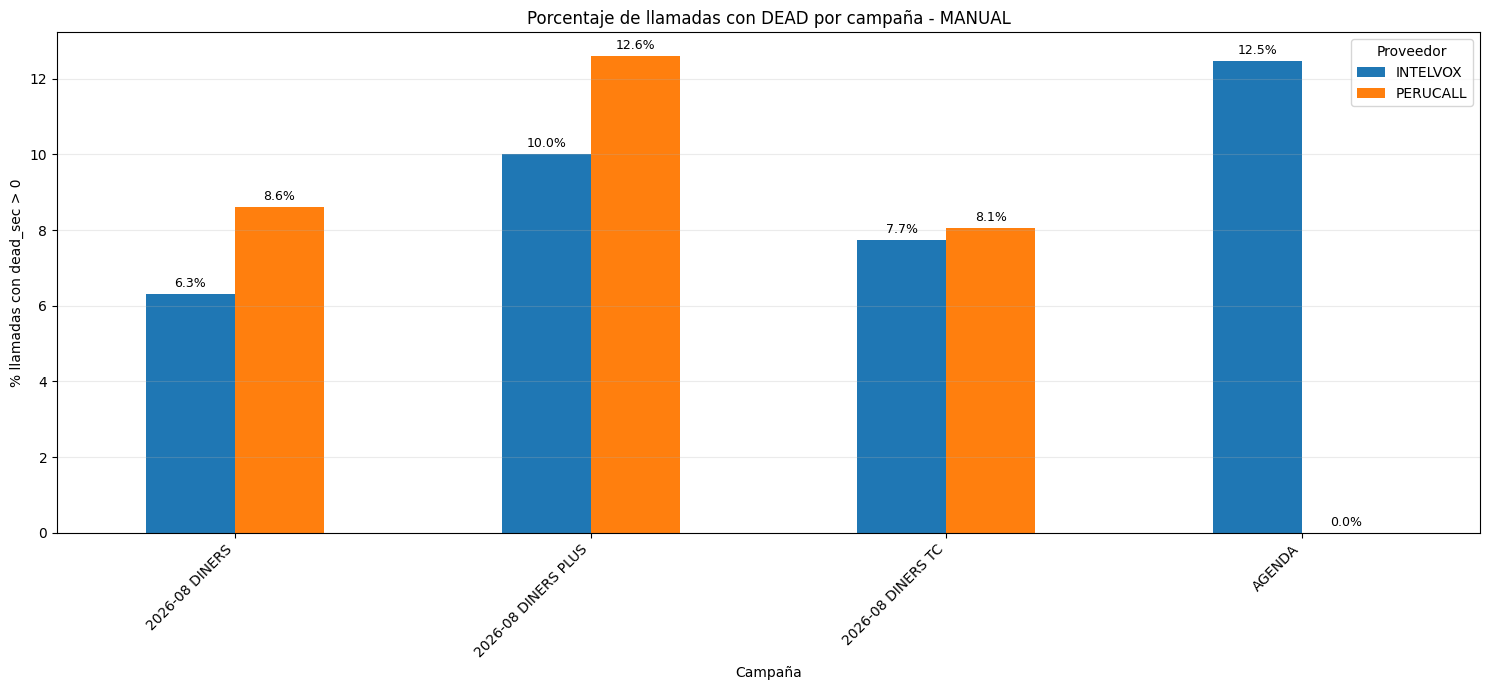

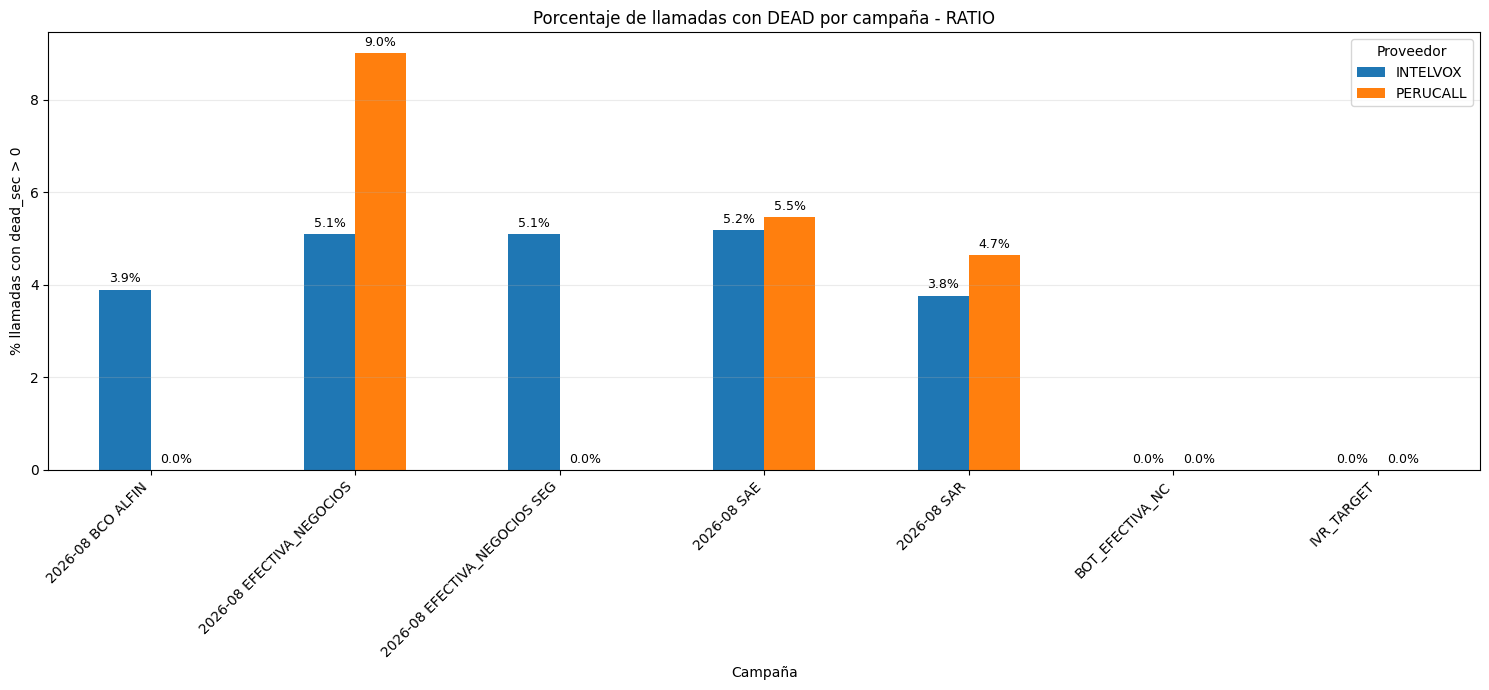

In [67]:
# ============================================================
# GRÁFICO % LLAMADAS CON DEAD
# ============================================================

for metodo in sorted(
    resumen_dead["dial_method"]
    .dropna()
    .unique()
):

    df_grafico = resumen_dead[
        resumen_dead["dial_method"] == metodo
    ].copy()

    pivot = (
        df_grafico
        .pivot(
            index="nombre_campana",
            columns="proveedor",
            values="porcentaje_con_dead"
        )
        .fillna(0)
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(15, 7)
    )

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=9
        )

    plt.title(
        f"Porcentaje de llamadas con DEAD por campaña - {metodo}"
    )

    plt.xlabel("Campaña")
    plt.ylabel("% llamadas con dead_sec > 0")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.legend(
        title="Proveedor"
    )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

## Embudo

In [68]:
# ============================================================
# EMBUDO DE EFICIENCIA POR PROVEEDOR
# ============================================================

resumen_embudo = (
    df_intentos
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )
    .agg(
        clientes_gestionados=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)

# ============================================================
# CLIENTES CONTACTADOS
# ============================================================

contactados = (
    primer_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )
    .agg(
        clientes_contactados=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)

# ============================================================
# CONTACTADOS EN MÁXIMO 2 INTENTOS
# ============================================================

contactados_2_intentos = (
    primer_contacto[
        primer_contacto["nro_intento"] <= 2
    ]
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )
    .agg(
        contacto_hasta_2_intentos=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)

# ============================================================
# CONTACTADOS EN PRIMER INTENTO
# ============================================================

contactados_1_intento = (
    primer_contacto[
        primer_contacto["nro_intento"] == 1
    ]
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )
    .agg(
        contacto_1_intento=(
            "vendor_lead_code",
            "nunique"
        )
    )
    .reset_index()
)

# ============================================================
# UNIR
# ============================================================

embudo = (
    resumen_embudo
    .merge(
        contactados,
        on=[
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        how="left"
    )
    .merge(
        contactados_2_intentos,
        on=[
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        how="left"
    )
    .merge(
        contactados_1_intento,
        on=[
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        how="left"
    )
)

# Nulos a cero
columnas_embudo = [
    "clientes_contactados",
    "contacto_hasta_2_intentos",
    "contacto_1_intento"
]

embudo[columnas_embudo] = (
    embudo[columnas_embudo]
    .fillna(0)
    .astype(int)
)

In [69]:
embudo["pct_contactados"] = (
    embudo["clientes_contactados"]
    / embudo["clientes_gestionados"]
    * 100
)

embudo["pct_hasta_2_intentos"] = (
    embudo["contacto_hasta_2_intentos"]
    / embudo["clientes_gestionados"]
    * 100
)

embudo["pct_1_intento"] = (
    embudo["contacto_1_intento"]
    / embudo["clientes_gestionados"]
    * 100
)

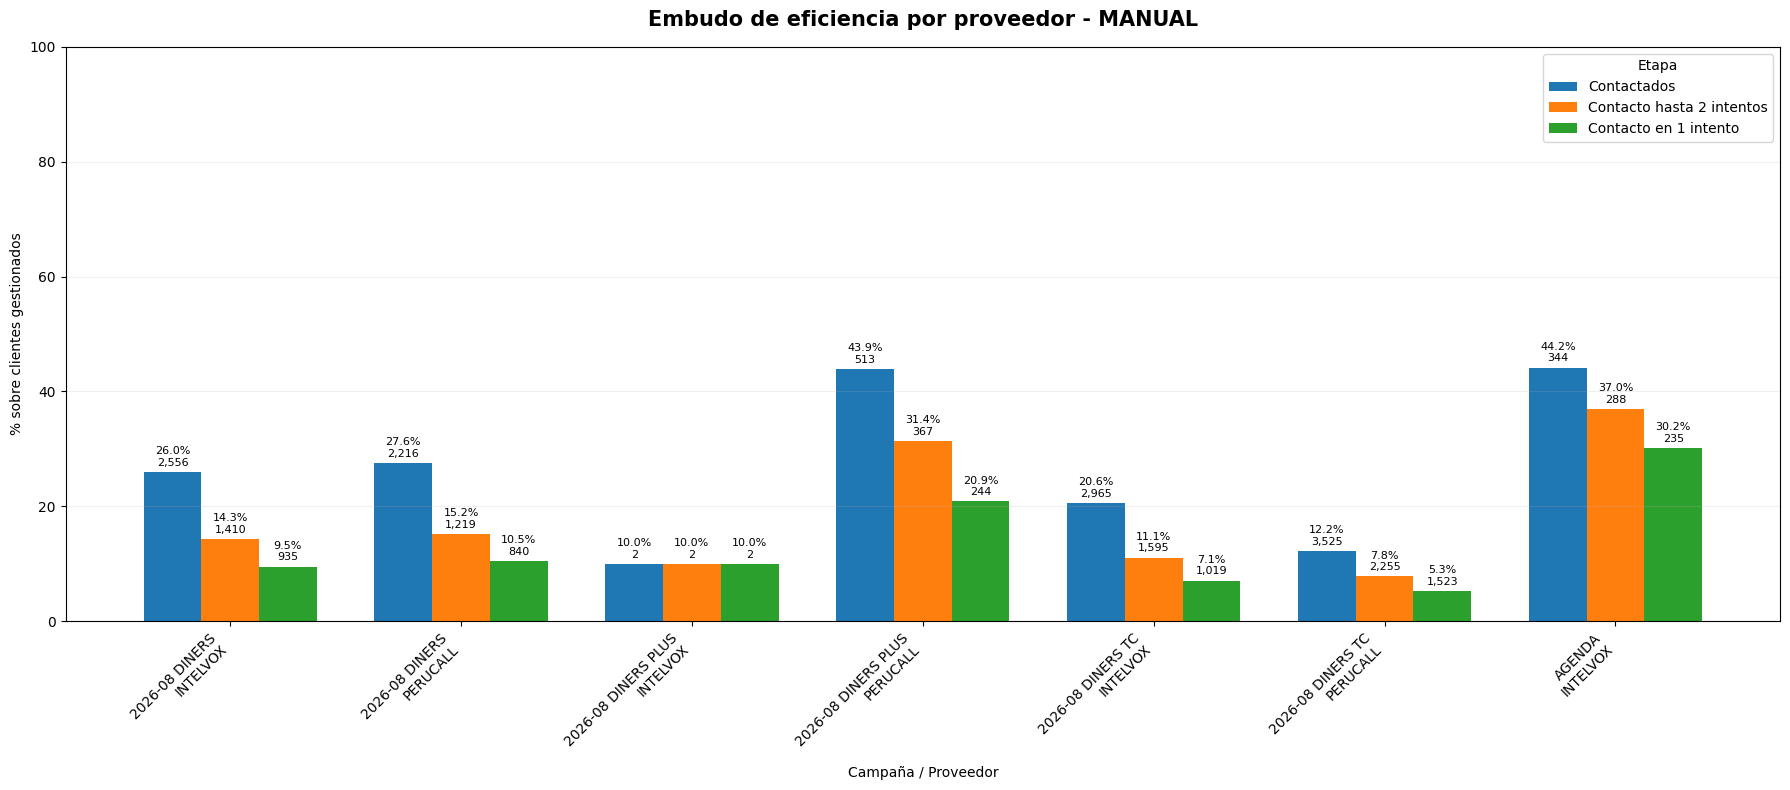

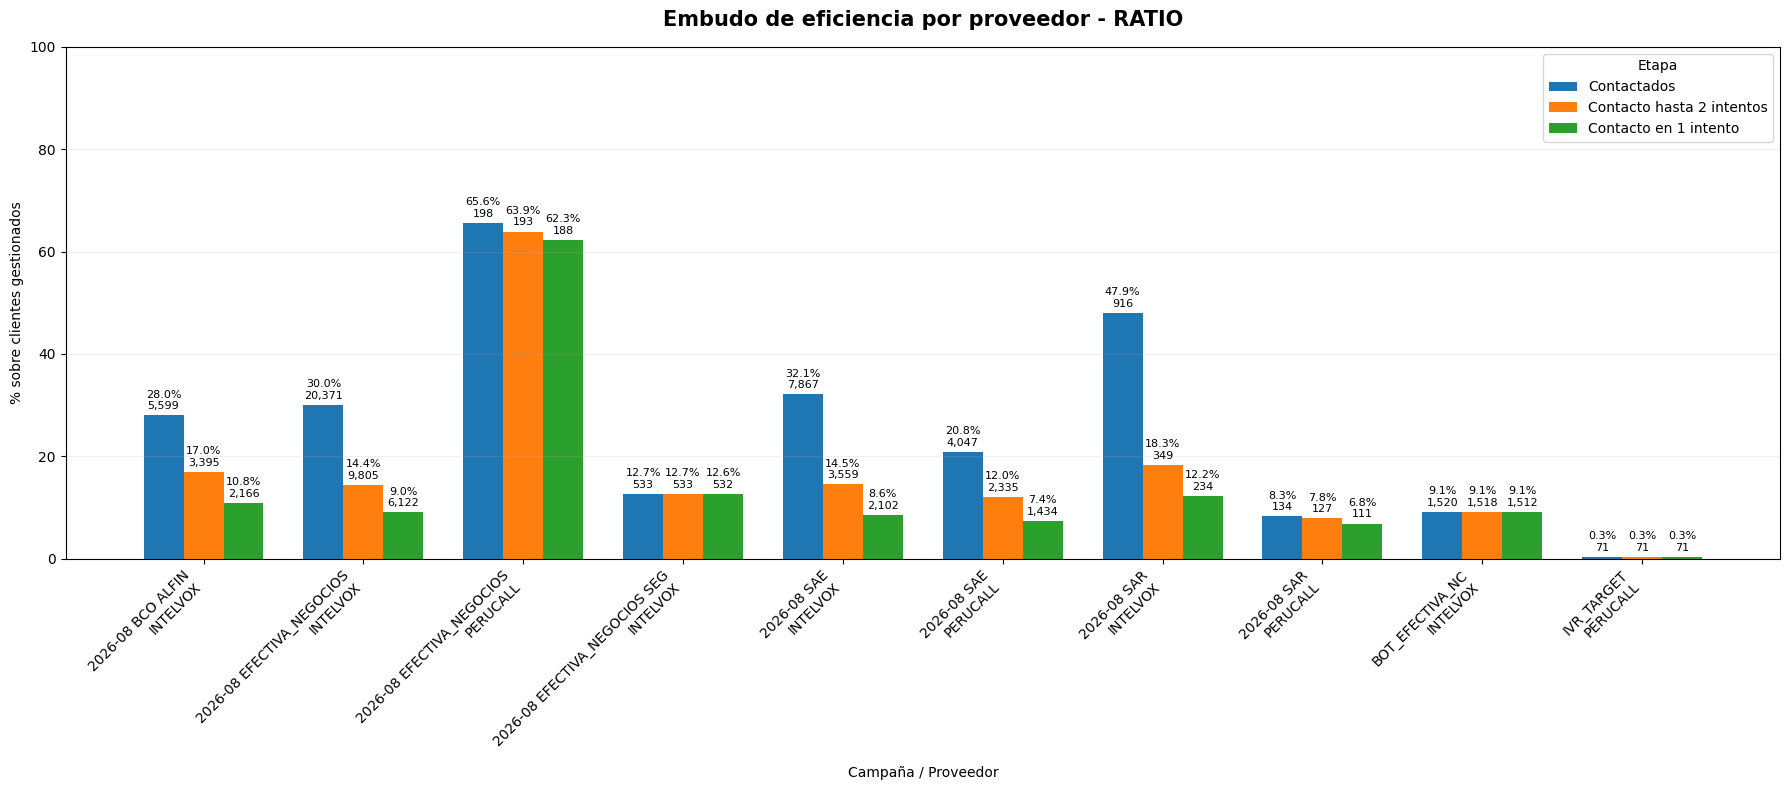

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ORDEN
# ============================================================

orden_dial = [
    "MANUAL",
    "RATIO"
]

proveedores_orden = [
    "INTELVOX",
    "PERUCALL"
]

# ============================================================
# GRÁFICO POR DIAL_METHOD
# ============================================================

for metodo in orden_dial:

    # --------------------------------------------------------
    # FILTRAR MÉTODO
    # --------------------------------------------------------

    df_plot = embudo[
        embudo["dial_method"] == metodo
    ].copy()

    if df_plot.empty:
        continue

    # --------------------------------------------------------
    # ORDENAR
    # --------------------------------------------------------

    df_plot["proveedor"] = pd.Categorical(
        df_plot["proveedor"],
        categories=proveedores_orden,
        ordered=True
    )

    df_plot = df_plot.sort_values(
        [
            "nombre_campana",
            "proveedor"
        ]
    )

    # --------------------------------------------------------
    # ETIQUETA CAMPAÑA + PROVEEDOR
    # --------------------------------------------------------

    df_plot["grupo"] = (
        df_plot["nombre_campana"].astype(str)
        + "\n"
        + df_plot["proveedor"].astype(str)
    )

    # --------------------------------------------------------
    # POSICIONES
    # --------------------------------------------------------

    x = np.arange(
        len(df_plot)
    )

    width = 0.25

    # --------------------------------------------------------
    # GRÁFICO
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(18, 8)
    )

    b1 = ax.bar(
        x - width,
        df_plot["pct_contactados"],
        width,
        label="Contactados"
    )

    b2 = ax.bar(
        x,
        df_plot["pct_hasta_2_intentos"],
        width,
        label="Contacto hasta 2 intentos"
    )

    b3 = ax.bar(
        x + width,
        df_plot["pct_1_intento"],
        width,
        label="Contacto en 1 intento"
    )

    # ========================================================
    # ETIQUETAS: % + CANTIDAD
    # ========================================================

    etiquetas_contactados = [
        f"{pct:.1f}%\n{cant:,.0f}"
        for pct, cant in zip(
            df_plot["pct_contactados"],
            df_plot["clientes_contactados"]
        )
    ]

    etiquetas_2 = [
        f"{pct:.1f}%\n{cant:,.0f}"
        for pct, cant in zip(
            df_plot["pct_hasta_2_intentos"],
            df_plot["contacto_hasta_2_intentos"]
        )
    ]

    etiquetas_1 = [
        f"{pct:.1f}%\n{cant:,.0f}"
        for pct, cant in zip(
            df_plot["pct_1_intento"],
            df_plot["contacto_1_intento"]
        )
    ]

    ax.bar_label(
        b1,
        labels=etiquetas_contactados,
        padding=3,
        fontsize=8
    )

    ax.bar_label(
        b2,
        labels=etiquetas_2,
        padding=3,
        fontsize=8
    )

    ax.bar_label(
        b3,
        labels=etiquetas_1,
        padding=3,
        fontsize=8
    )

    # ========================================================
    # EJE X
    # ========================================================

    ax.set_xticks(x)

    ax.set_xticklabels(
        df_plot["grupo"],
        rotation=45,
        ha="right"
    )

    # ========================================================
    # FORMATO
    # ========================================================

    ax.set_title(
        f"Embudo de eficiencia por proveedor - {metodo}",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Campaña / Proveedor"
    )

    ax.set_ylabel(
        "% sobre clientes gestionados"
    )

    ax.set_ylim(
        0,
        max(
            100,
            df_plot["pct_contactados"].max() * 1.20
        )
    )

    ax.legend(
        title="Etapa"
    )

    ax.grid(
        axis="y",
        alpha=0.20
    )

    plt.tight_layout()
    plt.show()

In [73]:
df_total_agosto_02.groupby(
    [
        "nombre_campana",
        "proveedor",
        "dial_method"
    ],
    dropna=False
).size().reset_index(name="cantidad")

,nombre_campana,proveedor,dial_method,cantidad
0,2026-08 BCO ALFIN,INTELVOX,RATIO,64684
1,2026-08 DINERS,INTELVOX,MANUAL,51413
2,2026-08 DINERS,PERUCALL,MANUAL,38030
3,2026-08 DINERS PLUS,INTELVOX,MANUAL,20
4,2026-08 DINERS PLUS,PERUCALL,MANUAL,5065
5,2026-08 DINERS TC,INTELVOX,MANUAL,90240
6,2026-08 DINERS TC,PERUCALL,MANUAL,97609
7,2026-08 EFECTIVA_NEGOCIOS,INTELVOX,RATIO,428448
8,2026-08 EFECTIVA_NEGOCIOS,PERUCALL,RATIO,577
9,2026-08 EFECTIVA_NEGOCIOS SEG,INTELVOX,RATIO,4216


In [74]:
validacion_dial = (
    df_total_agosto_01
    .groupby(
        [
            "nombre_campana",
            "proveedor",
            "dial_method"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

display(
    validacion_dial[
        validacion_dial["nombre_campana"].isin([
            "2026-08 DINERS",
            "2026-08 DINERS TC"
        ])
    ]
)

,nombre_campana,proveedor,dial_method,cantidad
9,2026-08 DINERS,INTELVOX,MANUAL,51413
10,2026-08 DINERS,PERUCALL,MANUAL,38030
11,2026-08 DINERS,PROVEEDOR NO IDENTIFICADO,MANUAL,13
15,2026-08 DINERS TC,INTELVOX,MANUAL,90240
16,2026-08 DINERS TC,PERUCALL,MANUAL,97609
17,2026-08 DINERS TC,PROVEEDOR NO IDENTIFICADO,MANUAL,7


In [75]:
display(
    df_total_agosto_01.loc[
        df_total_agosto_01["nombre_campana"].isin([
            "2026-08 DINERS",
            "2026-08 DINERS TC"
        ]),
        [
            "nombre_campana",
            "proveedor",
            "server_ip",
            "dial_method"
        ]
    ]
    .value_counts(dropna=False)
    .reset_index(name="cantidad")
)

,nombre_campana,proveedor,server_ip,dial_method,cantidad
0,2026-08 DINERS TC,PERUCALL,192.168.3.21,MANUAL,97609
1,2026-08 DINERS TC,INTELVOX,192.168.3.21,MANUAL,90240
2,2026-08 DINERS,INTELVOX,192.168.3.21,MANUAL,51413
3,2026-08 DINERS,PERUCALL,192.168.3.21,MANUAL,38030
4,2026-08 DINERS,PROVEEDOR NO IDENTIFICADO,NaN,MANUAL,13
5,2026-08 DINERS TC,PROVEEDOR NO IDENTIFICADO,NaN,MANUAL,7


In [71]:
embudo.head(10)

,nombre_campana,dial_method,proveedor,clientes_gestionados,clientes_contactados,contacto_hasta_2_intentos,contacto_1_intento,pct_contactados,pct_hasta_2_intentos,pct_1_intento
0,2026-08 BCO ALFIN,RATIO,INTELVOX,20011,5599,3395,2166,27.979611,16.965669,10.824047
1,2026-08 DINERS,MANUAL,INTELVOX,9829,2556,1410,935,26.004680,14.345305,9.512667
2,2026-08 DINERS,MANUAL,PERUCALL,8027,2216,1219,840,27.606827,15.186246,10.464682
3,2026-08 DINERS PLUS,MANUAL,INTELVOX,20,2,2,2,10.000000,10.000000,10.000000
4,2026-08 DINERS PLUS,MANUAL,PERUCALL,1168,513,367,244,43.921233,31.421233,20.890411
5,2026-08 DINERS TC,MANUAL,INTELVOX,14400,2965,1595,1019,20.590278,11.076389,7.076389
6,2026-08 DINERS TC,MANUAL,PERUCALL,28883,3525,2255,1523,12.204411,7.807361,5.272998
7,2026-08 EFECTIVA_NEGOCIOS,RATIO,INTELVOX,67948,20371,9805,6122,29.980279,14.430152,9.009831
8,2026-08 EFECTIVA_NEGOCIOS,RATIO,PERUCALL,302,198,193,188,65.562914,63.907285,62.251656
9,2026-08 EFECTIVA_NEGOCIOS SEG,RATIO,INTELVOX,4207,533,533,532,12.669361,12.669361,12.645591


In [101]:
dead_promedio=("dead_sec", "mean")

In [102]:
# Solo llamadas donde realmente hubo dead
solo_dead = df_dead[
    df_dead["tiene_dead"]
].copy()

resumen_solo_dead = (
    solo_dead
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ],
        dropna=False
    )
    .agg(
        llamadas_con_dead=("lead_id", "size"),

        dead_promedio_cuando_ocurre=(
            "dead_sec",
            "mean"
        ),

        dead_mediana_cuando_ocurre=(
            "dead_sec",
            "median"
        ),

        dead_p90_cuando_ocurre=(
            "dead_sec",
            lambda x: x.quantile(0.90)
        )
    )
    .reset_index()
)

display(
    resumen_solo_dead.round(2)
)

,nombre_campana,dial_method,proveedor,llamadas_con_dead,dead_promedio_cuando_ocurre,dead_mediana_cuando_ocurre,dead_p90_cuando_ocurre
0,2026-08 BCO ALFIN,RATIO,INTELVOX,2334,15.88,6.0,41.0
1,2026-08 DINERS,MANUAL,INTELVOX,3248,14.62,5.0,38.0
2,2026-08 DINERS,MANUAL,PERUCALL,3069,19.29,6.0,44.0
3,2026-08 DINERS PLUS,MANUAL,INTELVOX,2,1.00,1.0,1.0
4,2026-08 DINERS PLUS,MANUAL,PERUCALL,580,17.15,4.0,43.0
5,2026-08 DINERS TC,MANUAL,INTELVOX,6260,8.64,4.0,27.0
6,2026-08 DINERS TC,MANUAL,PERUCALL,7861,8.75,4.0,30.0
7,2026-08 EFECTIVA_NEGOCIOS,RATIO,INTELVOX,20485,8.45,3.0,22.0
8,2026-08 EFECTIVA_NEGOCIOS,RATIO,PERUCALL,52,8.96,2.5,27.4
9,2026-08 SAE,RATIO,INTELVOX,10670,14.56,5.0,35.0
